In [1]:
# Standards
import os
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Statistics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import spearmanr, shapiro, stats
from tqdm.auto import tqdm

# Preprocessing
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

# Model Selection and Validation
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict, cross_validate,
    StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV
)

#Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier

#Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, auc, make_scorer,
    balanced_accuracy_score, average_precision_score
)

#Interpretability
from sklearn.inspection import permutation_importance
import shap

#Class imbalance management
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

#Disable warnings
warnings.filterwarnings("ignore")

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.close("all")
print("backend now =", matplotlib.get_backend())
import os
os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"

backend now = module://matplotlib_inline.backend_inline


In [3]:
# https://www.mikulskibartosz.name/how-to-set-the-global-random_state-in-scikit-learn/
# fix numpy random seed to assure reproducable results (also in sklearn)
#-----------------------------------------------------------------------------------------------------------
# IMPORTANT: When cells with randomness are executed in different orders this leads to different results.
#-----------------------------------------------------------------------------------------------------------
RANDOM_SEED = 235457

np.random.seed(RANDOM_SEED)

In [4]:
df_nps=pd.read_excel("DATASET FINALIZZATA_PIT_nps_08.09.xlsx")

In [5]:
df_nps.info()
df_nps.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           110 non-null    int64  
 1   group                        110 non-null    object 
 2   Gender                       110 non-null    object 
 3   Age                          110 non-null    int64  
 4   Education level              110 non-null    int64  
 5   MMSE                         110 non-null    float64
 6   TMT-A                        110 non-null    int64  
 7   TMT-B                        110 non-null    int64  
 8   TMT-B-A                      110 non-null    int64  
 9   FAB                          110 non-null    float64
 10  MFPT-UD                      110 non-null    float64
 11  MFPT-CS                      110 non-null    float64
 12  Fluency F.                   110 non-null    float64
 13  Fluency S           

id                             110
group                          110
Gender                         110
Age                            110
Education level                110
MMSE                           110
TMT-A                          110
TMT-B                          110
TMT-B-A                        110
FAB                            110
MFPT-UD                        110
MFPT-CS                        110
Fluency F.                     110
Fluency S                      110
Fluency A                      110
Fluency Shifting               110
SUS                            105
PIT (s)                        109
PIT (n. correct answers)       109
PIT (elements)                 109
STROOP_RT_D                    108
STROOP_RT_INT                  107
STROOP_Mean Congruent RT       108
STROOP_Mean Incongruent RT     108
STROOP-STIR                    108
TFI-11                         110
TFI_12                         110
TFI_13                         110
TFI_14              

In [6]:
df_nps.columns.tolist()

['id',
 'group',
 'Gender',
 'Age',
 'Education level',
 'MMSE',
 'TMT-A',
 'TMT-B',
 'TMT-B-A',
 'FAB',
 'MFPT-UD',
 'MFPT-CS',
 'Fluency F.',
 'Fluency S',
 'Fluency A',
 'Fluency Shifting',
 'SUS',
 'PIT (s)',
 'PIT (n. correct answers)',
 'PIT (elements)',
 'STROOP_RT_D',
 'STROOP_RT_INT',
 'STROOP_Mean Congruent RT',
 'STROOP_Mean Incongruent RT',
 'STROOP-STIR',
 'TFI-11',
 'TFI_12',
 'TFI_13',
 'TFI_14',
 'TFI_15',
 'TFI_16',
 'TFI_17',
 'TFI_18',
 'TFI_19',
 'TFI_20',
 'TFI_21',
 'TFI_22',
 'TFI_23',
 'TFI_24',
 'TFI_25',
 'TFI- variabili fisiche ',
 'TFI- variabili psicologiche',
 'TFI- sociali',
 'GDS',
 'ADL',
 'IADL']

# EDA \(pt 1\)

In [7]:
n_pz = df_nps.shape[0]
print("The total number of patients in the DataFrame df is:", n_pz)

The total number of patients in the DataFrame df is: 110


In [8]:
range_columns = {}
for column in df_nps.columns:
    if pd.api.types.is_numeric_dtype(df_nps[column]):
        column_min = df_nps[column].min()
        column_max = df_nps[column].max()
        range_columns[column] = (column_min, column_max)

for column, (min_val, max_val) in range_columns.items():
    print(f'Variable: {column}, Range: ({min_val}, {max_val})')

Variable: id, Range: (1, 110)
Variable: Age, Range: (65, 88)
Variable: Education level, Range: (5, 22)
Variable: MMSE, Range: (22.7, 30.0)
Variable: TMT-A, Range: (-9, 98)
Variable: TMT-B, Range: (-77, 371)
Variable: TMT-B-A, Range: (-129, 360)
Variable: FAB, Range: (8.2, 18.0)
Variable: MFPT-UD, Range: (0.0, 47.25)
Variable: MFPT-CS, Range: (0.0, 6.25)
Variable: Fluency F., Range: (4.73, 62.71)
Variable: Fluency S, Range: (21.92, 78.53)
Variable: Fluency A, Range: (6.08, 65.76)
Variable: Fluency Shifting, Range: (0.16618854486101495, 1.3297232250300843)
Variable: SUS, Range: (20.0, 100.0)
Variable: PIT (s), Range: (1.0, 180.0)
Variable: PIT (n. correct answers), Range: (0.0, 1.0)
Variable: PIT (elements), Range: (0.0, 13.0)
Variable: STROOP_RT_D, Range: (0.0, 1.51)
Variable: STROOP_RT_INT, Range: (0.95, 2.24)
Variable: STROOP_Mean Congruent RT, Range: (0.83151614, 2.399506067)
Variable: STROOP_Mean Incongruent RT, Range: (0.9476227214285714, 2.14080914)
Variable: STROOP-STIR, Range: (

In [9]:
Nan = df_nps.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)

SUS                           5
PIT (s)                       1
PIT (n. correct answers)      1
PIT (elements)                1
STROOP_RT_D                   2
STROOP_RT_INT                 3
STROOP_Mean Congruent RT      2
STROOP_Mean Incongruent RT    2
STROOP-STIR                   2
dtype: int64


In [10]:
dups = df_nps.duplicated()
print(f'Are there duplicates? = {dups.any()}')

Are there duplicates? = False


In [11]:
#Descriptive analysis (before imputation)
with pd.option_context('display.max_rows', None):
    display(df_nps.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
id,110.0,55.500000,31.898276,1.000000,28.250000,55.500000,82.750000,110.000000
Age,110.0,73.445455,6.299245,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,110.0,12.754545,4.023295,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,110.0,27.907091,1.999291,22.700000,26.300000,27.850000,30.000000,30.000000
TMT-A,110.0,33.381818,20.177643,-9.000000,21.250000,33.000000,42.750000,98.000000
TMT-B,110.0,61.263636,63.628895,-77.000000,21.500000,56.000000,91.000000,371.000000
TMT-B-A,110.0,27.581818,57.117838,-129.000000,-2.750000,20.000000,48.250000,360.000000
FAB,110.0,15.759091,2.187005,8.200000,14.200000,16.200000,18.000000,18.000000
MFPT-UD,110.0,23.293182,9.340701,0.000000,16.312500,23.000000,30.750000,47.250000
MFPT-CS,110.0,0.261364,0.785758,0.000000,0.000000,0.000000,0.000000,6.250000


In [12]:
df_n = df_nps.loc[df_nps['id'] != 48].copy()
print("Excluded ID 48 because PIT data are unavailable.")
print("Analysis sample size:", len(df_n))

Excluded ID 48 because PIT data are unavailable.
Analysis sample size: 109


In [13]:
df_n['group'].value_counts()

group
MCI        57
HC         32
Frailty    20
Name: count, dtype: int64

In [14]:
df_n.dtypes.to_list()

[dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64')]

# Pre\-processing

In [15]:
# PREPROCESSING DEFINITION
numeric_features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A',
                    'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)

In [16]:
Nan = df_n.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)

SUS                           4
STROOP_RT_D                   2
STROOP_RT_INT                 3
STROOP_Mean Congruent RT      2
STROOP_Mean Incongruent RT    2
STROOP-STIR                   2
dtype: int64


# EDA \(pt 2\)

In [17]:
# Descriptive analysis of raw data (missing values retained)
with pd.option_context('display.max_rows', None):
    display(df_n.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
id,109.0,55.568807,32.037411,1.000000,28.000000,56.000000,83.000000,110.000000
Age,109.0,73.385321,6.296543,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,109.0,12.798165,4.015663,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,109.0,27.918165,2.005133,22.700000,26.300000,28.000000,30.000000,30.000000
TMT-A,109.0,33.366972,20.270239,-9.000000,21.000000,33.000000,43.000000,98.000000
TMT-B,109.0,61.899083,63.571183,-77.000000,23.000000,56.000000,91.000000,371.000000
TMT-B-A,109.0,28.238532,56.962935,-129.000000,-2.000000,20.000000,50.000000,360.000000
FAB,109.0,15.791743,2.170003,8.200000,14.200000,16.200000,18.000000,18.000000
MFPT-UD,109.0,23.392202,9.325664,0.000000,16.500000,23.000000,30.750000,47.250000
MFPT-CS,109.0,0.252294,0.783581,0.000000,0.000000,0.000000,0.000000,6.250000


In [18]:
from scipy import stats
import numpy as np
import pandas as pd

# 1. Select variables
variables_to_compare = ['MMSE','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                        'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting',
                        'STROOP-STIR', 'STROOP_RT_D', 'STROOP_RT_INT',
                        'STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT',
                        'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

results = []

# 2. Descriptive statistics and CI helper
def describe_group(data):
    n = len(data)
    mean = data.mean()
    std = data.std()
    ci = 1.96 * std / np.sqrt(n) if n > 1 else np.nan
    ci_str = f"[{round(mean - ci, 2)}, {round(mean + ci, 2)}]" if not np.isnan(ci) else "N/A"
    return round(mean, 2), round(std, 2), ci_str

# 3. Iterate over variables
for var_name in variables_to_compare:
    # Extract data by group
    mci_data = df_n.loc[df_n['group'] == 'MCI', var_name].dropna()
    frailty_data = df_n.loc[df_n['group'] == 'Frailty', var_name].dropna()
    hc_data = df_n.loc[df_n['group'] == 'HC', var_name].dropna()

    # Descriptive statistics with CI
    mci_mean, mci_std, mci_ci = describe_group(mci_data)
    frailty_mean, frailty_std, frailty_ci = describe_group(frailty_data)
    hc_mean, hc_std, hc_ci = describe_group(hc_data)

    # Between-group t-tests
    _, p_value_mci_hc = stats.ttest_ind(mci_data, hc_data, nan_policy='omit')
    _, p_value_frailty_hc = stats.ttest_ind(frailty_data, hc_data, nan_policy='omit')
    _, p_value_frailty_mci = stats.ttest_ind(frailty_data, mci_data, nan_policy='omit')

    # Store results
    results.append([
        var_name,
        mci_mean, mci_std, mci_ci,
        frailty_mean, frailty_std, frailty_ci,
        hc_mean, hc_std, hc_ci,
        round(p_value_mci_hc, 5),
        round(p_value_frailty_hc, 5),
        round(p_value_frailty_mci, 5)
    ])

# 4. Build the final DataFrame
results_descriptive = pd.DataFrame(results, columns=[
    'Variable',
    'MCI Mean', 'MCI Std', 'MCI 95% CI',
    'Frailty Mean', 'Frailty Std', 'Frailty 95% CI',
    'HC Mean', 'HC Std', 'HC 95% CI',
    'p-value (MCI vs HC)',
    'p-value (Frailty vs HC)',
    'p-value (Frailty vs MCI)'
])

# 5. Display results
results_descriptive


,Variable,MCI Mean,MCI Std,MCI 95% CI,Frailty Mean,Frailty Std,Frailty 95% CI,HC Mean,HC Std,HC 95% CI,p-value (MCI vs HC),p-value (Frailty vs HC),p-value (Frailty vs MCI)
0,MMSE,27.57,1.98,"[27.06, 28.08]",28.72,1.87,"[27.91, 29.54]",28.03,2.03,"[27.33, 28.74]",0.29673,0.22376,0.02580
1,TMT-B,77.35,75.62,"[57.72, 96.98]",43.10,44.71,"[23.5, 62.7]",46.12,40.01,"[32.26, 59.99]",0.03288,0.80090,0.06035
2,TMT-B-A,39.42,71.25,"[20.92, 57.92]",18.60,33.68,"[3.84, 33.36]",14.34,30.82,"[3.66, 25.02]",0.06202,0.64214,0.21352
3,FAB,14.69,2.32,"[14.09, 15.3]",16.99,1.06,"[16.53, 17.46]",16.99,1.16,"[16.59, 17.4]",0.00000,0.99690,0.00006
4,MFPT-UD,18.98,8.69,"[16.72, 21.23]",26.16,7.94,"[22.68, 29.64]",29.52,6.96,"[27.11, 31.93]",0.00000,0.11483,0.00173
5,MFPT-CS,0.10,0.31,"[0.02, 0.18]",0.76,1.58,"[0.07, 1.45]",0.20,0.49,"[0.03, 0.37]",0.22600,0.06596,0.00321
6,Fluency F.,30.66,10.33,"[27.97, 33.34]",42.81,7.89,"[39.35, 46.27]",42.93,9.23,"[39.73, 46.13]",0.00000,0.96282,0.00001
7,Fluency S,43.53,8.24,"[41.39, 45.67]",51.58,8.56,"[47.83, 55.34]",53.08,9.40,"[49.82, 56.34]",0.00000,0.56595,0.00038
8,Fluency A,23.85,10.11,"[21.22, 26.47]",36.35,9.21,"[32.31, 40.39]",40.73,11.83,"[36.63, 44.83]",0.00000,0.16524,0.00001
9,Fluency Shifting,0.64,0.22,"[0.58, 0.69]",0.77,0.18,"[0.69, 0.85]",0.86,0.23,"[0.78, 0.94]",0.00002,0.16776,0.01573


In [19]:
#Describe comparative analysis: neuropsychological tests and behavioral tasks for groups
variables_to_compare = df_n[['MMSE','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT','PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

results = []

for variable in variables_to_compare:
    mci_data = df_n.loc[df_n['group'] == 'MCI', variable].dropna()
    frailty_data = df_n.loc[df_n['group'] == 'Frailty', variable].dropna()
    hc_data = df_n.loc[df_n['group'] == 'HC', variable].dropna()

    mci_mean, mci_std = mci_data.mean(), mci_data.std()
    frailty_mean, frailty_std = frailty_data.mean(), frailty_data.std()
    hc_mean, hc_std = hc_data.mean(), hc_data.std()

    t_stat_mci_hc, p_value_mci_hc = stats.ttest_ind(mci_data, hc_data, nan_policy='omit')
    t_stat_frailty_hc, p_value_frailty_hc = stats.ttest_ind(frailty_data, hc_data, nan_policy='omit')
    t_stat_frailty_mci, p_value_frailty_mci = stats.ttest_ind(frailty_data, mci_data, nan_policy='omit')


    results.append([variable,
                    round(mci_mean, 2), round(mci_std, 2),
                    round(frailty_mean, 2), round(frailty_std, 2),
                    round(hc_mean, 2), round(hc_std, 2),
                    round(p_value_mci_hc, 5), round(p_value_frailty_hc, 5), round(p_value_frailty_mci, 5)])


results_descriptive = pd.DataFrame(results, columns=['Variable',
                                            'MCI Mean', 'MCI Std',
                                            'Frailty Mean', 'Frailty Std',
                                            'HC Mean', 'HC Std',
                                            'p-value (MCI vs HC)',
                                            'p-value (Frailty vs HC)',
                                            'p-value (Frailty vs MCI)'])

results_descriptive

,Variable,MCI Mean,MCI Std,Frailty Mean,Frailty Std,HC Mean,HC Std,p-value (MCI vs HC),p-value (Frailty vs HC),p-value (Frailty vs MCI)
0,MMSE,27.57,1.98,28.72,1.87,28.03,2.03,0.29673,0.22376,0.02580
1,TMT-B,77.35,75.62,43.10,44.71,46.12,40.01,0.03288,0.80090,0.06035
2,TMT-B-A,39.42,71.25,18.60,33.68,14.34,30.82,0.06202,0.64214,0.21352
3,FAB,14.69,2.32,16.99,1.06,16.99,1.16,0.00000,0.99690,0.00006
4,MFPT-UD,18.98,8.69,26.16,7.94,29.52,6.96,0.00000,0.11483,0.00173
5,MFPT-CS,0.10,0.31,0.76,1.58,0.20,0.49,0.22600,0.06596,0.00321
6,Fluency F.,30.66,10.33,42.81,7.89,42.93,9.23,0.00000,0.96282,0.00001
7,Fluency S,43.53,8.24,51.58,8.56,53.08,9.40,0.00000,0.56595,0.00038
8,Fluency A,23.85,10.11,36.35,9.21,40.73,11.83,0.00000,0.16524,0.00001
9,Fluency Shifting,0.64,0.22,0.77,0.18,0.86,0.23,0.00002,0.16776,0.01573


In [20]:
#Descriptive analysis by group: Demografic - Age and education level
age_education_stats = df_n.groupby('group').agg({'Age': ['mean', 'std'], 'Education level': ['mean', 'std']}).round(2)
age_education_stats

def mean_std_ci(series):
    n = series.count()
    mean = series.mean()
    std = series.std()
    ci95 = 1.96 * std / np.sqrt(n) if n > 1 else np.nan
    return pd.Series({
        'mean': round(mean, 2),
        'std': round(std, 2),
        'ci95': f"[{round(mean - ci95, 2)}, {round(mean + ci95, 2)}]" if not np.isnan(ci95) else "N/A"
    })

age_ci = df_n.groupby('group')['Age'].apply(mean_std_ci)
edu_ci = df_n.groupby('group')['Education level'].apply(mean_std_ci)

age_education_stats_with_ci = pd.concat([age_ci, edu_ci], axis=1, keys=['Age', 'Education level'])

age_education_stats_with_ci

Age Education level
group                                       
Frailty mean            73.4           13.25
        std             6.69            3.65
        ci95  [70.47, 76.33]  [11.65, 14.85]
HC      mean           71.28           13.91
        std             5.53            3.25
        ci95   [69.37, 73.2]  [12.78, 15.03]
MCI     mean           74.56           12.02
        std             6.36             4.4
        ci95  [72.91, 76.21]  [10.88, 13.16]

In [21]:
#Descriptive analysis by group: Demografic - Gender
gender_percentage = df_n.groupby(['group', 'Gender'])['Gender'].count().unstack().apply(lambda x: (x / x.sum()) * 100, axis=1).round(2)
gender_percentage

Gender,F,M
group,,
Frailty,75.00,25.00
HC,62.50,37.50
MCI,63.16,36.84


In [22]:
# DEFINE FEATURES + FIXED TRAIN/TEST SPLIT

features_full = [
    'TMT-B',
    'TMT-B-A',
    'FAB',
    'MFPT-UD',
    'MFPT-CS',
    'Fluency S',
    'Fluency A',
    'Fluency Shifting',
    'STROOP-STIR',
    'PIT (s)',
    'PIT (n. correct answers)',
    'PIT (elements)'
]

X_full = (
    df_n[features_full]
    .apply(pd.to_numeric, errors='coerce')
)

y_full = (
    df_n['group']
    .apply(lambda g: 1 if g == 'MCI' else 0)
)

X_full_train, X_full_test, y_full_train, y_full_test = (
    train_test_split(
        X_full,
        y_full,
        test_size=0.30,
        stratify=y_full,
        random_state=42
    )
)

print("Training set:", X_full_train.shape)
print("Test set:", X_full_test.shape)

Training set: (76, 12)
Test set: (33, 12)


Multicollinearity

In [23]:
# VIF — TRAINING DATA ONLY
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_train = X_full_train[features_full].copy()

vif_imputer = KNNImputer(n_neighbors=5)

X_vif_imputed = vif_imputer.fit_transform(
    X_vif_train
)

vif_scaler = StandardScaler()

X_vif_scaled = vif_scaler.fit_transform(
    X_vif_imputed
)


X_vif_df = pd.DataFrame(
    X_vif_scaled,
    columns=features_full,
    index=X_vif_train.index
)

X_vif_const = sm.add_constant(
    X_vif_df
)


vif_results = pd.DataFrame({
    "Feature": features_full,
    "VIF": [
        variance_inflation_factor(
            X_vif_const.values,
            i
        )
        for i in range(
            1,
            X_vif_const.shape[1]
        )
    ]
})


vif_results = (
    vif_results
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


display(vif_results)


print("\nFeatures with VIF > 10:")
display(
    vif_results[
        vif_results["VIF"] > 10
    ]
)

,Feature,VIF
0,Fluency A,16.097161
1,TMT-B,11.072934
2,Fluency Shifting,10.909036
3,TMT-B-A,10.026639
4,Fluency S,4.234902
5,PIT (s),4.005233
6,PIT (n. correct answers),2.326467
7,PIT (elements),2.061208
8,MFPT-UD,2.009597
9,FAB,1.542882



Features with VIF > 10:


,Feature,VIF
0,Fluency A,16.097161
1,TMT-B,11.072934
2,Fluency Shifting,10.909036
3,TMT-B-A,10.026639


Full model vs pruned model\. Check how it changes by removing multicollinear features in order to decide the best model to use\.

In [24]:
# FULL VS PRUNED FEATURE SET
# Cross-validation on TRAINING DATA ONLY

# 1. DEFINE PRUNED FEATURE SET

features_pruned = [
    f for f in features_full
    if f not in [
        'TMT-B-A',
        'Fluency A'
    ]
]


print("FULL FEATURES:")
print(features_full)

print("\nPRUNED FEATURES:")
print(features_pruned)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


def make_lasso_pipeline(features):

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    (
                        "imputer",
                        KNNImputer(
                            n_neighbors=5
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]),
                features
            )
        ],
        remainder="drop"
    )

    classifier = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        C=1.0,
        max_iter=5000,
        random_state=42
    )

    pipeline = Pipeline([
        (
            "preprocessing",
            preprocessor
        ),
        (
            "classifier",
            classifier
        )
    ])

    return pipeline

# 4. FULL MODEL — TRAINING CV ONLY


full_pipeline = make_lasso_pipeline(
    features_full
)

full_cv = cross_validate(
    full_pipeline,
    X_full_train[features_full],
    y_full_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# 5. PRUNED MODEL — SAME TRAINING SUBJECTS / SAME CV FOLDS

pruned_pipeline = make_lasso_pipeline(
    features_pruned
)

pruned_cv = cross_validate(
    pruned_pipeline,
    X_full_train[features_pruned],
    y_full_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# 6. SUMMARIZE RESULTS

results_full_pruned = pd.DataFrame({

    "Model": [
        "Full",
        "Pruned"
    ],

    "Accuracy_mean": [
        full_cv["test_accuracy"].mean(),
        pruned_cv["test_accuracy"].mean()
    ],

    "Accuracy_SD": [
        full_cv["test_accuracy"].std(),
        pruned_cv["test_accuracy"].std()
    ],

    "F1_mean": [
        full_cv["test_f1"].mean(),
        pruned_cv["test_f1"].mean()
    ],

    "F1_SD": [
        full_cv["test_f1"].std(),
        pruned_cv["test_f1"].std()
    ],

    "ROC_AUC_mean": [
        full_cv["test_roc_auc"].mean(),
        pruned_cv["test_roc_auc"].mean()
    ],

    "ROC_AUC_SD": [
        full_cv["test_roc_auc"].std(),
        pruned_cv["test_roc_auc"].std()
    ]
})


print("\n==========================================")
print("FULL VS PRUNED — TRAINING CV ONLY")
print("==========================================\n")

display(
    results_full_pruned.round(3)
)

# 7. SIMPLE DELTAS
# Positive delta = Pruned better than Full

delta_accuracy = (
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Pruned",
        "Accuracy_mean"
    ].iloc[0]
    -
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Full",
        "Accuracy_mean"
    ].iloc[0]
)

delta_f1 = (
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Pruned",
        "F1_mean"
    ].iloc[0]
    -
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Full",
        "F1_mean"
    ].iloc[0]
)

delta_auc = (
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Pruned",
        "ROC_AUC_mean"
    ].iloc[0]
    -
    results_full_pruned.loc[
        results_full_pruned["Model"] == "Full",
        "ROC_AUC_mean"
    ].iloc[0]
)


print("\nΔ Pruned − Full")

print(
    f"Accuracy: {delta_accuracy:+.3f}"
)

print(
    f"F1:       {delta_f1:+.3f}"
)

print(
    f"ROC-AUC:  {delta_auc:+.3f}"
)

FULL FEATURES:
['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

PRUNED FEATURES:
['TMT-B', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency S', 'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

FULL VS PRUNED — TRAINING CV ONLY



,Model,Accuracy_mean,Accuracy_SD,F1_mean,F1_SD,ROC_AUC_mean,ROC_AUC_SD
0,Full,0.803,0.070,0.80,0.079,0.925,0.053
1,Pruned,0.778,0.062,0.78,0.069,0.914,0.052



Δ Pruned − Full
Accuracy: -0.026
F1:       -0.019
ROC-AUC:  -0.011


Normal distribution

In [25]:
#Shapiro-Wilk test to check the normality of the features
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

normality_results = {}

for feature in features:
    stat, p_value = shapiro(df_n[feature].dropna())
    normality_results[feature] = {'Statistic': stat, 'p-value': p_value,
                                  'Normality (p>0.05)': p_value > 0.05}

normality_df = pd.DataFrame(normality_results).T
normality_df

,Statistic,p-value,Normality (p>0.05)
TMT-B,0.927897,0.000018,False
TMT-B-A,0.865069,0.0,False
FAB,0.883354,0.0,False
MFPT-UD,0.988709,0.498232,True
MFPT-CS,0.361287,0.0,False
Fluency S,0.984713,0.24835,True
Fluency A,0.976349,0.049232,False
Fluency Shifting,0.994442,0.942421,True
STROOP-STIR,0.682994,0.0,False
PIT (s),0.870328,0.0,False


Correlations

In [26]:
#Check correlations between variables to understand whether to use correlational feature selection or probabilistic models
#Spearman Correlation Matrix

features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

correlation_matrix = df_n[features].corr(method='spearman').round(2)

fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.index,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=correlation_matrix.values,
    texttemplate="%{text}",
    hovertemplate='Spearman correlation %{y} vs %{x}: %{z}<extra></extra>',
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title="Spearman Correlation Matrix",
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

In [27]:
#Correlation matrix between PIT and executive functions
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05

for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix = np.zeros((len(EF_features), len(pit_features)))
    pval_matrix = np.zeros((len(EF_features), len(pit_features)))

    for j, feat1 in enumerate(EF_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix[j, k] = np.nan
                pval_matrix[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix[j, k] = corr
                pval_matrix[j, k] = pval

    corr_matrix = pd.DataFrame(corr_matrix, index=EF_features, columns=pit_features).round(2)
    pval_matrix = pd.DataFrame(pval_matrix, index=EF_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix = corr_matrix.loc[significant_rows]
        filtered_pval_matrix = pval_matrix.loc[significant_rows]

        mask_values = (filtered_pval_matrix < p_value_threshold)
        masked_corr_matrix = filtered_corr_matrix.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]


        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix.values,
            x=masked_corr_matrix.columns,
            y=masked_corr_matrix.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and EF measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and EF measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="EF Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()


In [28]:
#Correlation matrix between PIT and neuropsychological measures

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

exclude_features = ['id', 'Age', 'Education level']
all_features = [col for col in df_n.select_dtypes(include=['number']).columns 
                if col not in pit_features and col not in exclude_features]

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05


for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix_all = np.zeros((len(all_features), len(pit_features)))
    pval_matrix_all = np.zeros((len(all_features), len(pit_features)))

    for j, feat1 in enumerate(all_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix_all[j, k] = np.nan
                pval_matrix_all[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix_all[j, k] = corr
                pval_matrix_all[j, k] = pval

    corr_matrix_all = pd.DataFrame(corr_matrix_all, index=all_features, columns=pit_features).round(2)
    pval_matrix_all = pd.DataFrame(pval_matrix_all, index=all_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix_all < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix_all = corr_matrix_all.loc[significant_rows]
        filtered_pval_matrix_all = pval_matrix_all.loc[significant_rows]

        mask_values = (filtered_pval_matrix_all < p_value_threshold)
        masked_corr_matrix_all = filtered_corr_matrix_all.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix_all.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix_all.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]

        
        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix_all.values,
            x=masked_corr_matrix_all.columns,
            y=masked_corr_matrix_all.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="Neuropsychological Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()

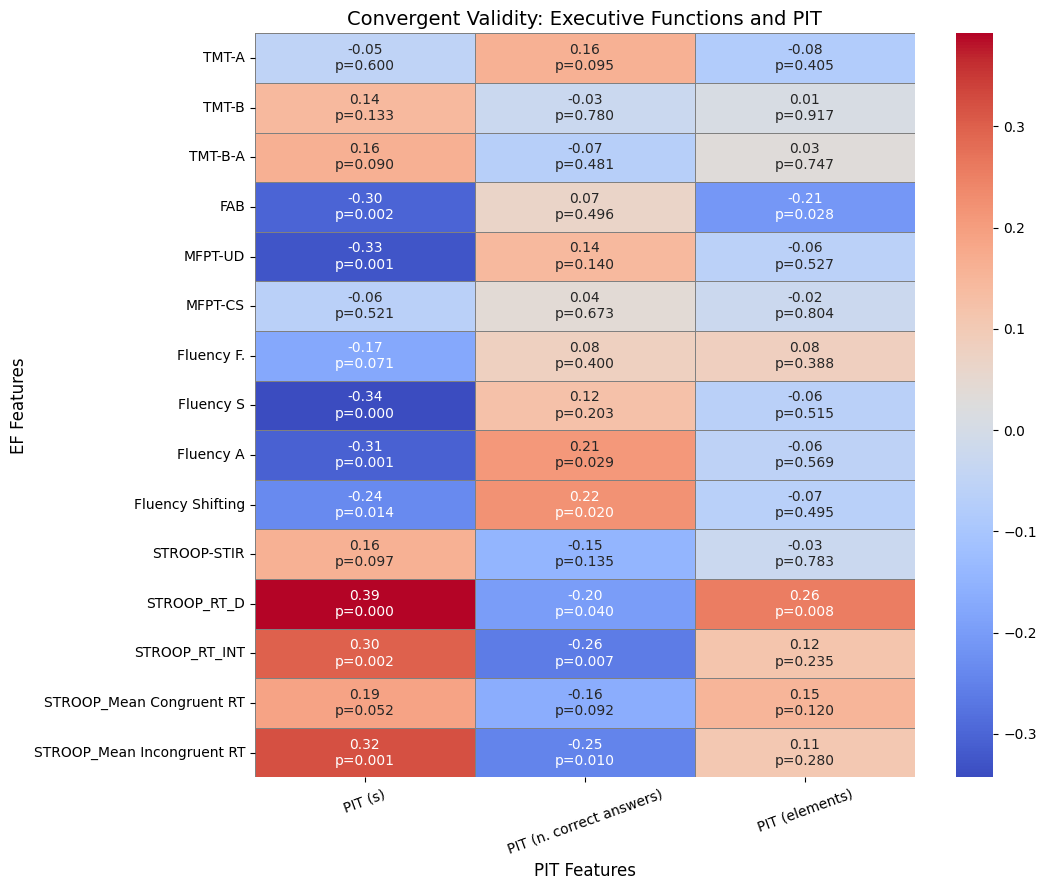

In [29]:
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']  

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

spearman_results = []
for ef in EF_features:
    for pit in pit_features:
        corr, pval = spearmanr(df_n[ef], df_n[pit])
        spearman_results.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

spearman_df = pd.DataFrame(spearman_results)

spearman_results_cleaned = []

for ef in EF_features:
    for pit in pit_features:
        # Drop NaNs pairwise
        valid_data = df_n[[ef, pit]].dropna()
        if valid_data[ef].nunique() > 1 and valid_data[pit].nunique() > 1:
            corr, pval = spearmanr(valid_data[ef], valid_data[pit])
        else:
            corr, pval = np.nan, np.nan  # Avoid errors with constant values
        spearman_results_cleaned.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

numeric_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=float)
annotation_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    numeric_matrix_cleaned.loc[ef, pit] = corr
    if not np.isnan(corr) and not np.isnan(pval):
        annotation_matrix_cleaned.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_cleaned.loc[ef, pit] = "N/A"

plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_cleaned, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

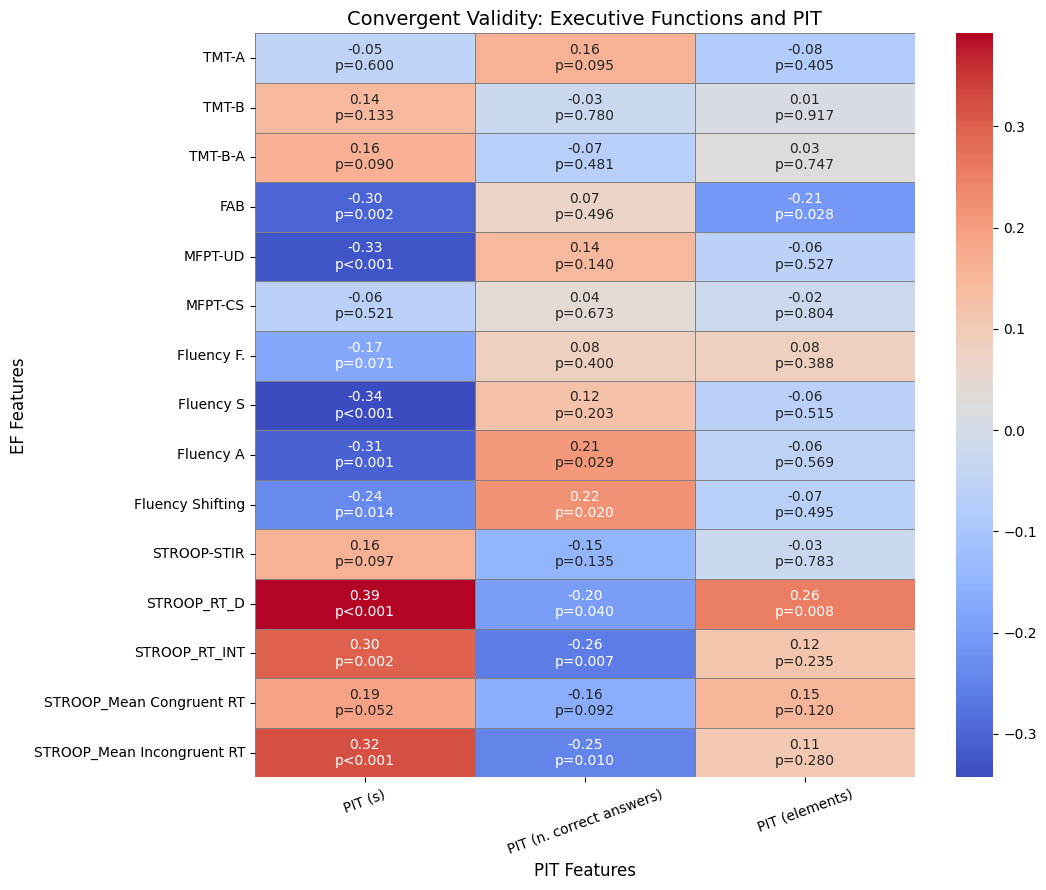

In [30]:
annotation_matrix_adjusted = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    
    if not np.isnan(corr) and not np.isnan(pval):
        if pval < 0.001:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np<0.001"
        else:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_adjusted.loc[ef, pit] = "N/A"

# Plot the adjusted heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_adjusted, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

EF-PIT Spearman + CI: 100%|██████████| 15/15 [00:19<00:00,  1.29s/it]


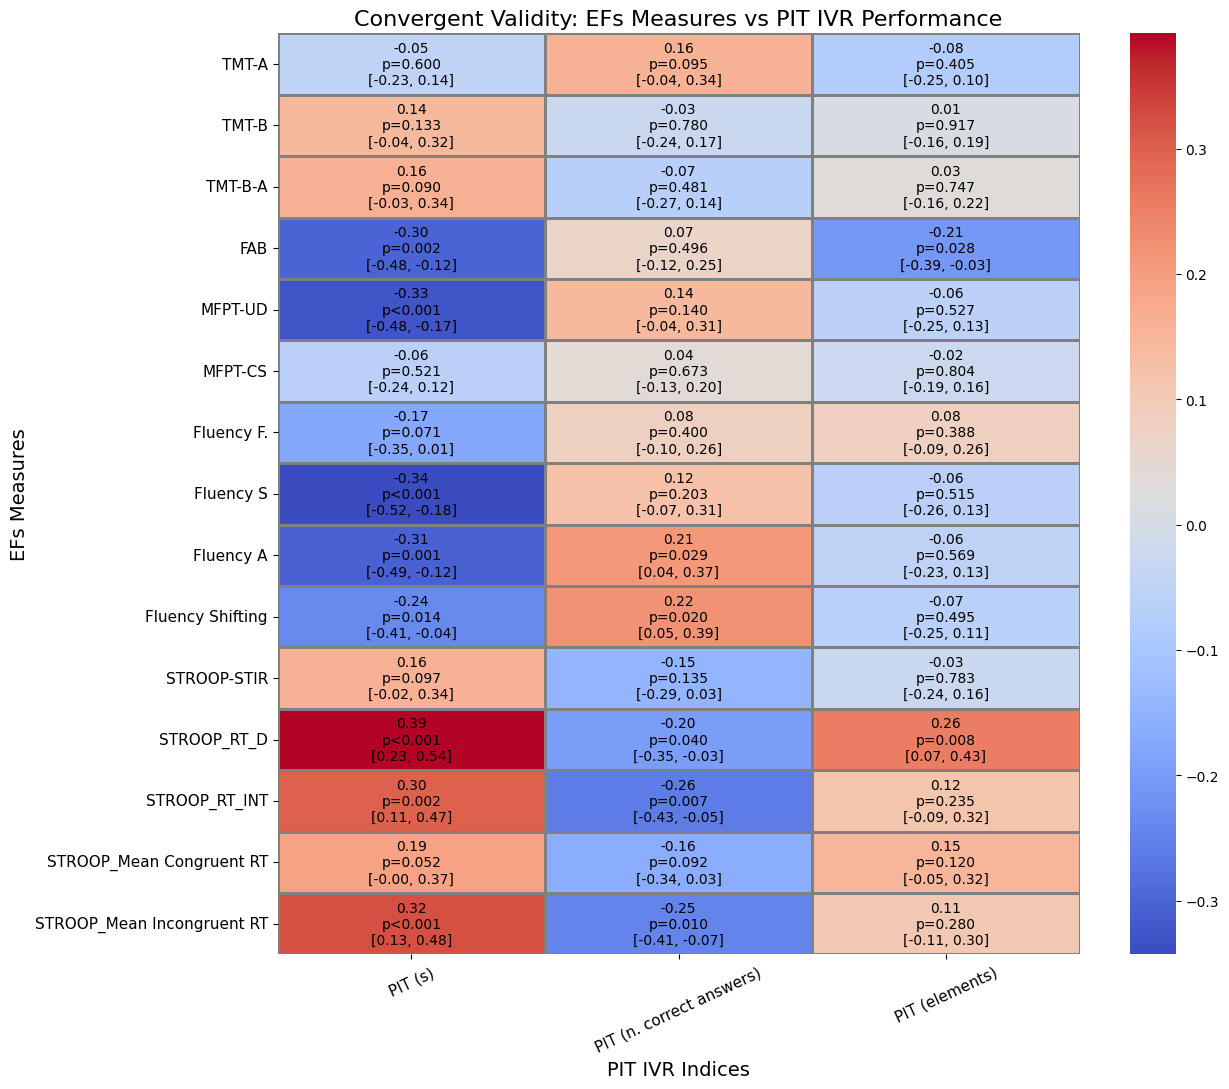

In [31]:

# 1. Define features
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
               'Fluency S', 'Fluency A', 'Fluency Shifting',
               'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT',
               'STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# 2. Bootstrap parameters
n_bootstrap = 1000
ci_lower = 2.5
ci_upper = 97.5

# 3. Result matrices
numeric_matrix_ef = pd.DataFrame(index=EF_features, columns=pit_features, dtype=float)
annotation_matrix_ef = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)
spearman_results_ef = []

# 4. Spearman correlations and bootstrap CIs on df_n
for ef in tqdm(EF_features, desc="EF-PIT Spearman + CI"):
    for pit in pit_features:
        valid_data = df_n[[ef, pit]].dropna()

        if valid_data[ef].nunique() > 1 and valid_data[pit].nunique() > 1:
            # Spearman correlation
            corr, pval = spearmanr(valid_data[ef], valid_data[pit])

            # Bootstrap confidence interval
            corr_values = []
            for _ in range(n_bootstrap):
                sample = valid_data.sample(n=len(valid_data), replace=True)
                if sample[ef].nunique() > 1 and sample[pit].nunique() > 1:
                    boot_corr, _ = spearmanr(sample[ef], sample[pit])
                    if not np.isnan(boot_corr):
                        corr_values.append(boot_corr)

            if len(corr_values) > 0:
                ci_low = np.percentile(corr_values, ci_lower)
                ci_high = np.percentile(corr_values, ci_upper)
            else:
                ci_low = ci_high = np.nan
        else:
            corr = pval = ci_low = ci_high = np.nan

        # Store results
        numeric_matrix_ef.loc[ef, pit] = corr
        if not np.isnan(corr) and not np.isnan(pval):
            pval_str = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
            annotation_matrix_ef.loc[ef, pit] = f"{corr:.2f}\n{pval_str}\n[{ci_low:.2f}, {ci_high:.2f}]"
        else:
            annotation_matrix_ef.loc[ef, pit] = "N/A"

        spearman_results_ef.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval,
            '95% CI Lower': ci_low,
            '95% CI Upper': ci_high
        })

# 5. Plot a readable heatmap
plt.figure(figsize=(13, 11))
sns.heatmap(
    numeric_matrix_ef.astype(float),
    annot=annotation_matrix_ef.values,
    fmt='',
    cmap='coolwarm',
    cbar=True,
    linewidths=1.0,
    linecolor='gray',
    mask=numeric_matrix_ef.isna(),
    annot_kws={"fontsize": 10, "color": "black", "va": "center"}
)
plt.title("Convergent Validity: EFs Measures vs PIT IVR Performance", fontsize=16)
plt.xlabel("PIT IVR Indices", fontsize=14)
plt.ylabel("EFs Measures", fontsize=14)
plt.xticks(rotation=25, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


# Training and testing of ML models

In [32]:
# FIXED FEATURE SET + REUSABLE LEAKAGE-FREE PREPROCESSING

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline

selected_features = features_full.copy()

print("Selected features:")
print(selected_features)


def make_preprocessor(features=None):

    if features is None:
        features = selected_features

    numeric_transformer = Pipeline([
        (
            "imputer",
            KNNImputer(
                n_neighbors=5
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_transformer,
                features
            )
        ],
        remainder="drop"
    )

    return preprocessor

# STANDARD ML PIPELINE
# For models without resampling

def make_pipeline(
    classifier,
    features=None
):

    if features is None:
        features = selected_features

    return Pipeline([
        (
            "preprocessing",
            make_preprocessor(features)
        ),
        (
            "classifier",
            classifier
        )
    ])

# IMBALANCED-LEARNING PIPELINE
# For ROS / RUS / SMOTE

def make_resampling_pipeline(
    classifier,
    sampler,
    features=None
):

    if features is None:
        features = selected_features

    return ImbPipeline([
        (
            "preprocessing",
            make_preprocessor(features)
        ),
        (
            "sampling",
            sampler
        ),
        (
            "classifier",
            classifier
        )
    ])

Selected features:
['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']


## Attempt 1: Multiclass classification

In [33]:
X = (
    df_n[selected_features]
    .apply(pd.to_numeric, errors="coerce")
)

y = df_n["group"].copy()

print("X shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (109, 12)

Class distribution:
group
MCI        57
HC         32
Frailty    20
Name: count, dtype: int64


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(
    f"N. Training sample: {len(y_train)} "
    f"({len(y_train)/len(y)*100:.2f}%)"
)

print(
    f"N. Testing sample: {len(y_test)} "
    f"({len(y_test)/len(y)*100:.2f}%)"
)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTest classes:")
print(y_test.value_counts())

N. Training sample: 76 (69.72%)
N. Testing sample: 33 (30.28%)

Training classes:
group
MCI        40
HC         22
Frailty    14
Name: count, dtype: int64

Test classes:
group
MCI        17
HC         10
Frailty     6
Name: count, dtype: int64


In [35]:
label_mapping = {'HC': 0, 'MCI': 1, 'Frailty': 2}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

In [36]:
y_train.value_counts()

group
1    40
0    22
2    14
Name: count, dtype: int64

In [37]:
y_test.value_counts()

group
1    17
0    10
2     6
Name: count, dtype: int64

Baseline model: Linear Discriminant Analysis \(LDA\)

In [38]:
# BASELINE MODEL — LDA

lda = LinearDiscriminantAnalysis()

lda_pipe = make_pipeline(
    classifier=lda,
    features=selected_features
)


# Fit only on training data
lda_pipe.fit(
    X_train,
    y_train
)


# Predictions
y_train_pred_lda = lda_pipe.predict(
    X_train
)

y_pred_lda = lda_pipe.predict(
    X_test
)


# Probabilities
y_train_prob_lda = lda_pipe.predict_proba(
    X_train
)

y_test_prob_lda = lda_pipe.predict_proba(
    X_test
)


# Classification reports

classes = ["HC", "MCI", "Frailty"]

print("\nLDA Classification Report on Training Set:")

print(
    classification_report(
        y_train,
        y_train_pred_lda,
        target_names=classes
    )
)

print("\nLDA Classification Report on Testing Set:")

print(
    classification_report(
        y_test,
        y_pred_lda,
        target_names=classes
    )
)


auc_roc_train = roc_auc_score(
    y_train,
    y_train_prob_lda,
    multi_class="ovo",
    average="macro"
)

auc_roc_test = roc_auc_score(
    y_test,
    y_test_prob_lda,
    multi_class="ovo",
    average="macro"
)

print(
    f"\nAUC-ROC (OvO) Training: "
    f"{auc_roc_train:.3f}"
)

print(
    f"AUC-ROC (OvO) Test: "
    f"{auc_roc_test:.3f}"
)


LDA Classification Report on Training Set:
              precision    recall  f1-score   support

          HC       0.77      0.77      0.77        22
         MCI       0.93      0.93      0.93        40
     Frailty       0.79      0.79      0.79        14

    accuracy                           0.86        76
   macro avg       0.83      0.83      0.83        76
weighted avg       0.86      0.86      0.86        76


LDA Classification Report on Testing Set:
              precision    recall  f1-score   support

          HC       0.50      0.50      0.50        10
         MCI       0.75      0.71      0.73        17
     Frailty       0.29      0.33      0.31         6

    accuracy                           0.58        33
   macro avg       0.51      0.51      0.51        33
weighted avg       0.59      0.58      0.58        33


AUC-ROC (OvO) Training: 0.953
AUC-ROC (OvO) Test: 0.738


In [39]:
#Training and testing of algorithms: Decision Tree Classifier, Logistic regression, K-NN
#Multiclass classification with One-vs-One (OvO)

models = {

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=4,
            class_weight="balanced",
            random_state=42
        ),

    "LASSO Logistic Regression (OvR)":
        OneVsRestClassifier(
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=3
        )
}

# MULTICLASS — MODEL EVALUATION

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


multiclass_results = []


for model_name, classifier in models.items():

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)


    model_pipe = make_pipeline(
        classifier=classifier,
        features=selected_features
    )


    model_pipe.fit(
        X_train[selected_features],
        y_train
    )


    y_train_pred = model_pipe.predict(
        X_train[selected_features]
    )

    y_test_pred = model_pipe.predict(
        X_test[selected_features]
    )

    y_train_proba = model_pipe.predict_proba(
        X_train[selected_features]
    )

    y_test_proba = model_pipe.predict_proba(
        X_test[selected_features]
    )


    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average="macro"
    )

    train_auc = roc_auc_score(
        y_train,
        y_train_proba,
        multi_class="ovr",
        average="macro"
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="macro"
    )

    test_auc = roc_auc_score(
        y_test,
        y_test_proba,
        multi_class="ovr",
        average="macro"
    )


    print("\nTRAINING")
    print(
        f"Accuracy: {train_accuracy:.3f}"
    )
    print(
        f"Macro F1: {train_f1:.3f}"
    )
    print(
        f"Macro ROC-AUC: {train_auc:.3f}"
    )


    print("\nTEST")
    print(
        f"Accuracy: {test_accuracy:.3f}"
    )
    print(
        f"Macro F1: {test_f1:.3f}"
    )
    print(
        f"Macro ROC-AUC: {test_auc:.3f}"
    )


    print(
        "\nClassification Report — TEST:"
    )

    print(
        classification_report(
            y_test,
            y_test_pred,
            target_names=[
                "HC",
                "MCI",
                "Frailty"
            ],
            zero_division=0
        )
    )


    print(
        "\nConfusion Matrix — TEST:"
    )

    print(
        confusion_matrix(
            y_test,
            y_test_pred
        )
    )

    multiclass_results.append({

        "Model":
            model_name,

        "Train Accuracy":
            train_accuracy,

        "Test Accuracy":
            test_accuracy,

        "Train Macro F1":
            train_f1,

        "Test Macro F1":
            test_f1,

        "Train Macro ROC-AUC":
            train_auc,

        "Test Macro ROC-AUC":
            test_auc
    })


# SUMMARY TABLE

multiclass_results_df = pd.DataFrame(
    multiclass_results
)


print("\n")
print("=" * 70)
print("MULTICLASS SUMMARY")
print("=" * 70)

display(
    multiclass_results_df.round(3)
)



Decision Tree

TRAINING
Accuracy: 0.750
Macro F1: 0.714
Macro ROC-AUC: 0.886

TEST
Accuracy: 0.515
Macro F1: 0.444
Macro ROC-AUC: 0.652

Classification Report — TEST:
              precision    recall  f1-score   support

          HC       0.42      0.50      0.45        10
         MCI       0.85      0.65      0.73        17
     Frailty       0.12      0.17      0.14         6

    accuracy                           0.52        33
   macro avg       0.46      0.44      0.44        33
weighted avg       0.58      0.52      0.54        33


Confusion Matrix — TEST:
[[ 5  0  5]
 [ 4 11  2]
 [ 3  2  1]]


LASSO Logistic Regression (OvR)

TRAINING
Accuracy: 0.842
Macro F1: 0.822
Macro ROC-AUC: 0.945

TEST
Accuracy: 0.636
Macro F1: 0.599
Macro ROC-AUC: 0.749

Classification Report — TEST:
              precision    recall  f1-score   support

          HC       0.54      0.70      0.61        10
         MCI       0.92      0.65      0.76        17
     Frailty       0.38      0.50    

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Train Macro ROC-AUC,Test Macro ROC-AUC
0,Decision Tree,0.750,0.515,0.714,0.444,0.886,0.652
1,LASSO Logistic Regression (OvR),0.842,0.636,0.822,0.599,0.945,0.749
2,KNN,0.789,0.485,0.750,0.450,0.915,0.674


In [40]:
# Training and testing of balanced multiclass algorithms
# Leakage-free: preprocessing is fitted on the training data only
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models_balanced = [
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    KNeighborsClassifier()
]

def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    values = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fp = cm[:, i].sum() - cm[i, i]
        values.append(tn / (tn + fp) if (tn + fp) else np.nan)
    return np.nanmean(values)

results_balanced = []
for name, classifier in zip(model_names, models_balanced):
    model_pipe = make_pipeline(classifier, selected_features)
    model_pipe.fit(X_train, y_train)
    y_train_prob_balanced = model_pipe.predict_proba(X_train)
    y_train_pred_balanced = model_pipe.predict(X_train)
    y_test_prob_balanced = model_pipe.predict_proba(X_test)
    y_test_pred_balanced = model_pipe.predict(X_test)
    auc_roc_train_balanced = roc_auc_score(y_train, y_train_prob_balanced, multi_class="ovo", average="macro")
    auc_roc_test_balanced = roc_auc_score(y_test, y_test_prob_balanced, multi_class="ovo", average="macro")
    results_balanced.append({
        "Model": name,
        "AUC-ROC (Train, Balanced)": auc_roc_train_balanced,
        "AUC-ROC (Test, Balanced)": auc_roc_test_balanced,
        "Classification Report (Train, Balanced)": classification_report(y_train, y_train_pred_balanced),
        "Classification Report (Test, Balanced)": classification_report(y_test, y_test_pred_balanced),
        "Specificity (Train, Balanced)": calculate_specificity(y_train, y_train_pred_balanced),
        "Specificity (Test, Balanced)": calculate_specificity(y_test, y_test_pred_balanced)
    })

for result in results_balanced:
    print(f"Model (Balanced): {result['Model']}")
    print(f"AUC-ROC (Train, Balanced): {result['AUC-ROC (Train, Balanced)']:.3f}")
    print(f"AUC-ROC (Test, Balanced): {result['AUC-ROC (Test, Balanced)']:.3f}")
    print("Classification Report (Training Set, Balanced):")
    print(result["Classification Report (Train, Balanced)"])
    print("Classification Report (Testing Set, Balanced):")
    print(result["Classification Report (Test, Balanced)"])
    print(f"Specificity (Train, Balanced): {result['Specificity (Train, Balanced)']:.3f}")
    print(f"Specificity (Test, Balanced): {result['Specificity (Test, Balanced)']:.3f}")
    print("-" * 60)

Model (Balanced): Decision Tree
AUC-ROC (Train, Balanced): 1.000
AUC-ROC (Test, Balanced): 0.608
Classification Report (Training Set, Balanced):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        40
           2       1.00      1.00      1.00        14

    accuracy                           1.00        76
   macro avg       1.00      1.00      1.00        76
weighted avg       1.00      1.00      1.00        76

Classification Report (Testing Set, Balanced):
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.68      0.76      0.72        17
           2       0.25      0.17      0.20         6

    accuracy                           0.58        33
   macro avg       0.48      0.48      0.47        33
weighted avg       0.55      0.58      0.56        33

Specificity (Train, Balanced): 1.000
Specifici

In [41]:
# Five-fold stratified cross-validation on the training set only
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    KNeighborsClassifier()
]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_results = {}

for name, classifier in zip(model_names, models):
    fold_auc_roc, fold_accuracy, fold_f1_weighted, fold_specificity = [], [], [], []
    all_y_true, all_y_pred = [], []
    for train_index, val_index in kf.split(X_train, y_train):
        X_train_fold = X_train.iloc[train_index]
        X_val_fold = X_train.iloc[val_index]
        y_train_fold = y_train.iloc[train_index]
        y_val_fold = y_train.iloc[val_index]
        fold_pipe = make_pipeline(classifier, selected_features)
        fold_pipe.fit(X_train_fold, y_train_fold)
        y_val_pred = fold_pipe.predict(X_val_fold)
        y_val_prob = fold_pipe.predict_proba(X_val_fold)
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_val_pred)
        fold_auc_roc.append(roc_auc_score(y_val_fold, y_val_prob, multi_class="ovo", average="weighted"))
        fold_accuracy.append(accuracy_score(y_val_fold, y_val_pred))
        fold_f1_weighted.append(f1_score(y_val_fold, y_val_pred, average="weighted"))
        fold_specificity.append(calculate_specificity(y_val_fold, y_val_pred))
    cross_val_results[name] = {
        "Weighted AUC-ROC": np.mean(fold_auc_roc),
        "Weighted Accuracy": np.mean(fold_accuracy),
        "Weighted F1-Score": np.mean(fold_f1_weighted),
        "Weighted Specificity": np.mean(fold_specificity),
        "Overall Classification Report": classification_report(all_y_true, all_y_pred)
    }

for name, results in cross_val_results.items():
    print(f"Model: {name}")
    print(f"Weighted AUC-ROC (training CV): {results['Weighted AUC-ROC']:.3f}")
    print(f"Weighted Accuracy (training CV): {results['Weighted Accuracy']:.3f}")
    print(f"Weighted F1-Score (training CV): {results['Weighted F1-Score']:.3f}")
    print(f"Weighted Specificity (training CV): {results['Weighted Specificity']:.3f}")
    print(results["Overall Classification Report"])
    print("-" * 60)

Model: Decision Tree
Weighted AUC-ROC (training CV): 0.519
Weighted Accuracy (training CV): 0.447
Weighted F1-Score (training CV): 0.425
Weighted Specificity (training CV): 0.690
              precision    recall  f1-score   support

           0       0.32      0.32      0.32        22
           1       0.58      0.62      0.60        40
           2       0.18      0.14      0.16        14

    accuracy                           0.45        76
   macro avg       0.36      0.36      0.36        76
weighted avg       0.43      0.45      0.44        76

------------------------------------------------------------
Model: Logistic Regression
Weighted AUC-ROC (training CV): 0.860
Weighted Accuracy (training CV): 0.658
Weighted F1-Score (training CV): 0.642
Weighted Specificity (training CV): 0.818
              precision    recall  f1-score   support

           0       0.59      0.59      0.59        22
           1       0.77      0.75      0.76        40
           2       0.47      0.

In [42]:
# Hyperparameter search on the training set only
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
classifiers = [
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    KNeighborsClassifier()
]
param_grids = [
    {
        "classifier__criterion": ["gini", "entropy"],
        "classifier__max_depth": [None, 10, 20, 30],
        "classifier__min_samples_split": [2, 5, 10]
    },
    {
        "classifier__estimator__C": [0.1, 1, 10],
        "classifier__estimator__solver": ["lbfgs", "liblinear"]
    },
    {
        "classifier__n_neighbors": [3, 5, 7],
        "classifier__weights": ["uniform", "distance"]
    }
]
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}
grid_search_results = {}

for name, classifier, param_grid in zip(model_names, classifiers, param_grids):
    search_pipe = make_pipeline(classifier, selected_features)
    grid_search = GridSearchCV(
        search_pipe,
        param_grid,
        cv=kf,
        scoring="roc_auc_ovo",
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    grid_search_results[name] = {
        "Best parameters": grid_search.best_params_,
        "Training CV ROC-AUC": grid_search.best_score_
    }
    print(f"Best hyperparameters for {name}: {grid_search.best_params_}")
    print(f"Best training CV AUC-ROC for {name}: {grid_search.best_score_:.3f}")
    print("-" * 60)

best_model_name = max(grid_search_results, key=lambda name: grid_search_results[name]["Training CV ROC-AUC"])
print(f"Selected model from training CV only: {best_model_name}")

# The held-out test is used once after model selection
selected_multiclass_model = best_models[best_model_name]
y_selected_test = selected_multiclass_model.predict(X_test)
y_selected_proba = selected_multiclass_model.predict_proba(X_test)
print("Held-out test classification report for the selected multiclass model:")
print(classification_report(y_test, y_selected_test, zero_division=0))
print("Held-out test macro ROC-AUC:", roc_auc_score(y_test, y_selected_proba, multi_class="ovr", average="macro"))

Best hyperparameters for Decision Tree: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_split': 10}
Best training CV AUC-ROC for Decision Tree: 0.635
------------------------------------------------------------
Best hyperparameters for Logistic Regression: {'classifier__estimator__C': 10, 'classifier__estimator__solver': 'lbfgs'}
Best training CV AUC-ROC for Logistic Regression: 0.841
------------------------------------------------------------
Best hyperparameters for K-Nearest Neighbors (KNN): {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
Best training CV AUC-ROC for K-Nearest Neighbors (KNN): 0.749
------------------------------------------------------------
Selected model from training CV only: Logistic Regression
Held-out test classification report for the selected multiclass model:
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.80    

### Testing Multiclass LR

Logistic Regression Multiclass
              precision    recall  f1-score   support

     Frailty       0.29      0.33      0.31         6
          HC       0.54      0.70      0.61        10
         MCI       0.85      0.65      0.73        17

    accuracy                           0.61        33
   macro avg       0.56      0.56      0.55        33
weighted avg       0.65      0.61      0.62        33



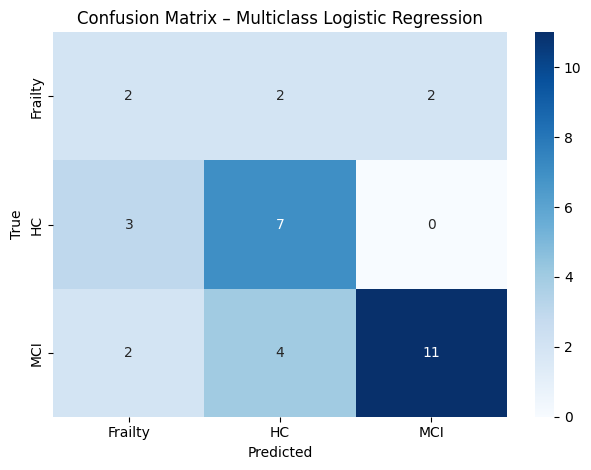


Specificity per class (One-vs-Rest):
Frailty: 0.815
HC: 0.739
MCI: 0.875


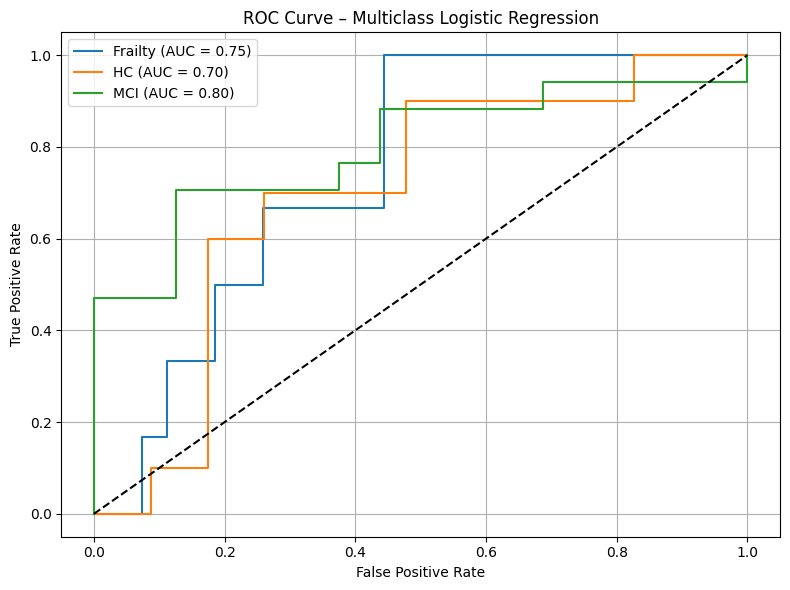

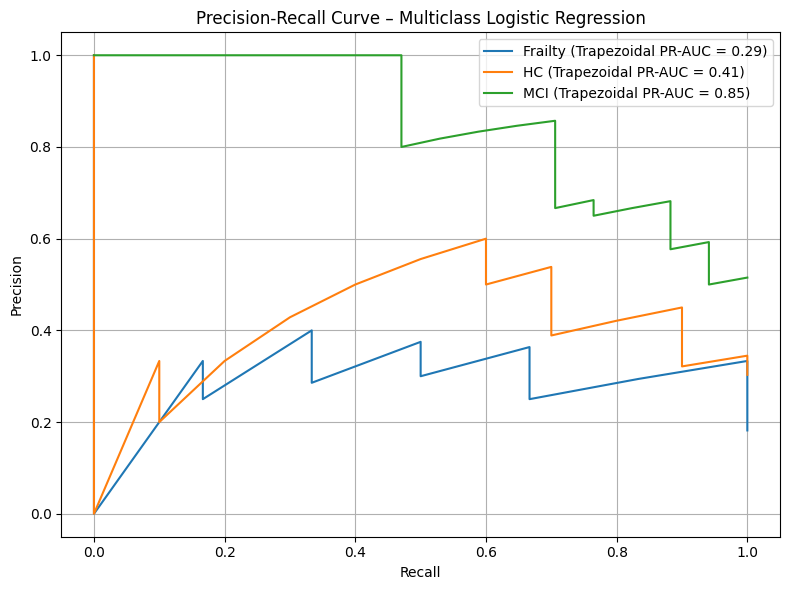


Coefficients per class (OvR):
                          Frailty     HC    MCI
TMT-B                      -1.101  0.391  0.267
TMT-B-A                     0.959 -0.177 -0.609
FAB                         1.192  0.735 -1.185
MFPT-UD                    -0.596  1.312 -0.822
MFPT-CS                     0.550 -0.644  0.256
Fluency S                   0.161  0.864 -1.223
Fluency A                   0.593  0.708 -1.265
Fluency Shifting           -0.572  0.059  0.366
STROOP-STIR                -0.332  0.252  0.048
PIT (s)                    -0.942  0.790 -0.149
PIT (n. correct answers)    1.032  0.027 -0.358
PIT (elements)              0.982 -0.254 -0.631

Top features for class Frailty:
FAB                         1.192400
TMT-B                      -1.100504
PIT (n. correct answers)    1.031672
PIT (elements)              0.982365
TMT-B-A                     0.959176
PIT (s)                    -0.941570
MFPT-UD                    -0.596062
Fluency A                   0.593253
Fluency Shifting

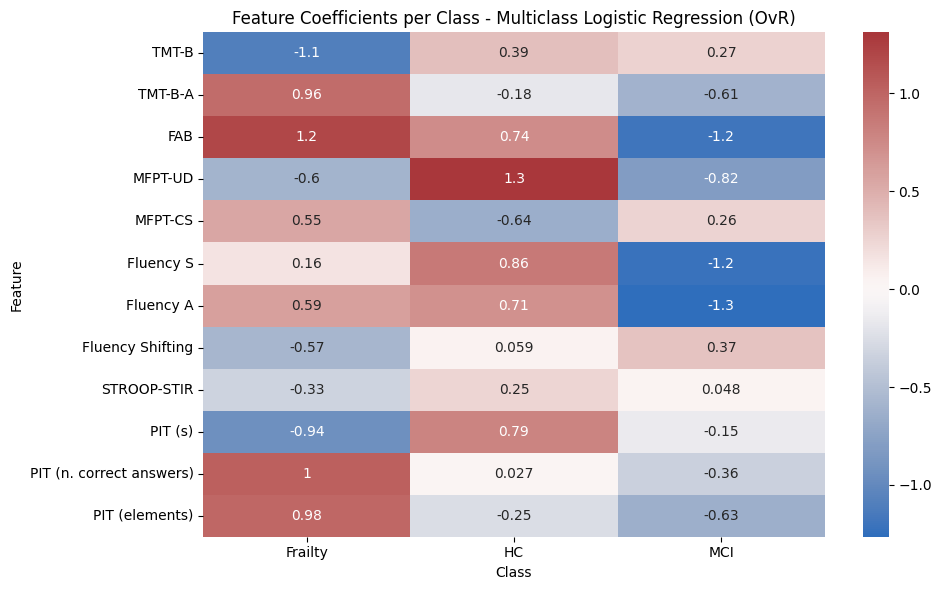

In [43]:
# Leakage-free: use the raw selected feature set
X = df_n[selected_features].apply(pd.to_numeric, errors="coerce")

# Target: multiclass
y = df_n['group']  

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train Logistic Regression (OvR) with fold-safe preprocessing
classifier = OneVsRestClassifier(LogisticRegression(C=1, solver='lbfgs', class_weight='balanced', max_iter=1000))
model = make_pipeline(classifier, selected_features)
model.fit(X_train, y_train)

#Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Classification report
print("Logistic Regression Multiclass")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Multiclass Logistic Regression")
plt.tight_layout()
plt.show()

print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for i, cls in enumerate(model.classes_):
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable (only one class present)")

#Binarize y_test for One-vs-Rest metrics
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

#ROC Curves per class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – Multiclass Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#PR Curves per class
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (Trapezoidal PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – Multiclass Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Macro metrics dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "Trapezoidal PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

#Save metrics
try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# Coefficients per class
coef_matrix = np.vstack([est.coef_.ravel() for est in model.named_steps['classifier'].estimators_]).T
coef_df = pd.DataFrame(coef_matrix, index=X.columns, columns=model.classes_)

print("\nCoefficients per class (OvR):")
print(coef_df.round(3))

# Top features per class
for cls in model.classes_:
    print(f"\nTop features for class {cls}:")
    print(coef_df[cls].sort_values(key=abs, ascending=False).head(10))

# Plot all coefficients in a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class - Multiclass Logistic Regression (OvR)")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Multiclass with bootstrapping

In [44]:
#Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

# Binarize y_test
y_test_bin = label_binarize(y_test, classes=model.classes_)
y_proba = model.predict_proba(X_test)


boot_metrics = {
    "accuracy": [],
    "precision_macro": [],
    "recall_macro": [],
    "f1_macro": [],
    "roc_auc_macro": [],
    "trapezoidal_pr_auc_macro": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = model.predict(X_test.iloc[indices])
    y_proba_b = model.predict_proba(X_test.iloc[indices])

    # Skip if any class is missing
    if len(np.unique(y_true_b)) < 2:
        continue

    y_true_bin_b = label_binarize(y_true_b, classes=model.classes_)

    # Trapezoidal PR-AUC macro
    pr_auc_list = []
    for i in range(len(model.classes_)):
        prec, rec, _ = precision_recall_curve(y_true_bin_b[:, i], y_proba_b[:, i])
        if len(prec) > 1:
            pr_auc_list.append(auc(rec, prec))
    pr_auc_macro = np.mean(pr_auc_list)

    # ROC-AUC macro
    try:
        roc_auc_macro = roc_auc_score(y_true_bin_b, y_proba_b, average='macro', multi_class='ovr')
    except ValueError:
        roc_auc_macro = np.nan

 
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision_macro"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    boot_metrics["recall_macro"].append(recall_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["f1_macro"].append(f1_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["roc_auc_macro"].append(roc_auc_macro)
    boot_metrics["trapezoidal_pr_auc_macro"].append(pr_auc_macro)


print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    values = np.array(values)
    mean_val = np.nanmean(values)
    std_val = np.nanstd(values)
    ci_low = np.nanpercentile(values, 2.5)
    ci_high = np.nanpercentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

#Coefficients per class
print("\nCoefficients by class (one-vs-rest):")
coef_df = pd.DataFrame(
    np.vstack([est.coef_.ravel() for est in model.named_steps['classifier'].estimators_]).T,
    index=X_test.columns,
    columns=model.classes_
)
print(coef_df.round(3))



Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.605 ± 0.087 | 95% CI [0.424, 0.788]
PRECISION_MACRO: 0.554 ± 0.086 | 95% CI [0.400, 0.733]
RECALL_MACRO: 0.558 ± 0.095 | 95% CI [0.377, 0.745]
F1_MACRO: 0.537 ± 0.089 | 95% CI [0.375, 0.715]
ROC_AUC_MACRO: 0.746 ± 0.064 | 95% CI [0.626, 0.865]
TRAPEZOIDAL_PR_AUC_MACRO: 0.527 ± 0.066 | 95% CI [0.427, 0.686]

Coefficients by class (one-vs-rest):
                          Frailty     HC    MCI
TMT-B                      -1.101  0.391  0.267
TMT-B-A                     0.959 -0.177 -0.609
FAB                         1.192  0.735 -1.185
MFPT-UD                    -0.596  1.312 -0.822
MFPT-CS                     0.550 -0.644  0.256
Fluency S                   0.161  0.864 -1.223
Fluency A                   0.593  0.708 -1.265
Fluency Shifting           -0.572  0.059  0.366
STROOP-STIR                -0.332  0.252  0.048
PIT (s)                    -0.942  0.790 -0.149
PIT (n. correct answers)    1.032  0.027 -0.358
PIT (elements)       

### Multiclass LR with SMOTE

SMOTE training CV (5 folds):
accuracy: 0.647 ± 0.088
f1_macro: 0.571 ± 0.099
roc_auc_ovr: 0.844 ± 0.026
Logistic Regression Multiclass – SMOTE
              precision    recall  f1-score   support

     Frailty       0.25      0.33      0.29         6
          HC       0.50      0.70      0.58        10
         MCI       0.82      0.53      0.64        17

    accuracy                           0.55        33
   macro avg       0.52      0.52      0.50        33
weighted avg       0.62      0.55      0.56        33



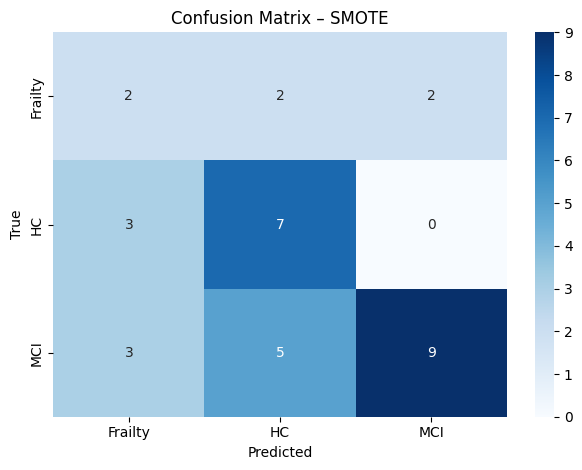


Specificity per class (One-vs-Rest):
Frailty: 0.778
HC: 0.696
MCI: 0.875


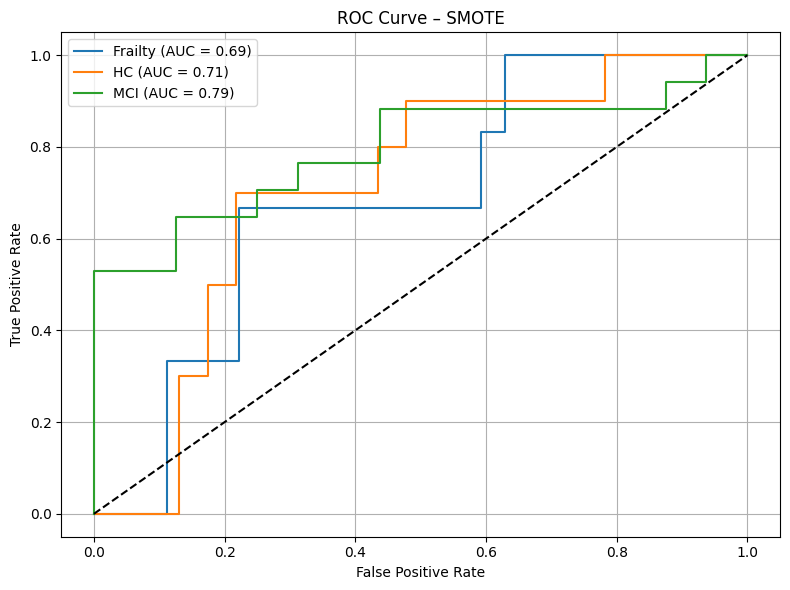

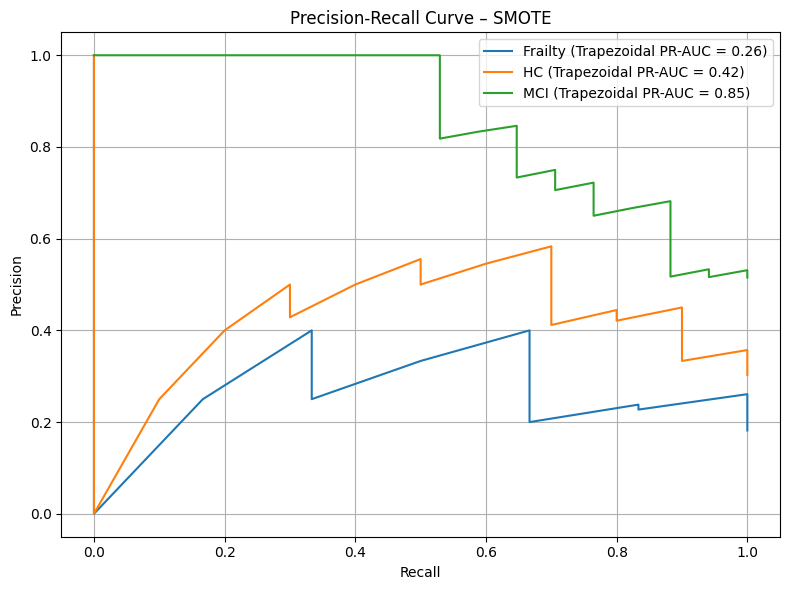


Coefficients per class (SMOTE):
                          Frailty     HC    MCI
TMT-B                      -1.746  0.902  0.668
TMT-B-A                     1.216 -0.320 -0.932
FAB                         1.182  0.760 -1.203
MFPT-UD                    -0.682  1.529 -0.755
MFPT-CS                     0.654 -0.769  0.276
Fluency S                   0.032  0.932 -1.443
Fluency A                   0.462  0.916 -1.625
Fluency Shifting           -0.764  0.200  0.586
STROOP-STIR                -0.118  0.072  0.025
PIT (s)                    -1.243  1.010  0.072
PIT (n. correct answers)    1.275 -0.238 -0.480
PIT (elements)              1.187 -0.685 -0.677


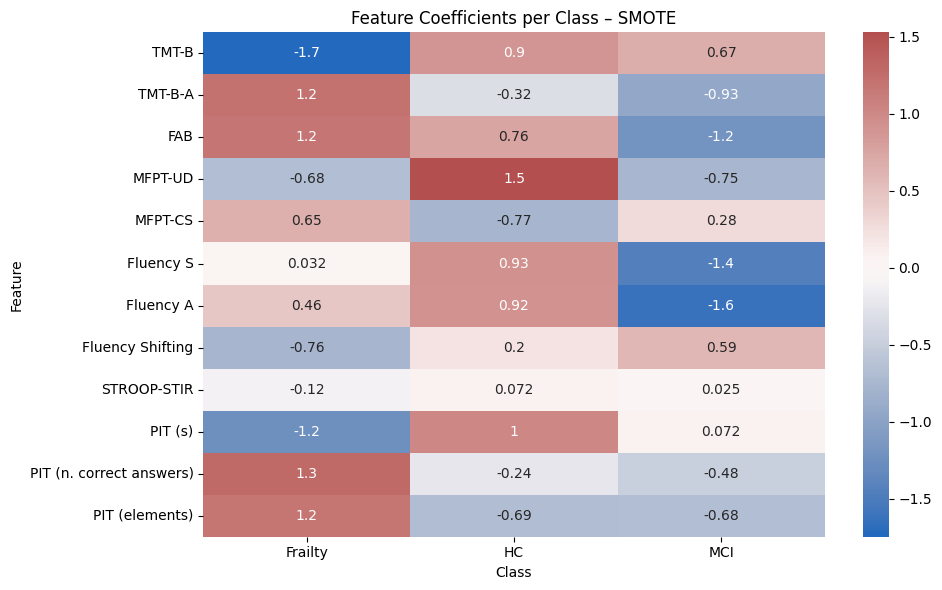

In [45]:
# Leakage-free: use the raw selected feature set
X = df_n[selected_features].apply(pd.to_numeric, errors="coerce")

# Multiclass target
y = df_n['group']  

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE and preprocessing remain inside the pipeline for both CV and final training
classifier = OneVsRestClassifier(LogisticRegression(C=1, solver='lbfgs', class_weight='balanced', max_iter=1000))
model = make_resampling_pipeline(classifier, SMOTE(random_state=42), selected_features)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_smote = cross_validate(model, X_train, y_train, cv=cv, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
print('SMOTE training CV (5 folds):')
for metric in ['accuracy', 'f1_macro', 'roc_auc_ovr']:
    values = cv_smote[f'test_{metric}']
    print(f'{metric}: {values.mean():.3f} ± {values.std():.3f}')
model.fit(X_train, y_train)

#Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Report
print("Logistic Regression Multiclass – SMOTE")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – SMOTE")
plt.tight_layout()
plt.show()

#Specificity per class (OvR)
print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for cls in model.classes_:
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable")

#ROC and PR curves
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

#ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#PR curves
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (Trapezoidal PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Save metrics to dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression – SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "Trapezoidal PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

#Coefficients per class
coef_matrix = np.vstack([est.coef_.ravel() for est in model.named_steps['classifier'].estimators_]).T
coef_df = pd.DataFrame(coef_matrix, index=X.columns, columns=model.classes_)
print("\nCoefficients per class (SMOTE):")
print(coef_df.round(3))

#Plot heatmap of coefficients
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class – SMOTE")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Attemp 2: Multiple binaries classifications

Multiple binary classifications \(MCI vs All, MCI vs Frailty, HC vs Frailty\) were performed with the following models \(LASSO LR, DT, KNN\) and resampling techniques \(random oversampling and undersampling, depending on the disparity\)

In [46]:
df_mci_all = df_n[df_n['group'].isin(['MCI', 'HC', 'Frailty'])].copy()
X = df_mci_all[selected_features].apply(pd.to_numeric, errors="coerce")

# Recode target as binary: 1 = MCI, 0 = all others
y = df_mci_all['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train LDA
lda = make_pipeline(LinearDiscriminantAnalysis(), selected_features)
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]  # Probability for class 1

# Evaluation
print("MCI vs All – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


MCI vs All – LDA
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.80      0.71      0.75        17

    accuracy                           0.76        33
   macro avg       0.76      0.76      0.76        33
weighted avg       0.76      0.76      0.76        33

ROC-AUC: 0.7830882352941176


In [47]:
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Features
X = df_hc_frailty[selected_features].apply(pd.to_numeric, errors="coerce")

# Label: 1 = Frailty, 0 = HC
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = make_pipeline(LinearDiscriminantAnalysis(), selected_features)
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("HC vs Frailty – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

HC vs Frailty – LDA
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.60      0.50      0.55         6

    accuracy                           0.69        16
   macro avg       0.66      0.65      0.65        16
weighted avg       0.68      0.69      0.68        16

ROC-AUC: 0.7


In [48]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[selected_features].apply(pd.to_numeric, errors="coerce")

# Label: 1 = Frailty, 0 = MCI
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = make_pipeline(LinearDiscriminantAnalysis(), selected_features)
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("Frailty vs MCI – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Frailty vs MCI – LDA
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        18
           1       1.00      0.33      0.50         6

    accuracy                           0.83        24
   macro avg       0.91      0.67      0.70        24
weighted avg       0.86      0.83      0.80        24

ROC-AUC: 0.9537037037037037


In [49]:
features = features_full.copy()

def run_pipeline(target_mapping, label, sampling=None):
    df_copy = df_n.copy()
    df_copy["Target"] = df_copy["group"].map(target_mapping)
    df_copy = df_copy[df_copy["Target"].isin([0, 1])].copy()
    X = df_copy[features].apply(pd.to_numeric, errors="coerce")
    y = df_copy["Target"].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )
    sampler = None
    if sampling == "over":
        sampler = RandomOverSampler(random_state=42)
    elif sampling == "under":
        sampler = RandomUnderSampler(random_state=42)

    models = {
        "LASSO Logistic Regression": LogisticRegression(
            penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=4, class_weight="balanced", random_state=42
        ),
        "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
    results = []

    for name, classifier in models.items():
        if sampler is None:
            model_pipe = make_pipeline(classifier, features)
        else:
            model_pipe = make_resampling_pipeline(classifier, sampler, features)

        cv_scores = cross_validate(
            model_pipe, X_train, y_train, cv=cv, scoring=scoring,
            n_jobs=-1, return_train_score=False
        )
        model_pipe.fit(X_train, y_train)
        y_pred = model_pipe.predict(X_test)
        y_proba = model_pipe.predict_proba(X_test)[:, 1]
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        results.append({
            "Label": label,
            "Sampling": sampling or "none",
            "Model": name,
            "CV Accuracy": cv_scores["test_accuracy"].mean(),
            "CV Precision": cv_scores["test_precision"].mean(),
            "CV Recall": cv_scores["test_recall"].mean(),
            "CV F1-score": cv_scores["test_f1"].mean(),
            "CV ROC-AUC": cv_scores["test_roc_auc"].mean(),
            "CV Average Precision": cv_scores["test_average_precision"].mean(),
            "Test Accuracy": accuracy_score(y_test, y_pred),
            "Test Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test Recall": recall_score(y_test, y_pred),
            "Test Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "Test F1-score": f1_score(y_test, y_pred),
            "Test ROC-AUC": roc_auc_score(y_test, y_proba),
            "Test Average Precision": average_precision_score(y_test, y_proba)
        })
    return results

all_results = []

# MCI vs all: no resampling and random oversampling
all_results += run_pipeline({"MCI": 1, "HC": 0, "Frailty": 0}, "MCI vs ALL", sampling=None)
all_results += run_pipeline({"MCI": 1, "HC": 0, "Frailty": 0}, "MCI vs ALL", sampling="over")

# HC vs Frailty: no resampling and random oversampling
all_results += run_pipeline({"HC": 0, "Frailty": 1}, "HC vs FRAILTY", sampling=None)
all_results += run_pipeline({"HC": 0, "Frailty": 1}, "HC vs FRAILTY", sampling="over")

# MCI vs Frailty: no resampling and random undersampling
all_results += run_pipeline({"MCI": 1, "Frailty": 0}, "MCI vs FRAILTY", sampling=None)
all_results += run_pipeline({"MCI": 1, "Frailty": 0}, "MCI vs FRAILTY", sampling="under")

results_df = pd.DataFrame(all_results).round(3)
display(results_df)

cv_best_models_df = results_df.loc[
    results_df.groupby("Label")["CV F1-score"].idxmax()
].reset_index(drop=True)

print("Exploratory CV winners in the current cleaned dataset:")
display(cv_best_models_df)

FINAL_SAMPLING = {
    "MCI vs ALL": "ROS",
    "HC vs FRAILTY": "NoR",
    "MCI vs FRAILTY": "RUS"
}

final_config_df = pd.DataFrame({
    "Task": FINAL_SAMPLING.keys(),
    "Locked sampling strategy": FINAL_SAMPLING.values()
})

print("\nLocked final configurations:")
display(final_config_df)

,Label,Sampling,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Average Precision,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1-score,Test ROC-AUC,Test Average Precision
0,MCI vs ALL,none,LASSO Logistic Regression,0.803,0.850,0.775,0.800,0.925,0.948,0.727,0.833,0.588,0.875,0.690,0.801,0.847
1,MCI vs ALL,none,Decision Tree,0.738,0.797,0.725,0.741,0.749,0.723,0.606,0.750,0.353,0.875,0.480,0.610,0.624
2,MCI vs ALL,none,KNN (k=3),0.723,0.777,0.675,0.715,0.813,0.836,0.636,0.692,0.529,0.750,0.600,0.743,0.771
3,MCI vs ALL,over,LASSO Logistic Regression,0.803,0.850,0.775,0.800,0.932,0.950,0.727,0.833,0.588,0.875,0.690,0.794,0.837
4,MCI vs ALL,over,Decision Tree,0.712,0.770,0.700,0.717,0.718,0.699,0.606,0.750,0.353,0.875,0.480,0.610,0.624
5,MCI vs ALL,over,KNN (k=3),0.737,0.803,0.675,0.724,0.805,0.835,0.636,0.692,0.529,0.750,0.600,0.743,0.771
6,HC vs FRAILTY,none,LASSO Logistic Regression,0.554,0.430,0.467,0.411,0.590,0.588,0.562,0.429,0.500,0.600,0.462,0.550,0.569
7,HC vs FRAILTY,none,Decision Tree,0.493,0.263,0.367,0.300,0.453,0.411,0.500,0.250,0.167,0.700,0.200,0.417,0.354
8,HC vs FRAILTY,none,KNN (k=3),0.525,0.350,0.233,0.247,0.572,0.477,0.562,0.400,0.333,0.700,0.364,0.467,0.369
9,HC vs FRAILTY,over,LASSO Logistic Regression,0.607,0.547,0.467,0.441,0.617,0.627,0.500,0.375,0.500,0.500,0.429,0.617,0.533


Exploratory CV winners in the current cleaned dataset:


,Label,Sampling,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Average Precision,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1-score,Test ROC-AUC,Test Average Precision
0,HC vs FRAILTY,over,LASSO Logistic Regression,0.607,0.547,0.467,0.441,0.617,0.627,0.500,0.375,0.500,0.500,0.429,0.617,0.533
1,MCI vs ALL,none,LASSO Logistic Regression,0.803,0.850,0.775,0.800,0.925,0.948,0.727,0.833,0.588,0.875,0.690,0.801,0.847
2,MCI vs FRAILTY,none,LASSO Logistic Regression,0.756,0.896,0.775,0.822,0.867,0.961,0.750,0.875,0.778,0.667,0.824,0.852,0.957



Locked final configurations:


,Task,Locked sampling strategy
0,MCI vs ALL,ROS
1,HC vs FRAILTY,NoR
2,MCI vs FRAILTY,RUS


# Attempt 3: LASSO LR

##  MCI vs All

Cross-Validation Results (5-fold):
Accuracy: 0.803 ± 0.070
F1-score: 0.800 ± 0.079
ROC-AUC:  0.925 ± 0.053
Average Precision: 0.948 ± 0.034
MCI vs (HC + Frailty)
              precision    recall  f1-score   support

           0       0.67      0.88      0.76        16
           1       0.83      0.59      0.69        17

    accuracy                           0.73        33
   macro avg       0.75      0.73      0.72        33
weighted avg       0.75      0.73      0.72        33

Accuracy: 0.727
Precision: 0.833
Recall (Sensitivity): 0.588
Specificity: 0.875
F1-score: 0.690
ROC-AUC: 0.801
Trapezoidal PR-AUC: 0.842

Non-zero coefficients (LASSO-selected features):
           Feature  Coefficient
5        Fluency S    -1.321687
6        Fluency A    -1.105331
2              FAB    -0.926543
3          MFPT-UD    -0.646868
11  PIT (elements)    -0.334598
8      STROOP-STIR     0.201889
1          TMT-B-A    -0.135492
4          MFPT-CS    -0.029495


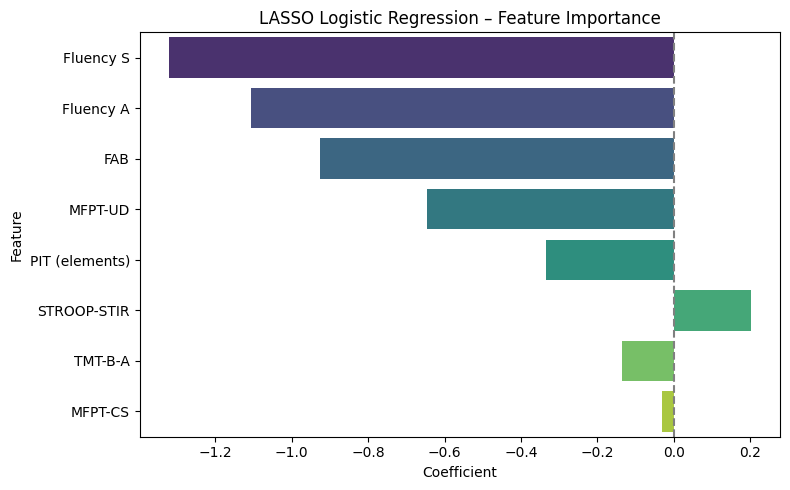

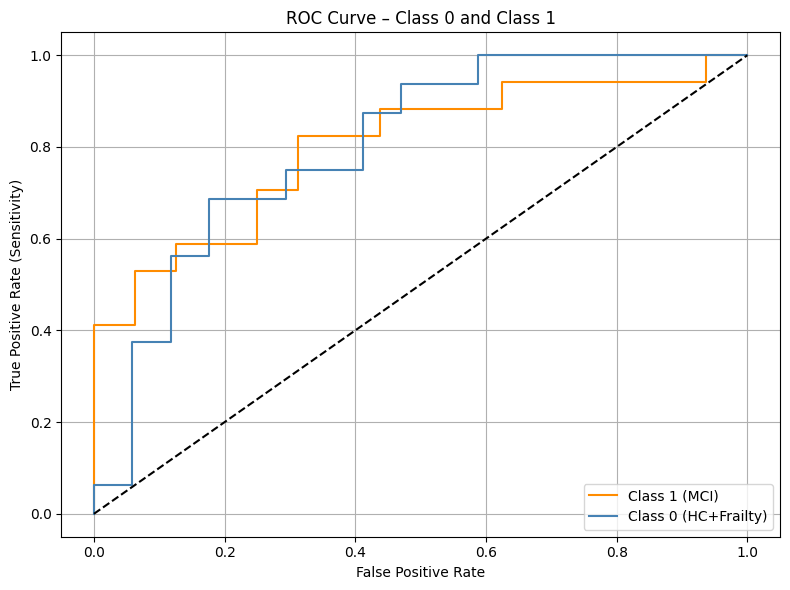

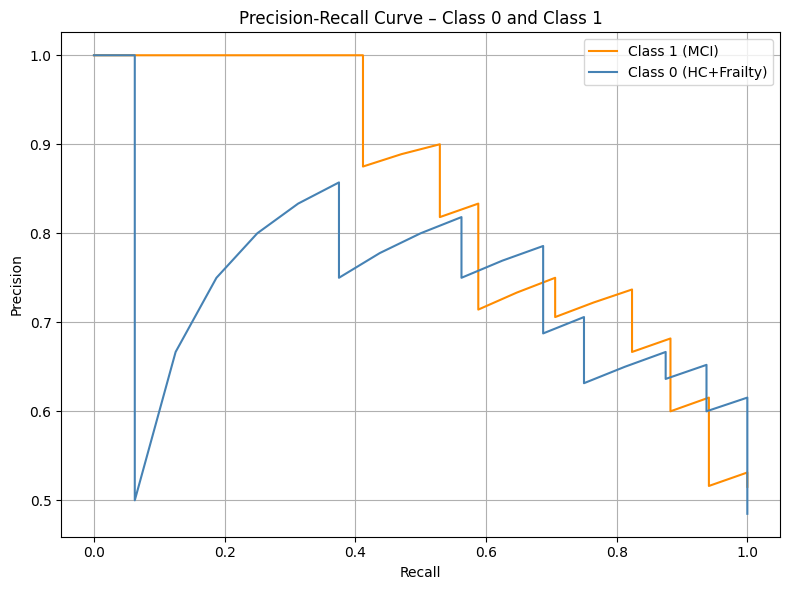

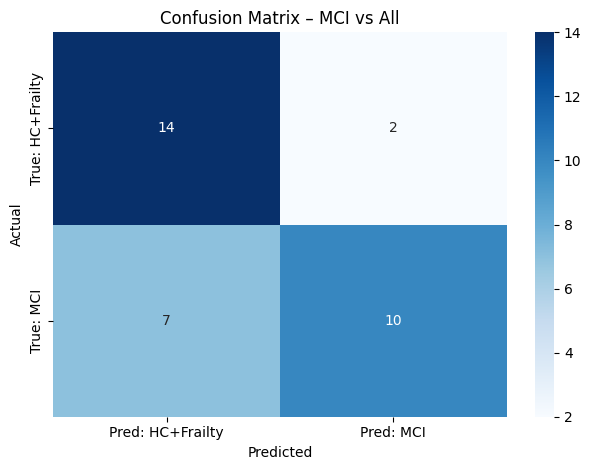


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.725 ± 0.080 | 95% CI [0.576, 0.879]
PRECISION: 0.827 ± 0.113 | 95% CI [0.583, 1.000]
RECALL: 0.589 ± 0.125 | 95% CI [0.333, 0.824]
SPECIFICITY: 0.868 ± 0.089 | 95% CI [0.684, 1.000]
F1: 0.680 ± 0.105 | 95% CI [0.455, 0.867]
ROC_AUC: 0.799 ± 0.081 | 95% CI [0.620, 0.944]
TRAPEZOIDAL_PR_AUC: 0.837 ± 0.077 | 95% CI [0.657, 0.954]

Training set metrics:
Accuracy: 0.868
Precision: 0.941
Recall (Sensitivity): 0.800
Specificity: 0.944
F1-score: 0.865
ROC-AUC: 0.958
Trapezoidal PR-AUC: 0.968


In [50]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Final model fitted on the training set only
model = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)  # same as sensitivity
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)


print("MCI vs (HC + Frailty)")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Extract and display non-zero coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.named_steps['classifier'].coef_[0]
})

# Keep only non-zero coefficients
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("\nNon-zero coefficients (LASSO-selected features):")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()


# ROC Curve for both classes
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve for both classes
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 (MCI)', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All")
plt.tight_layout()
plt.show()

# Bootstrapping all metrics
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class
    if len(np.unique(y_true_b)) < 2:
        continue

    
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue  # skip bootstrap samples with invalid confusion matrix

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    # Metrics
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

# Print bootstrapped results
print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

# Training set metrics
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
tn_t, fp_t, fn_t, tp_t = cm_train.ravel()
specificity_train = tn_t / (tn_t + fp_t)
sensitivity_train = tp_t / (tp_t + fn_t)

acc_train = accuracy_score(y_train, y_train_pred)
prec_train = precision_score(y_train, y_train_pred, zero_division=0)
rec_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_train_proba)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("\nTraining set metrics:")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO Logistic",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "Trapezoidal PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

## \+MCI vs All \(with random oversampling\)

Cross-Validation Results (5-fold):
Accuracy: 0.803 ± 0.070
F1-score: 0.800 ± 0.079
ROC-AUC:  0.932 ± 0.046
Average Precision: 0.950 ± 0.032
Training set metrics
Accuracy: 0.868
Precision: 0.941
Recall (Sensitivity): 0.800
Specificity: 0.944
F1-score: 0.865
ROC-AUC: 0.958
Trapezoidal PR-AUC: 0.968
Test set metrics
              precision    recall  f1-score   support

           0       0.67      0.88      0.76        16
           1       0.83      0.59      0.69        17

    accuracy                           0.73        33
   macro avg       0.75      0.73      0.72        33
weighted avg       0.75      0.73      0.72        33

Accuracy: 0.727
Precision: 0.833
Recall (Sensitivity): 0.588
Specificity: 0.875
F1-score: 0.690
ROC-AUC: 0.794
Trapezoidal PR-AUC: 0.832


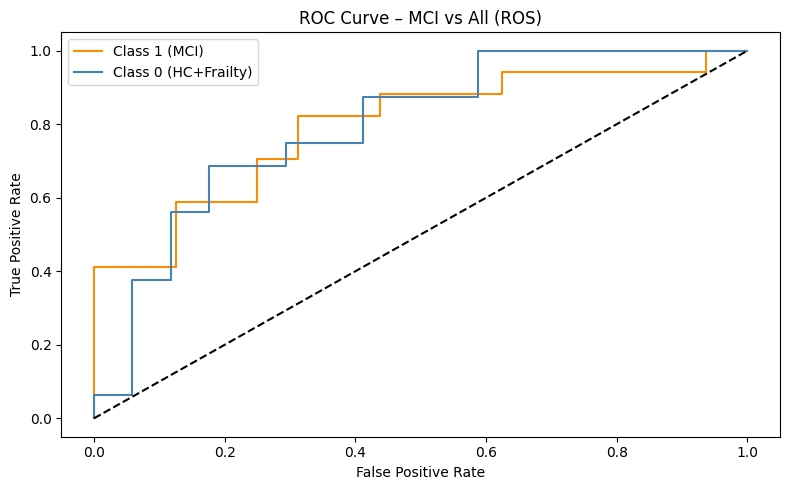

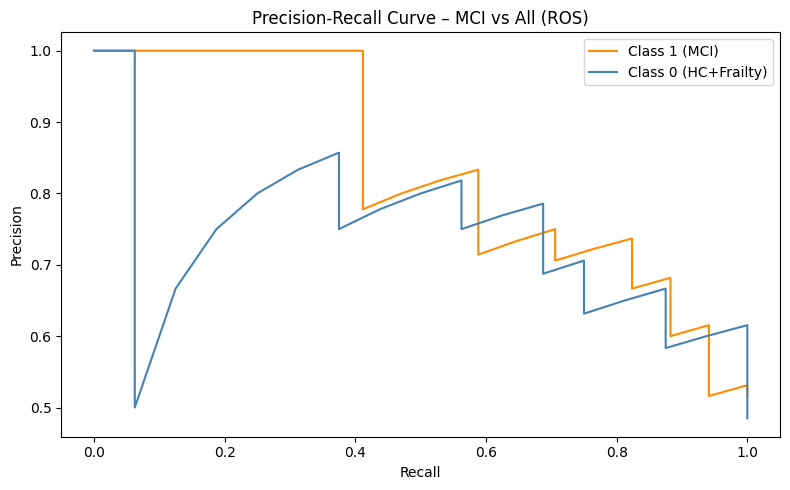

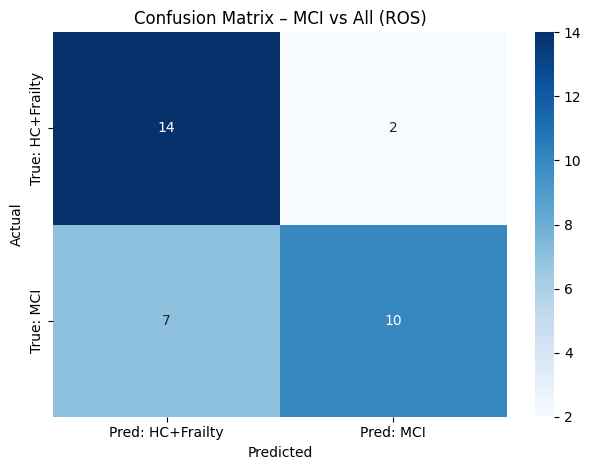

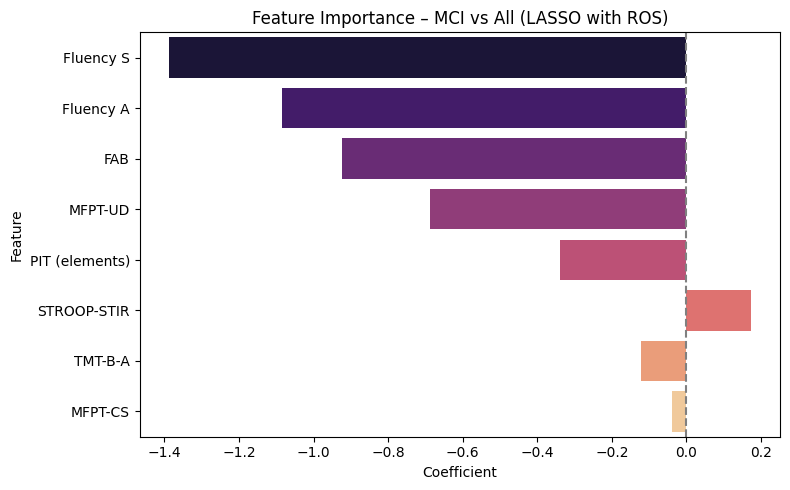

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.725 ± 0.080 | 95% CI [0.576, 0.879]
PRECISION: 0.827 ± 0.113 | 95% CI [0.583, 1.000]
RECALL: 0.589 ± 0.125 | 95% CI [0.333, 0.824]
SPECIFICITY: 0.868 ± 0.089 | 95% CI [0.684, 1.000]
F1: 0.680 ± 0.105 | 95% CI [0.455, 0.867]
ROC_AUC: 0.791 ± 0.082 | 95% CI [0.615, 0.938]
TRAPEZOIDAL_PR_AUC: 0.826 ± 0.080 | 95% CI [0.641, 0.952]


In [51]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    RandomOverSampler(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (ROS)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "Trapezoidal PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (ROS)")
plt.tight_layout()
plt.show()

coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with ROS)')
plt.tight_layout()
plt.show()

n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## MCI vs All \(with SMOTE\)

Cross-Validation Results (5-fold):
Accuracy: 0.777 ± 0.096
F1-score: 0.771 ± 0.110
ROC-AUC:  0.921 ± 0.051
Average Precision: 0.946 ± 0.033
Training set metrics
Accuracy: 0.868
Precision: 0.941
Recall (Sensitivity): 0.800
Specificity: 0.944
F1-score: 0.865
ROC-AUC: 0.956
Trapezoidal PR-AUC: 0.967
Test set metrics
              precision    recall  f1-score   support

           0       0.67      0.88      0.76        16
           1       0.83      0.59      0.69        17

    accuracy                           0.73        33
   macro avg       0.75      0.73      0.72        33
weighted avg       0.75      0.73      0.72        33

Accuracy: 0.727
Precision: 0.833
Recall (Sensitivity): 0.588
Specificity: 0.875
F1-score: 0.690
ROC-AUC: 0.779
Trapezoidal PR-AUC: 0.832


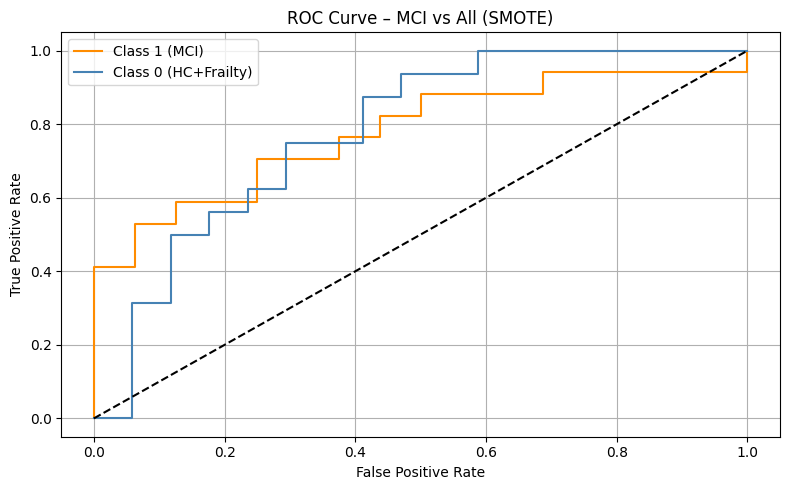

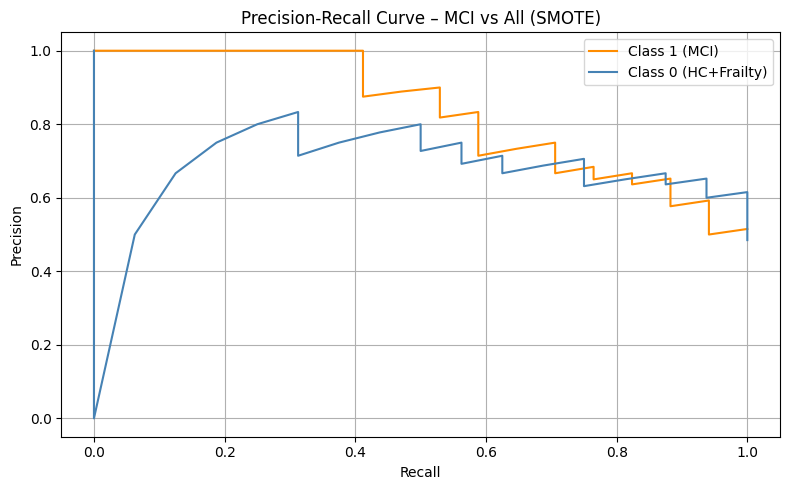

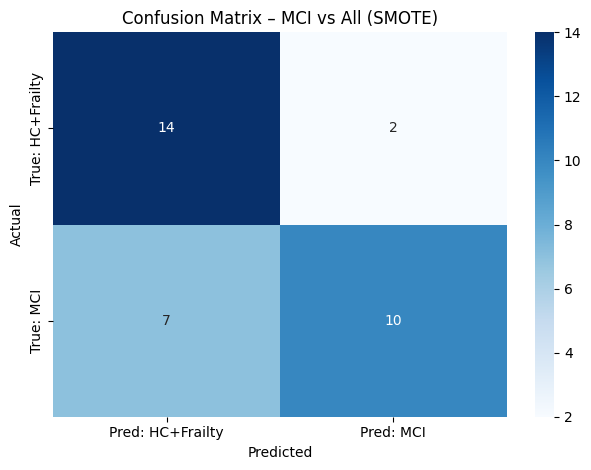

Selected non-zero coefficients
           Feature  Coefficient
5        Fluency S    -1.359014
6        Fluency A    -1.145053
2              FAB    -0.990334
3          MFPT-UD    -0.622073
11  PIT (elements)    -0.349811
1          TMT-B-A    -0.114756
8      STROOP-STIR     0.111057
4          MFPT-CS    -0.056739


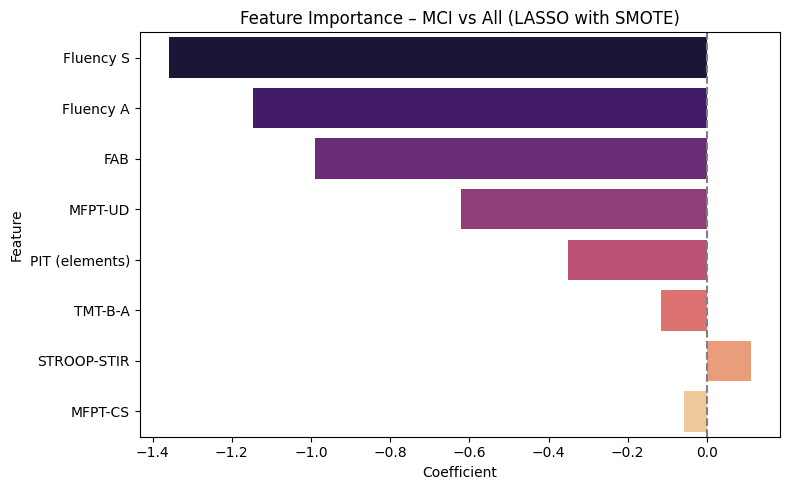

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.725 ± 0.080 | 95% CI [0.576, 0.879]
PRECISION: 0.827 ± 0.113 | 95% CI [0.583, 1.000]
RECALL: 0.589 ± 0.125 | 95% CI [0.333, 0.824]
SPECIFICITY: 0.868 ± 0.089 | 95% CI [0.684, 1.000]
F1: 0.680 ± 0.105 | 95% CI [0.455, 0.867]
ROC_AUC: 0.777 ± 0.085 | 95% CI [0.594, 0.930]
TRAPEZOIDAL_PR_AUC: 0.827 ± 0.079 | 95% CI [0.639, 0.951]


In [52]:
#MCI vs All (SMOTE)
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Test set evaluation
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

# Training set evaluation
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (SMOTE)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "Trapezoidal PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (SMOTE)")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


For MCI vs All, model and resampling selection is based exclusively on training cross\-validation in best\_models\_df\. The held\-out test metrics below are descriptive and are not used to choose the configuration\.

### Performance full model vs no PIT model for MCI vs all

Original held-out test point estimates – MCI vs All (ROS)


,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,Trapezoidal PR-AUC
With PIT,0.727,0.833,0.588,0.875,0.690,0.794,0.832
Without PIT,0.697,0.733,0.647,0.750,0.688,0.787,0.830


Paired stratified bootstrap delta – same test subjects


,Metric,Delta point estimate (Full - No-PIT),95% CI lower,95% CI upper
0,Accuracy,0.030,-0.061,0.121
1,F1,0.002,-0.108,0.094
2,ROC-AUC,0.007,-0.062,0.077
3,Trapezoidal PR-AUC,0.001,-0.059,0.059


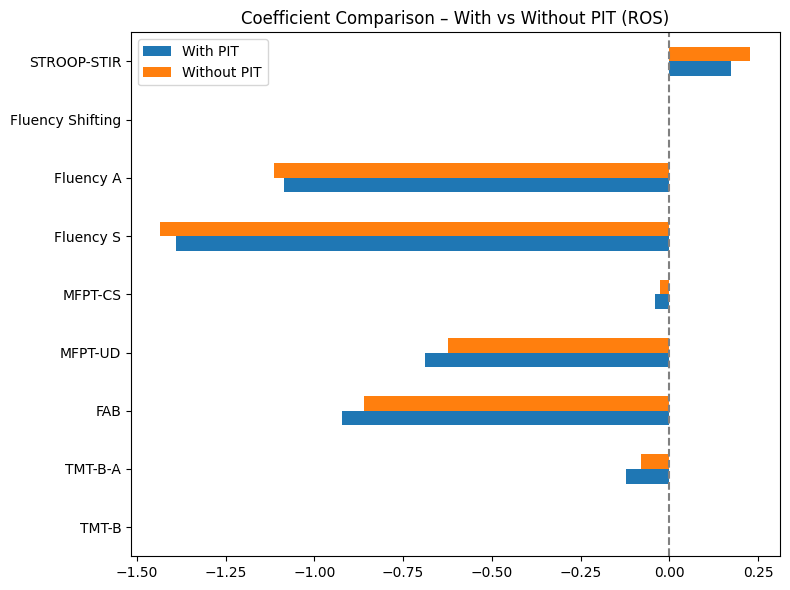

In [53]:
# Full vs No-PIT comparison for MCI vs All using the same split and ROS strategy
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
full_features = features_full.copy()
nopit_features = [f for f in full_features if f not in pit_features]
X_full = df_n[full_features].apply(pd.to_numeric, errors='coerce')
X_nopit = X_full[nopit_features]
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_full, y, stratify=y, test_size=0.3, random_state=42
)
X_train_np = X_nopit.loc[X_train_f.index]
X_test_np = X_nopit.loc[X_test_f.index]

model_full = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42), full_features
)
model_nopit = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42), nopit_features
)
model_full.fit(X_train_f, y_train)
model_nopit.fit(X_train_np, y_train)

y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]
y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

def comparison_metrics(y_true, y_pred, y_proba):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true,
        y_proba
    )

    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Trapezoidal PR-AUC': pr_auc
    }

def paired_stratified_delta_ci(y_true, pred_full, proba_full, pred_reduced, proba_reduced, n_iter=1000, random_state=42):
    y_arr = np.asarray(y_true)
    pred_full = np.asarray(pred_full)
    proba_full = np.asarray(proba_full)
    pred_reduced = np.asarray(pred_reduced)
    proba_reduced = np.asarray(proba_reduced)
    rng = np.random.RandomState(random_state)
    class_indices = [np.flatnonzero(y_arr == cls) for cls in np.unique(y_arr)]
    deltas = {k: [] for k in ['Accuracy', 'F1', 'ROC-AUC', 'Trapezoidal PR-AUC']}
    for _ in range(n_iter):
        idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices])
        full_m = comparison_metrics(y_arr[idx], pred_full[idx], proba_full[idx])
        reduced_m = comparison_metrics(y_arr[idx], pred_reduced[idx], proba_reduced[idx])
        for metric in deltas:
            deltas[metric].append(full_m[metric] - reduced_m[metric])
    point_full = comparison_metrics(y_arr, pred_full, proba_full)
    point_reduced = comparison_metrics(y_arr, pred_reduced, proba_reduced)
    rows = []
    for metric, values in deltas.items():
        rows.append({
            'Metric': metric,
            'Delta point estimate (Full - No-PIT)': point_full[metric] - point_reduced[metric],
            '95% CI lower': np.percentile(values, 2.5),
            '95% CI upper': np.percentile(values, 97.5)
        })
    return pd.DataFrame(rows)

results = pd.DataFrame({
    'With PIT': comparison_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': comparison_metrics(y_test, y_pred_np, y_proba_np)
}).T
print('Original held-out test point estimates – MCI vs All (ROS)')
display(results.round(3))
delta_results_mcia = paired_stratified_delta_ci(
    y_test, y_pred_f, y_proba_f, y_pred_np, y_proba_np
)
print('Paired stratified bootstrap delta – same test subjects')
display(delta_results_mcia.round(3))

coef_f = pd.Series(model_full.named_steps['classifier'].coef_[0], index=full_features)
coef_np = pd.Series(model_nopit.named_steps['classifier'].coef_[0], index=nopit_features)
pd.DataFrame({'With PIT': coef_f[nopit_features], 'Without PIT': coef_np}).plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title('Coefficient Comparison – With vs Without PIT (ROS)')
plt.tight_layout()
plt.show()

### Permutation importance for model: MCI vs all

In [54]:
df_task = df_n.copy()
feature_names = features_full.copy()
X = df_task[feature_names].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'MCI' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

model_full = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42), feature_names
)
model_full.fit(X_train, y_train)

# Post-hoc permutation importance on the held-out test; it is not used to refit the model
perm_result = permutation_importance(
    estimator=model_full, X=X_test, y=y_test, n_repeats=30,
    random_state=42, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * 0.05
print('\nPermutation Importance (held-out ROC-AUC, MCI vs All (ROS)):')
print(perm_df_filtered)
fig = px.bar(
    perm_df_filtered, x='Importance', y='Feature',
    title='Permutation Importance – MCI vs All (ROS)',
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std', color='Importance', color_continuous_scale='Viridis'
)
fig.update_layout(
    showlegend=False,
    xaxis_title='Mean decrease in ROC-AUC when feature is permuted',
    yaxis_title='Feature', yaxis=dict(showgrid=True, autorange='reversed'),
    plot_bgcolor='white'
)
fig.show()


Permutation Importance (held-out ROC-AUC, MCI vs All (ROS)):
           Feature  Importance       Std  Reduced_Std
0              FAB    0.107598  0.061993     0.003100
1        Fluency A    0.101961  0.052252     0.002613
2          MFPT-UD    0.031373  0.029818     0.001491
3      STROOP-STIR    0.025368  0.014747     0.000737
4   PIT (elements)    0.009681  0.021843     0.001092
5          TMT-B-A    0.009069  0.013975     0.000699
6          MFPT-CS    0.006985  0.002743     0.000137
11       Fluency S   -0.037010  0.038815     0.001941


### \+MCI vs All \(with semantic metrics\)

Merged N: 109
Counts by final clinical group:
group
MCI        57
HC         32
Frailty    20
Name: count, dtype: int64
Unique IDs: 109
NPS IDs absent from semantic source: []
Stratified training cross-validation (5 folds):
ACCURACY: 0.778 ± 0.062
PRECISION: 0.849 ± 0.131
RECALL: 0.750 ± 0.177
F1: 0.771 ± 0.080
ROC_AUC: 0.929 ± 0.048
Average Precision: 0.952 ± 0.030
Held-out test metrics – MCI vs All
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.86      0.71      0.77        17

    accuracy                           0.79        33
   macro avg       0.80      0.79      0.79        33
weighted avg       0.80      0.79      0.79        33

{'Accuracy': 0.788, 'Precision': 0.857, 'Recall': 0.706, 'Specificity': 0.875, 'F1': 0.774, 'ROC-AUC': 0.794, 'Trapezoidal PR-AUC': 0.851}
Non-zero Coefficients (LASSO):
               Feature  Coefficient
5            Fluency S    -1.353746
6            Fluency A    -

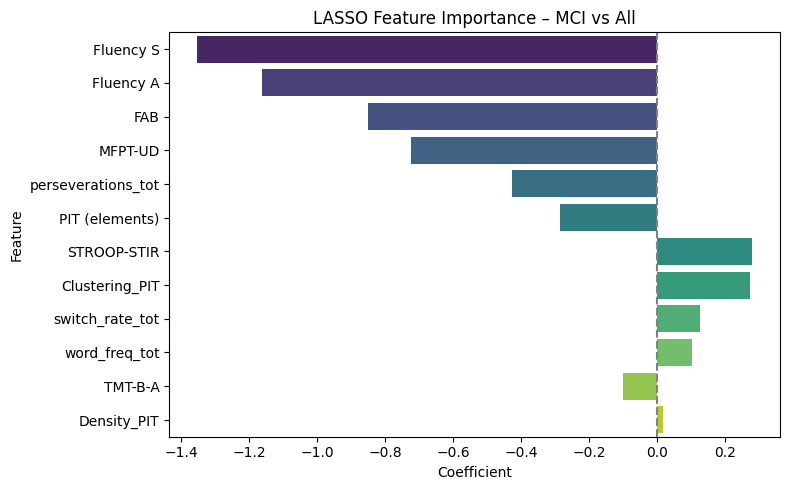

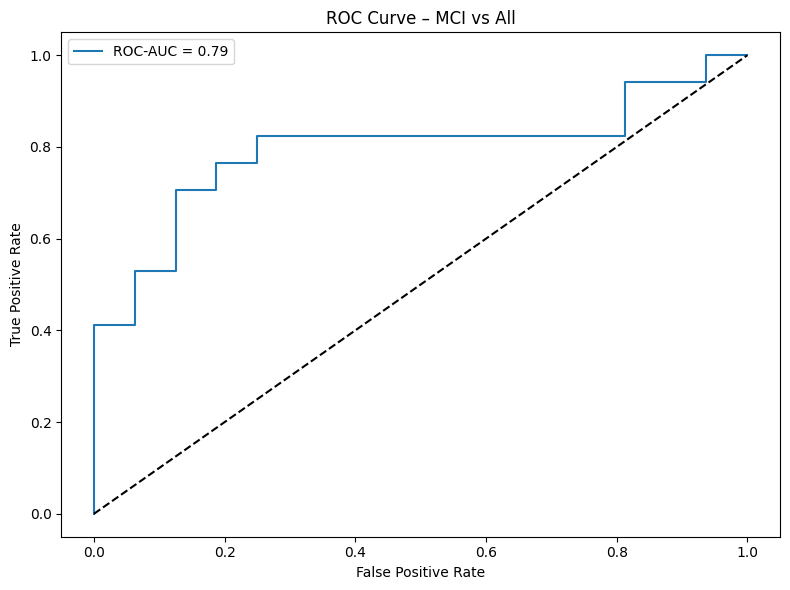

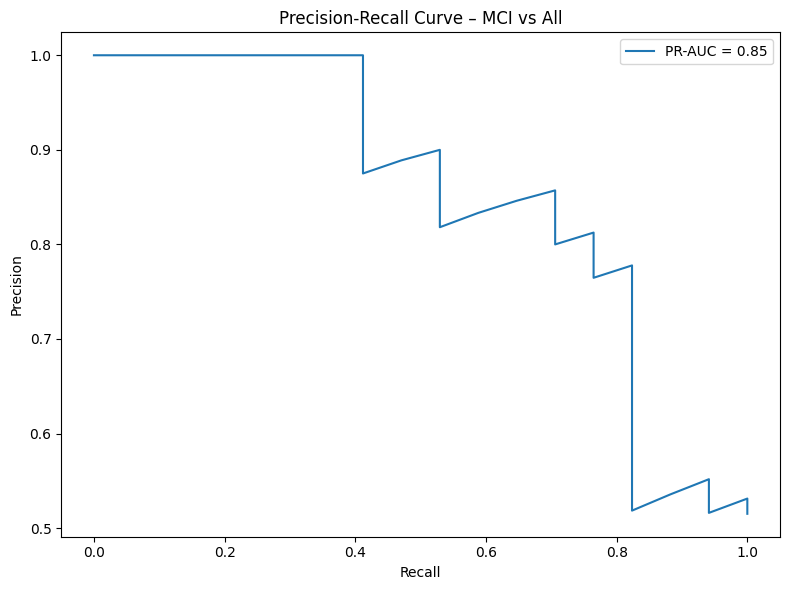

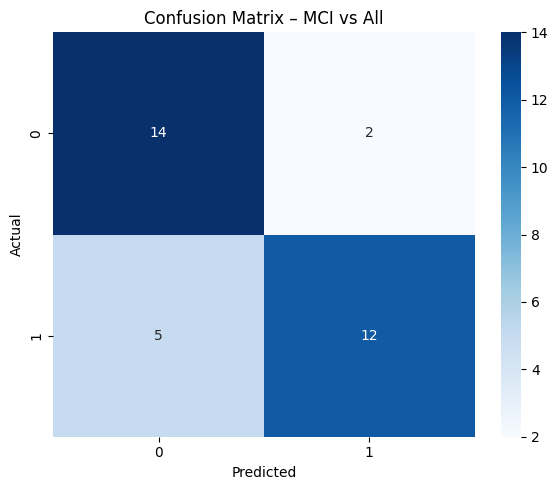

Stratified bootstrap test metrics (mean ± SD) [95% CI]:
Accuracy: 0.790 ± 0.070 | 95% CI [0.636, 0.909]
Precision: 0.865 ± 0.083 | 95% CI [0.692, 1.000]
Recall: 0.707 ± 0.115 | 95% CI [0.471, 0.882]
Specificity: 0.878 ± 0.083 | 95% CI [0.688, 1.000]
F1: 0.772 ± 0.085 | 95% CI [0.600, 0.909]
ROC-AUC: 0.797 ± 0.086 | 95% CI [0.610, 0.941]
Trapezoidal PR-AUC: 0.854 ± 0.063 | 95% CI [0.715, 0.958]


In [55]:
# Merge semantic data by subject ID; clinical group in df_n is the source of truth
df_semantic_source = pd.read_csv('df_merged (semantic+nps).csv')
if df_semantic_source['id'].duplicated().any():
    raise ValueError('Semantic source contains duplicate subject IDs.')
semantic_features = [
    'switch_rate_tot', 'cluster_switches_tot', 'cluster_size_tot',
    'perseverations_tot', 'intrusions_tot', 'word_freq_tot', 'aoa_tot',
    'NumNodes_PIT', 'NumArches_PIT', 'Clustering_PIT', 'Density_PIT', 'Entropy_PIT'
]
missing_columns = [c for c in semantic_features if c not in df_semantic_source.columns]
if missing_columns:
    raise KeyError(f'Missing semantic columns: {missing_columns}')
missing_semantic_ids = df_n.loc[~df_n['id'].isin(df_semantic_source['id']), 'id'].tolist()
df = df_n.merge(
    df_semantic_source[['id'] + semantic_features], on='id', how='left', validate='one_to_one'
)
print('Merged N:', len(df))
print('Counts by final clinical group:')
print(df['group'].value_counts(dropna=False))
print('Unique IDs:', df['id'].nunique())
print('NPS IDs absent from semantic source:', missing_semantic_ids)
selected_features = features_full + semantic_features

df_task = df.copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'MCI' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

lasso_pipeline = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42), selected_features
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(
    lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring,
    n_jobs=-1, return_train_score=False
)
print('Stratified training cross-validation (5 folds):')
for metric in scoring:
    values = cv_results[f'test_{metric}']
    label = 'Average Precision' if metric == 'average_precision' else metric.upper()
    print(f'{label}: {values.mean():.3f} ± {values.std():.3f}')

lasso_pipeline.fit(X_train, y_train)
y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

pr_auc_test = auc(
    recall_vals,
    precision_vals
)

metrics_semantic = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Trapezoidal PR-AUC': pr_auc_test
}
print('Held-out test metrics – MCI vs All')
print(classification_report(y_test, y_pred, zero_division=0))
print({k: round(v, 3) for k, v in metrics_semantic.items()})

classifier = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': classifier.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False)
print('Non-zero Coefficients (LASSO):')
print(coef_df[['Feature', 'Coefficient']])
feature_subset_mcia = (
    coef_df
    .head(11)['Feature']
    .tolist()
)

coef_series_mcia = pd.Series(
    coef_df['Coefficient'].values,
    index=coef_df['Feature'].values
)

print(
    'Saved TOP feature_subset_mcia:',
    len(feature_subset_mcia),
    feature_subset_mcia
)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Feature Importance – MCI vs All')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – MCI vs All')
plt.legend()
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'PR-AUC = {pr_auc_test:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – MCI vs All')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – MCI vs All')
plt.tight_layout()
plt.show()

# Stratified bootstrap of the held-out test
rng = np.random.RandomState(42)
y_arr = y_test.to_numpy()
class_indices = [np.flatnonzero(y_arr == cls) for cls in np.unique(y_arr)]
boot_metrics = {k: [] for k in metrics_semantic}
for _ in range(1000):
    idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices])
    current = comparison_metrics(y_arr[idx], y_pred[idx], y_proba[idx])
    for key in boot_metrics:
        boot_metrics[key].append(current[key])
print('Stratified bootstrap test metrics (mean ± SD) [95% CI]:')
for metric, values in boot_metrics.items():
    values = np.asarray(values)
    print(f'{metric}: {values.mean():.3f} ± {values.std():.3f} | 95% CI [{np.percentile(values, 2.5):.3f}, {np.percentile(values, 97.5):.3f}]')

### SHAP: MCI vs All

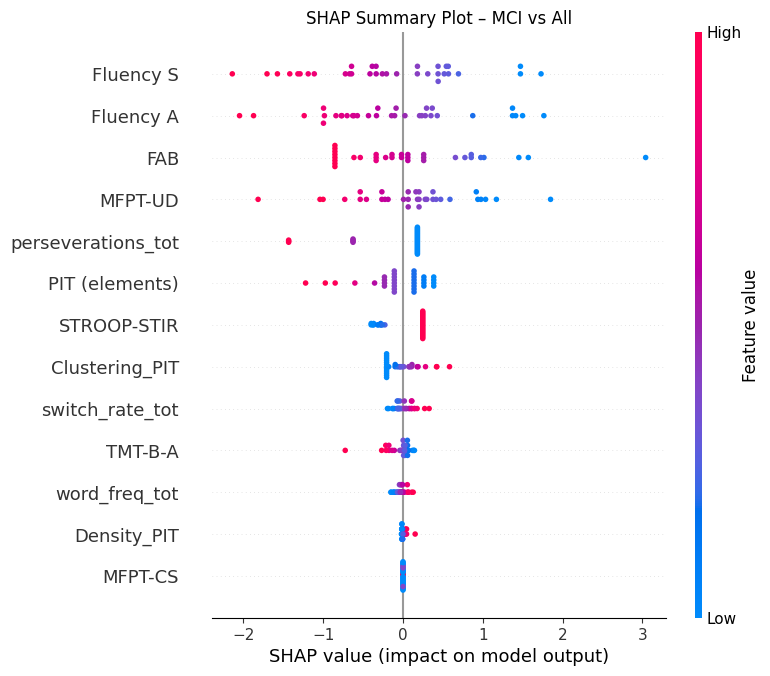

In [56]:
selected_features = features_full + semantic_features
df_task = df.copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'MCI' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Fit preprocessing and resampling on training data only
shap_pipeline = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42), selected_features
)
shap_pipeline.fit(X_train, y_train)
fitted_preprocessor = shap_pipeline.named_steps['preprocessing']
model = shap_pipeline.named_steps['classifier']
X_train_scaled = fitted_preprocessor.transform(X_train)
X_test_scaled = fitted_preprocessor.transform(X_test)

# SHAP uses the model fitted on training and transforms the test without refitting
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, max_display=13, show=False)
plt.title('SHAP Summary Plot – MCI vs All')
plt.show()

y_proba = shap_pipeline.predict_proba(X_test)[:, 1]
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}
binary_model_outputs['MCI vs All'] = {
    'comparison_name': 'MCI vs All',
    'positive_group': 'MCI',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'preprocessor': fitted_preprocessor,
    'pipeline': shap_pipeline,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}

## \+FF vs HC

Cross-Validation Results (5-fold):
Accuracy: 0.554 ± 0.192
F1-score: 0.411 ± 0.269
ROC-AUC:  0.590 ± 0.260
Average Precision: 0.588 ± 0.228
Training set metrics
              precision    recall  f1-score   support

           0       0.94      0.77      0.85        22
           1       0.72      0.93      0.81        14

    accuracy                           0.83        36
   macro avg       0.83      0.85      0.83        36
weighted avg       0.86      0.83      0.84        36

Accuracy: 0.833
Precision: 0.722
Recall (Sensitivity): 0.929
Specificity: 0.773
F1-score: 0.812
ROC-AUC: 0.886
Trapezoidal PR-AUC: 0.728
HC vs Frailty – Full model
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.43      0.50      0.46         6

    accuracy                           0.56        16
   macro avg       0.55      0.55      0.55        16
weighted avg       0.58      0.56      0.57        16

Accuracy: 0.562
Preci

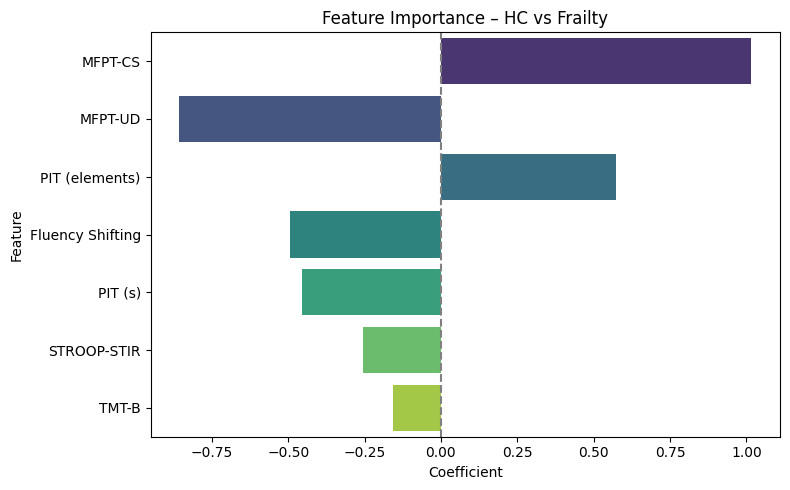

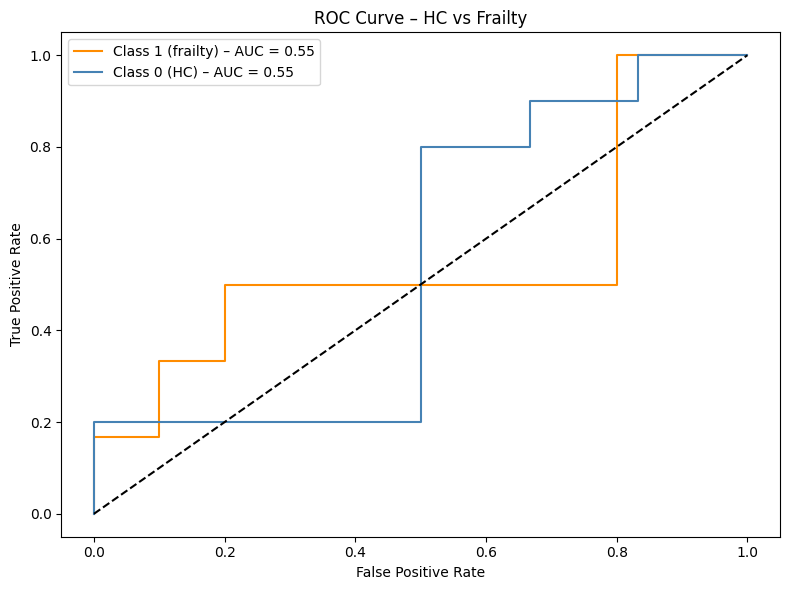

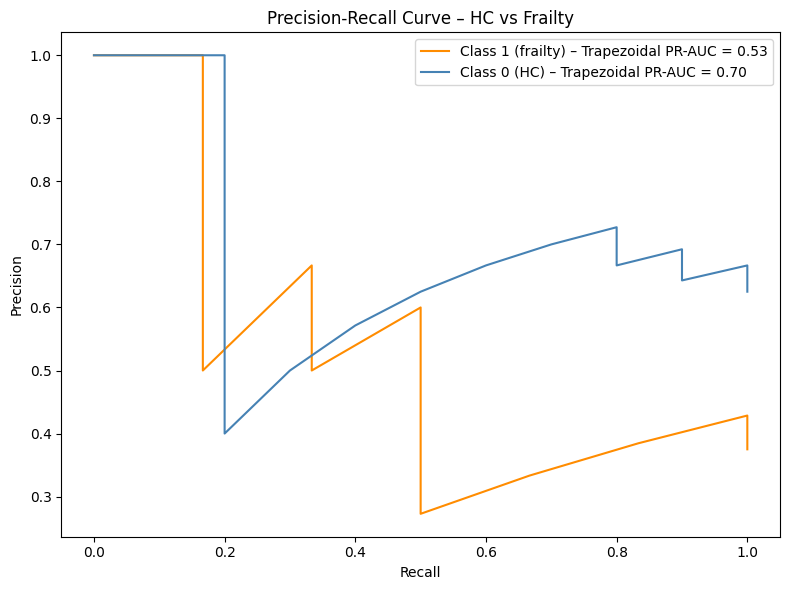

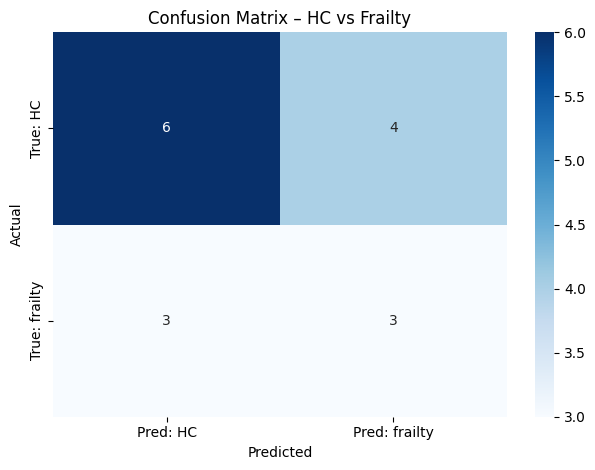


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.563 ± 0.123 | 95% CI [0.312, 0.812]
PRECISION: 0.430 ± 0.199 | 95% CI [0.000, 0.833]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.604 ± 0.157 | 95% CI [0.300, 0.900]
F1: 0.439 ± 0.177 | 95% CI [0.000, 0.737]
ROC_AUC: 0.550 ± 0.183 | 95% CI [0.214, 0.923]
TRAPEZOIDAL_PR_AUC: 0.541 ± 0.201 | 95% CI [0.142, 0.892]


In [57]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter only HC and Frailty subjects
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

X = df_hc_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR'] + pit_features]

# Target: 1 = Frailty, 0 = HC
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# LASSO Logistic Regression fitted on the training set only
model = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Predictions on training set
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

# Metrics on training set
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
print("HC vs Frailty – Full model")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall (Sensitivity): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
print(f"Trapezoidal PR-AUC: {auc(recall_vals, precision_vals):.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs', ascending=False)

print("\nSelected coefficients:")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – HC vs Frailty")
plt.tight_layout()
plt.show()

# ROC and PR curves for class 0 and 1
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


# PR curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (frailty) – Trapezoidal PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (HC) – Trapezoidal PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: frailty"],
            yticklabels=["True: HC", "True: frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

#Bootstrapping (1000 iterations) 
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class present
    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## FF vs HC  \(with Random Oversampling\)

Cross-Validation Results (5-fold):
Accuracy: 0.607 ± 0.172
F1-score: 0.441 ± 0.267
ROC-AUC:  0.617 ± 0.292
Average Precision: 0.627 ± 0.274
Training set metrics
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        22
           1       0.76      0.93      0.84        14

    accuracy                           0.86        36
   macro avg       0.86      0.87      0.86        36
weighted avg       0.88      0.86      0.86        36

Accuracy: 0.861
Precision: 0.765
Recall (Sensitivity): 0.929
Specificity: 0.818
F1-score: 0.839
ROC-AUC: 0.899
Trapezoidal PR-AUC: 0.761
Test set metrics
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.38      0.50      0.43         6

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.49        16
weighted avg       0.53      0.50      0.51        16

Accuracy: 0.500
Precision: 0.37

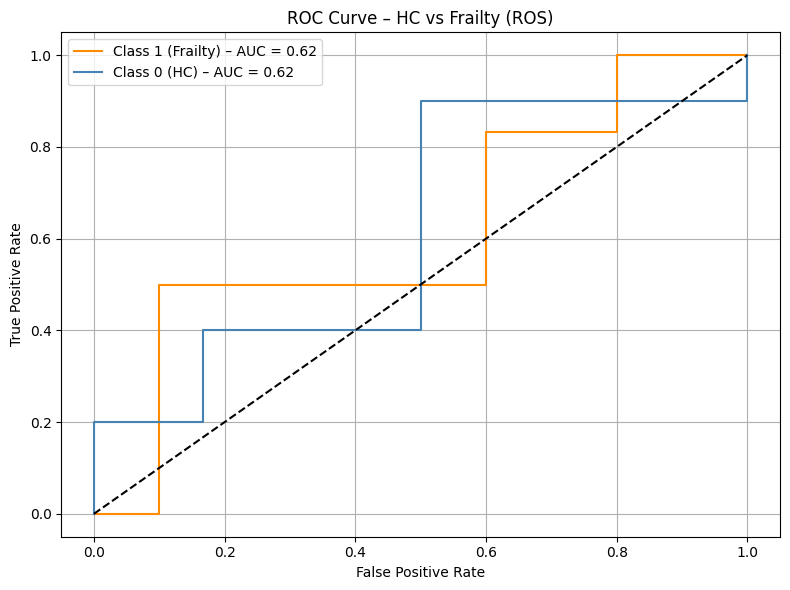

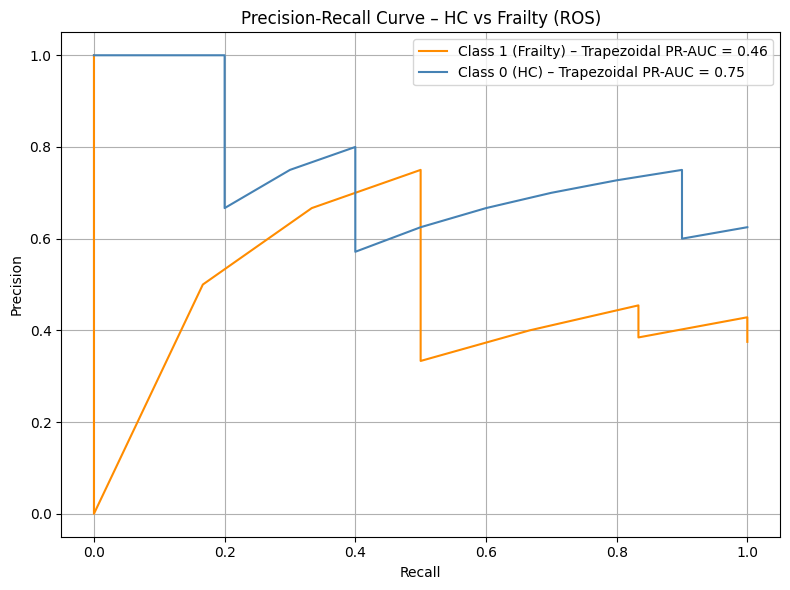

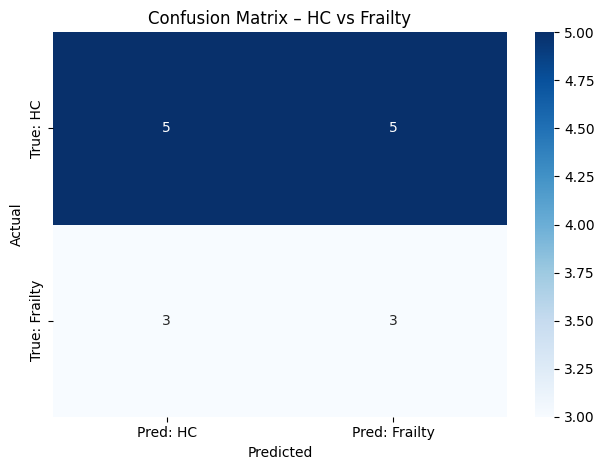

Selected non-zero coefficients
             Feature  Coefficient
4            MFPT-CS     1.109482
3            MFPT-UD    -1.069013
11    PIT (elements)     0.651898
9            PIT (s)    -0.503887
0              TMT-B    -0.371300
7   Fluency Shifting    -0.317685
8        STROOP-STIR    -0.219961


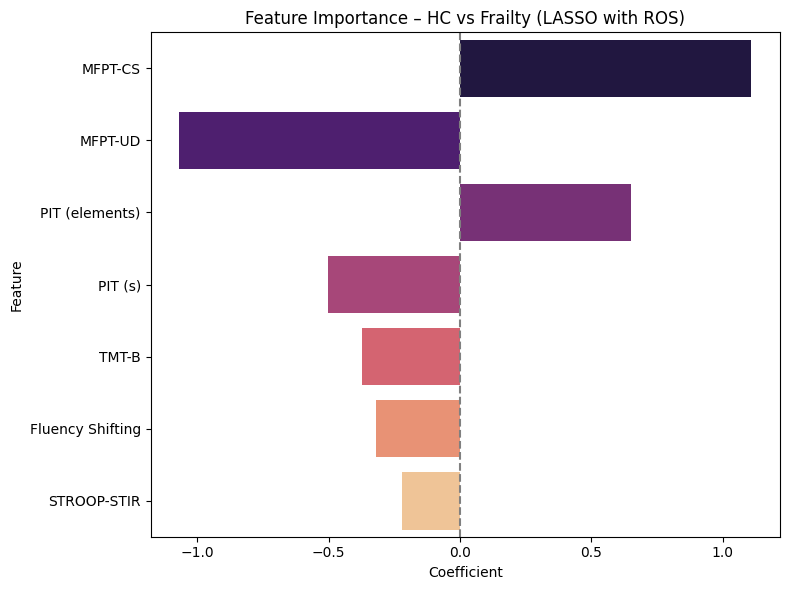

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.502 ± 0.121 | 95% CI [0.250, 0.750]
PRECISION: 0.377 ± 0.178 | 95% CI [0.000, 0.728]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.507 ± 0.160 | 95% CI [0.200, 0.833]
F1: 0.409 ± 0.168 | 95% CI [0.000, 0.700]
ROC_AUC: 0.621 ± 0.162 | 95% CI [0.312, 0.923]
TRAPEZOIDAL_PR_AUC: 0.513 ± 0.209 | 95% CI [0.162, 0.896]


In [58]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target: 1 = Frailty, 0 = HC
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    RandomOverSampler(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Random Oversampling on training set
# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomOverSampler(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

# Print metrics
print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Metrics dictionary for test set
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (ROS)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "Trapezoidal PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – Trapezoidal PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – Trapezoidal PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with ROS)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Frailty vs HC \(with SMOTE\)

Cross-Validation Results (5-fold):
Accuracy: 0.657 ± 0.232
F1-score: 0.552 ± 0.360
ROC-AUC:  0.617 ± 0.292
Average Precision: 0.627 ± 0.274
Training set metrics
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        22
           1       0.78      1.00      0.88        14

    accuracy                           0.89        36
   macro avg       0.89      0.91      0.89        36
weighted avg       0.91      0.89      0.89        36

Accuracy: 0.889
Precision: 0.778
Recall (Sensitivity): 1.000
Specificity: 0.818
F1-score: 0.875
ROC-AUC: 0.909
Trapezoidal PR-AUC: 0.760
Test set metrics
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.57      0.67      0.62         6

    accuracy                           0.69        16
   macro avg       0.67      0.68      0.68        16
weighted avg       0.70      0.69      0.69        16

Accuracy: 0.688
Precision: 0.57

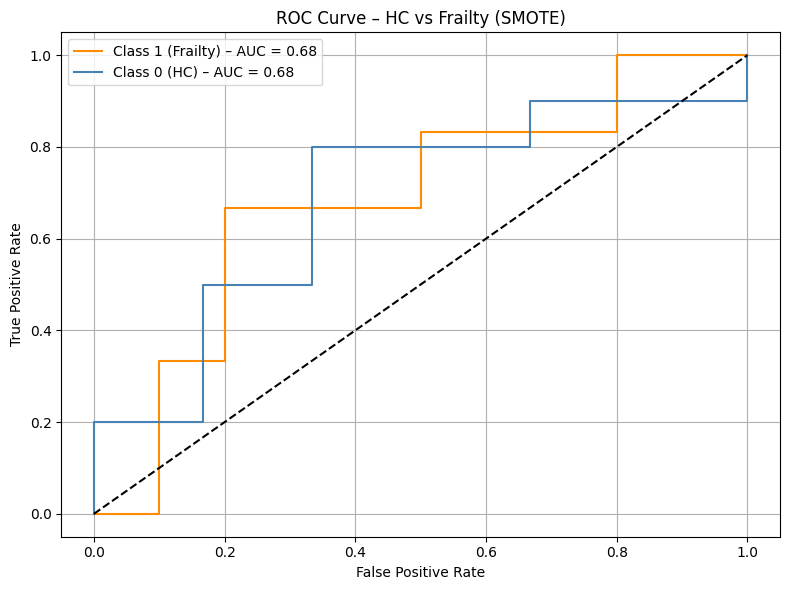

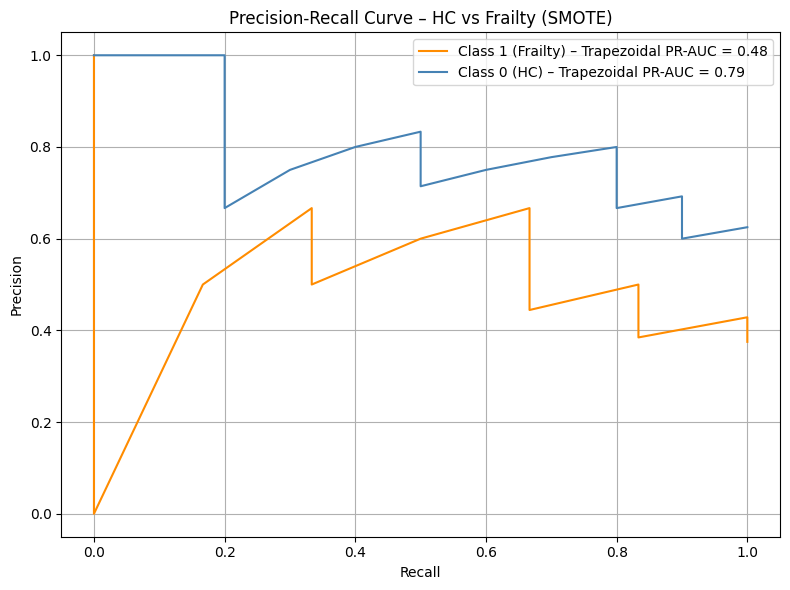

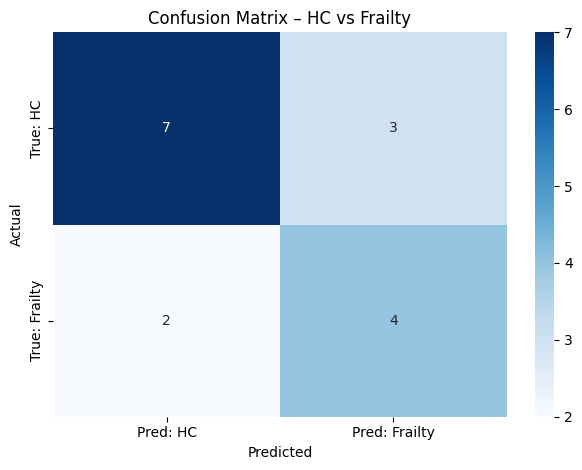

Selected non-zero coefficients
             Feature  Coefficient
4            MFPT-CS     1.068884
3            MFPT-UD    -0.997947
8        STROOP-STIR    -0.534160
9            PIT (s)    -0.524773
11    PIT (elements)     0.419547
7   Fluency Shifting    -0.374883
0              TMT-B    -0.299491


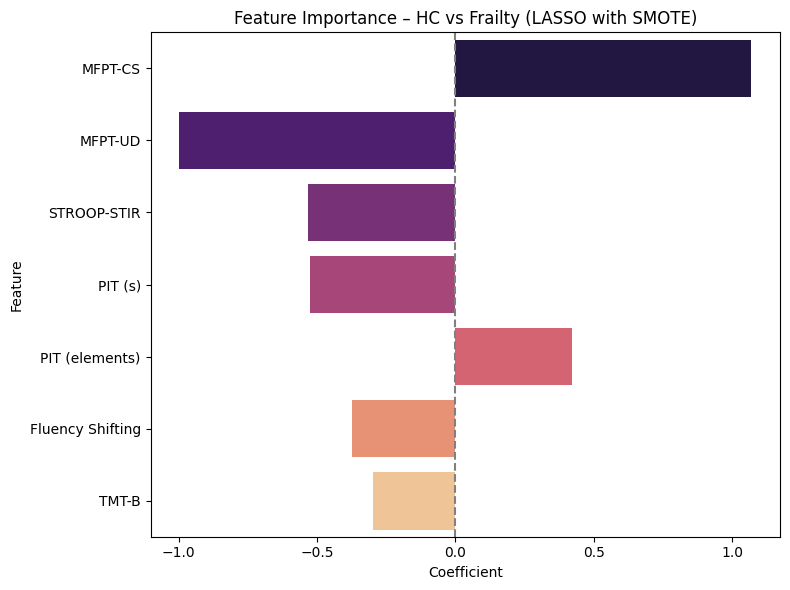

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.687 ± 0.118 | 95% CI [0.438, 0.875]
PRECISION: 0.571 ± 0.199 | 95% CI [0.167, 0.911]
RECALL: 0.665 ± 0.210 | 95% CI [0.250, 1.000]
SPECIFICITY: 0.700 ± 0.146 | 95% CI [0.400, 0.925]
F1: 0.595 ± 0.176 | 95% CI [0.200, 0.875]
ROC_AUC: 0.686 ± 0.152 | 95% CI [0.375, 0.958]
TRAPEZOIDAL_PR_AUC: 0.541 ± 0.214 | 95% CI [0.170, 0.944]


In [59]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Binary target: 1 = Frailty, 0 = HC
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Apply SMOTE on training set
# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")


print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Metrics dictionary (test)
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (SMOTE)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "Trapezoidal PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – Trapezoidal PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – Trapezoidal PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


For HC vs Frailty, model and resampling selection is based exclusively on training cross\-validation in best\_models\_df\. Held\-out test precision, recall, F1, ROC\-AUC, and Average Precision are reported only for final description\.

### Performance full model vs no PIT model for Frailty vs HC

Original held-out test point estimates – HC vs Frailty (No Resampling)


,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,Trapezoidal PR-AUC
With PIT,0.562,0.429,0.500,0.6,0.462,0.550,0.534
Without PIT,0.438,0.364,0.667,0.3,0.471,0.567,0.519


Paired stratified bootstrap delta – same test subjects


,Metric,Delta point estimate (Full - No-PIT),95% CI lower,95% CI upper
0,Accuracy,0.125,-0.062,0.312
1,F1,-0.009,-0.267,0.181
2,ROC-AUC,-0.017,-0.200,0.117
3,Trapezoidal PR-AUC,0.015,-0.068,0.231


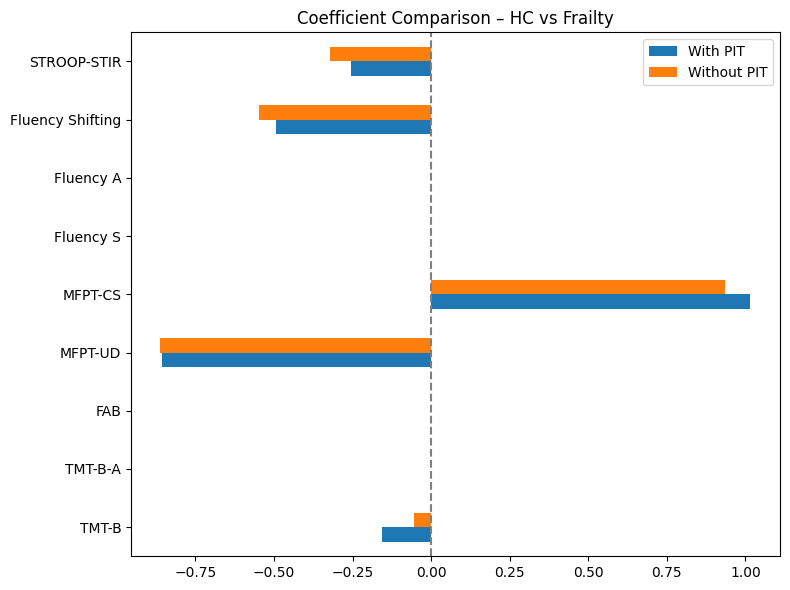

In [60]:
# Full vs No-PIT comparison for HC vs Frailty using the same split and no resampling
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()
full_features = features_full.copy()
nopit_features = [f for f in full_features if f not in pit_features]
X_full = df_hc_frailty[full_features].apply(pd.to_numeric, errors='coerce')
X_nopit = X_full[nopit_features]
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np = X_nopit.loc[X_train_f.index]
X_test_np = X_nopit.loc[X_test_f.index]

model_full = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42), full_features
)
model_nopit = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42), nopit_features
)
model_full.fit(X_train_f, y_train)
model_nopit.fit(X_train_np, y_train)
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]
y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

results = pd.DataFrame({
    'With PIT': comparison_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': comparison_metrics(y_test, y_pred_np, y_proba_np)
}).T
print('Original held-out test point estimates – HC vs Frailty (No Resampling)')
display(results.round(3))
delta_results_hcf = paired_stratified_delta_ci(
    y_test, y_pred_f, y_proba_f, y_pred_np, y_proba_np
)
print('Paired stratified bootstrap delta – same test subjects')
display(delta_results_hcf.round(3))

coef_f = pd.Series(model_full.named_steps['classifier'].coef_[0], index=full_features)
coef_np = pd.Series(model_nopit.named_steps['classifier'].coef_[0], index=nopit_features)
pd.DataFrame({'With PIT': coef_f[nopit_features], 'Without PIT': coef_np}).plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title('Coefficient Comparison – HC vs Frailty')
plt.tight_layout()
plt.show()

### Permutation importance for model: Frailty vs HC

In [61]:
df_task = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()
feature_names = features_full.copy()
X = df_task[feature_names].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

model_full = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42), feature_names
)
model_full.fit(X_train, y_train)

# Post-hoc permutation importance on the held-out test; it is not used to refit the model
perm_result = permutation_importance(
    estimator=model_full, X=X_test, y=y_test, n_repeats=30,
    random_state=42, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * 0.05
print('\nPermutation Importance (held-out ROC-AUC, HC vs Frailty):')
print(perm_df_filtered)
fig = px.bar(
    perm_df_filtered, x='Importance', y='Feature',
    title='Permutation Importance – HC vs Frailty',
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std', color='Importance', color_continuous_scale='Viridis'
)
fig.update_layout(
    showlegend=False,
    xaxis_title='Mean decrease in ROC-AUC when feature is permuted',
    yaxis_title='Feature', yaxis=dict(showgrid=True, autorange='reversed'),
    plot_bgcolor='white'
)
fig.show()


Permutation Importance (held-out ROC-AUC, HC vs Frailty):
             Feature  Importance       Std  Reduced_Std
5            PIT (s)   -0.013889  0.055791     0.002790
6              TMT-B   -0.015000  0.033980     0.001699
7        STROOP-STIR   -0.027222  0.036889     0.001844
8            MFPT-UD   -0.032222  0.124791     0.006240
9            MFPT-CS   -0.058889  0.051771     0.002589
10    PIT (elements)   -0.060556  0.076677     0.003834
11  Fluency Shifting   -0.110000  0.072852     0.003643


### \+FF vs HC \(with semantic metrics\)

Stratified training cross-validation (5 folds):
ACCURACY: 0.546 ± 0.215
PRECISION: 0.507 ± 0.417
RECALL: 0.367 ± 0.221
F1: 0.384 ± 0.263
ROC_AUC: 0.450 ± 0.270
Average Precision: 0.529 ± 0.223
Held-out test metrics – HC vs Frailty
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.38      0.50      0.43         6

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.49        16
weighted avg       0.53      0.50      0.51        16

{'Accuracy': 0.5, 'Precision': 0.375, 'Recall': 0.5, 'Specificity': 0.5, 'F1': 0.429, 'ROC-AUC': 0.617, 'Trapezoidal PR-AUC': 0.557}
Non-zero Coefficients (LASSO):
             Feature  Coefficient
4            MFPT-CS     1.081922
3            MFPT-UD    -0.809174
7   Fluency Shifting    -0.626973
11    PIT (elements)     0.467248
9            PIT (s)    -0.436339
18           aoa_tot    -0.380060
16    intrusions_tot    -0.240238
21    

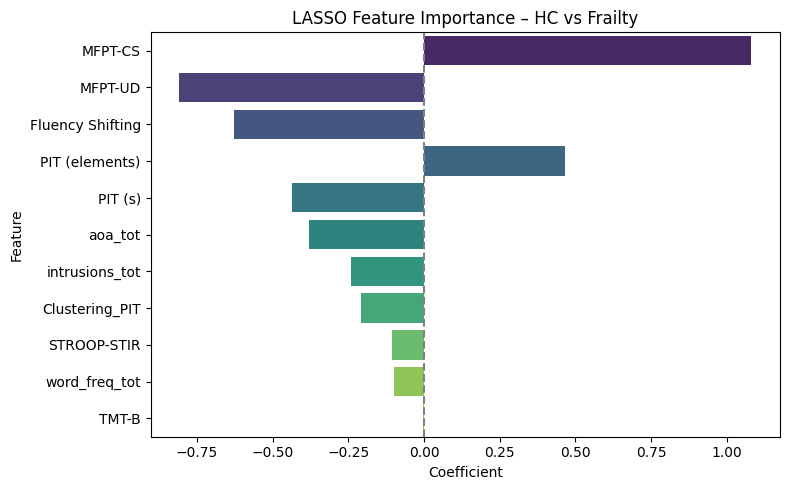

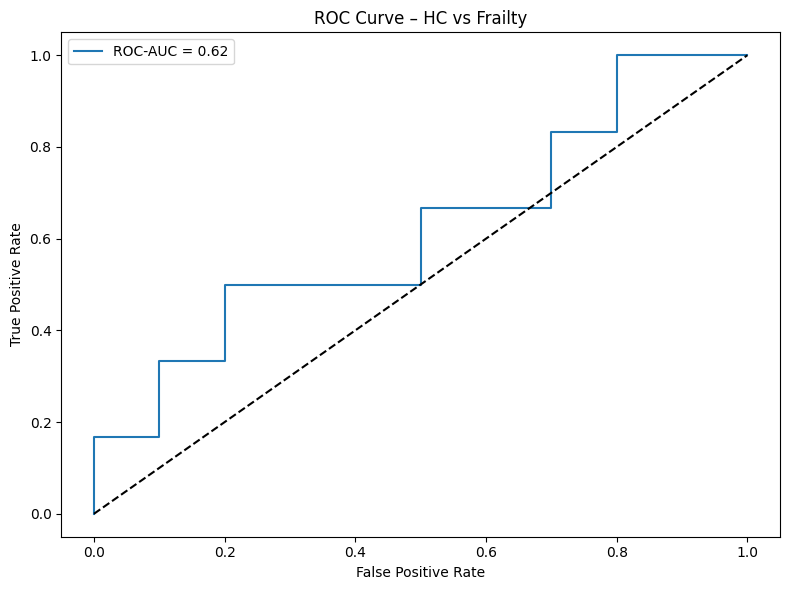

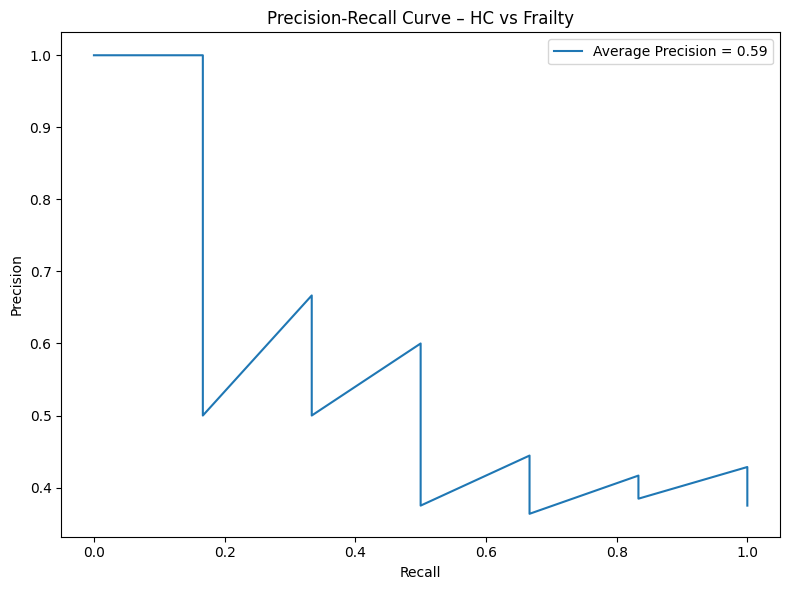

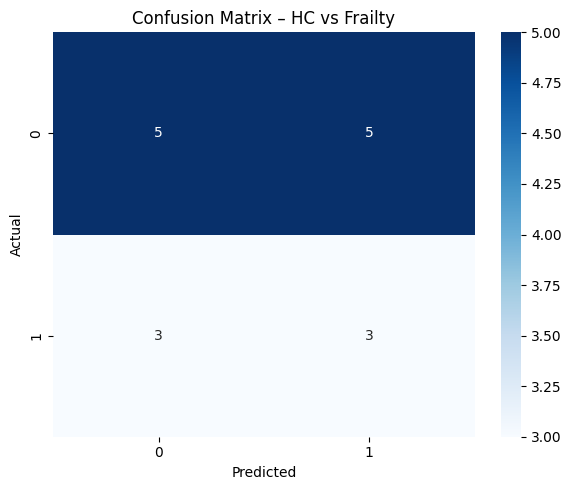

Stratified bootstrap test metrics (mean ± SD) [95% CI]:
Accuracy: 0.501 ± 0.124 | 95% CI [0.250, 0.750]
Precision: 0.374 ± 0.129 | 95% CI [0.125, 0.626]
Recall: 0.495 ± 0.199 | 95% CI [0.167, 0.833]
Specificity: 0.505 ± 0.153 | 95% CI [0.200, 0.800]
F1: 0.420 ± 0.148 | 95% CI [0.143, 0.714]
ROC-AUC: 0.610 ± 0.151 | 95% CI [0.300, 0.900]
Trapezoidal PR-AUC: 0.555 ± 0.164 | 95% CI [0.271, 0.901]


In [62]:
selected_features = features_full + semantic_features
df_task = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

lasso_pipeline = make_pipeline(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        C=1.0,
        random_state=42
    ),
    selected_features
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(
    lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring,
    n_jobs=-1, return_train_score=False
)
print('Stratified training cross-validation (5 folds):')
for metric in scoring:
    values = cv_results[f'test_{metric}']
    label = 'Average Precision' if metric == 'average_precision' else metric.upper()
    print(f'{label}: {values.mean():.3f} ± {values.std():.3f}')

lasso_pipeline.fit(X_train, y_train)
y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

metrics_semantic = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Trapezoidal PR-AUC': pr_auc
}
print('Held-out test metrics – HC vs Frailty')
print(classification_report(y_test, y_pred, zero_division=0))
print({k: round(v, 3) for k, v in metrics_semantic.items()})

classifier = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': classifier.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False)
print('Non-zero Coefficients (LASSO):')
print(coef_df[['Feature', 'Coefficient']])
feature_subset_fhc = (
    coef_df
    .head(11)['Feature']
    .tolist()
)

coef_series_fhc = pd.Series(
    coef_df['Coefficient'].values,
    index=coef_df['Feature'].values
)

print(
    'Saved TOP feature_subset_fhc:',
    len(feature_subset_fhc),
    feature_subset_fhc
)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Feature Importance – HC vs Frailty')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – HC vs Frailty')
plt.legend()
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'Average Precision = {average_precision_score(y_test, y_proba):.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – HC vs Frailty')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – HC vs Frailty')
plt.tight_layout()
plt.show()

# Stratified bootstrap of the held-out test
rng = np.random.RandomState(42)
y_arr = y_test.to_numpy()
class_indices = [np.flatnonzero(y_arr == cls) for cls in np.unique(y_arr)]
boot_metrics = {k: [] for k in metrics_semantic}
for _ in range(1000):
    idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices])
    current = comparison_metrics(y_arr[idx], y_pred[idx], y_proba[idx])
    for key in boot_metrics:
        boot_metrics[key].append(current[key])
print('Stratified bootstrap test metrics (mean ± SD) [95% CI]:')
for metric, values in boot_metrics.items():
    values = np.asarray(values)
    print(f'{metric}: {values.mean():.3f} ± {values.std():.3f} | 95% CI [{np.percentile(values, 2.5):.3f}, {np.percentile(values, 97.5):.3f}]')

### SHAP: HC vs Frailty

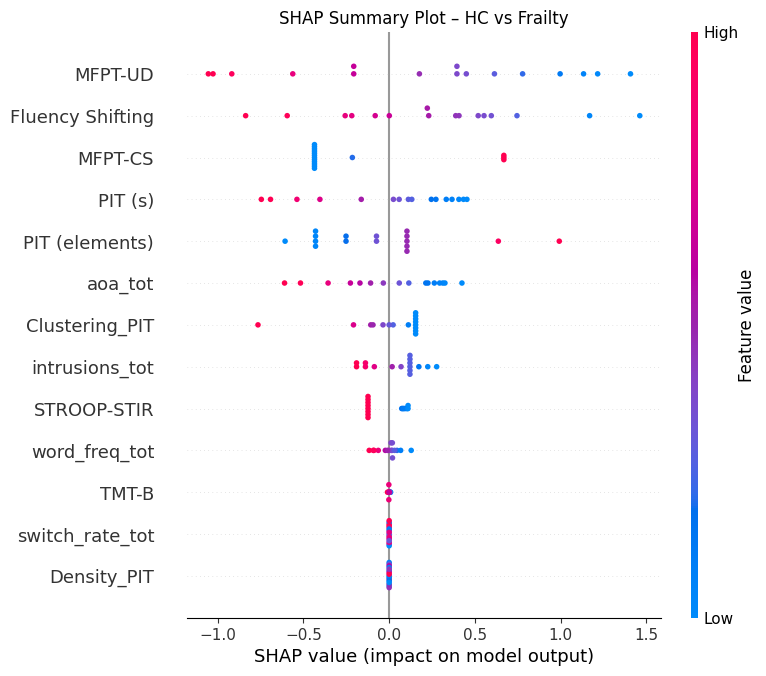

In [63]:
selected_features = features_full + semantic_features
df_task = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Fit preprocessing and resampling on training data only
shap_pipeline = make_pipeline(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=1.0,
        random_state=42
    ),
    selected_features
)
shap_pipeline.fit(X_train, y_train)
fitted_preprocessor = shap_pipeline.named_steps['preprocessing']
model = shap_pipeline.named_steps['classifier']
X_train_scaled = fitted_preprocessor.transform(X_train)
X_test_scaled = fitted_preprocessor.transform(X_test)

# SHAP uses the model fitted on training and transforms the test without refitting
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, max_display=13, show=False)
plt.title('SHAP Summary Plot – HC vs Frailty')
plt.show()

y_proba = shap_pipeline.predict_proba(X_test)[:, 1]
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}
binary_model_outputs['HC vs Frailty'] = {
    'comparison_name': 'HC vs Frailty',
    'positive_group': 'Frailty',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'preprocessor': fitted_preprocessor,
    'pipeline': shap_pipeline,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}

## FF vs MCI

Cross-Validation Results (5-fold):
Accuracy: 0.827 ± 0.078
F1-score: 0.706 ± 0.169
ROC-AUC:  0.848 ± 0.130
Average Precision: 0.712 ± 0.238
Training set metrics
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        39
           1       0.65      0.93      0.76        14

    accuracy                           0.85        53
   macro avg       0.81      0.87      0.83        53
weighted avg       0.89      0.85      0.86        53

Accuracy: 0.849
Precision: 0.650
Recall: 0.929
Specificity: 0.821
F1-score: 0.765
ROC-AUC: 0.956
Trapezoidal PR-AUC: 0.868
Test set metrics
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.50      0.50      0.50         6

    accuracy                           0.75        24
   macro avg       0.67      0.67      0.67        24
weighted avg       0.75      0.75      0.75        24

Accuracy: 0.750
Precision: 0.500
Recall: 0.50

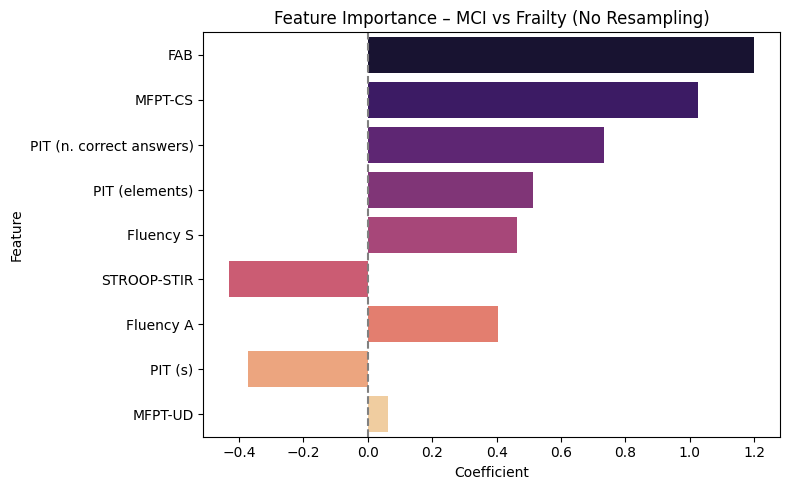

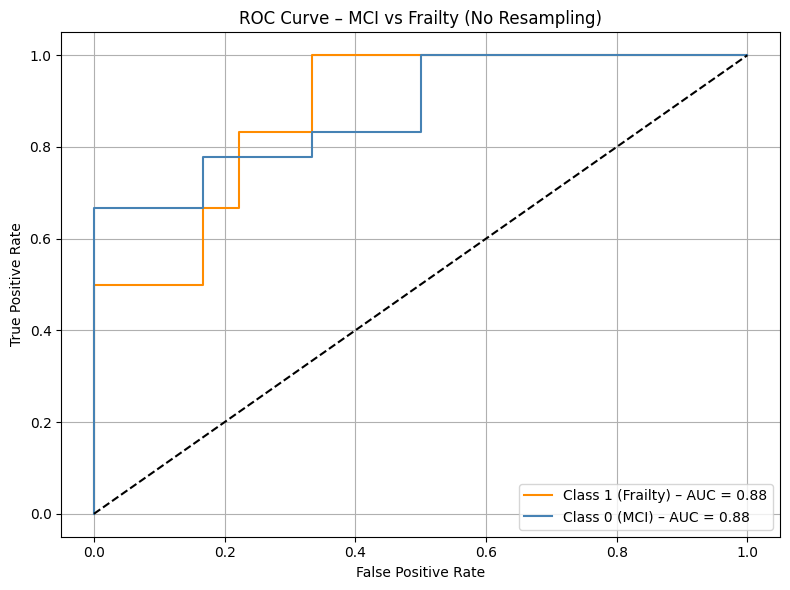

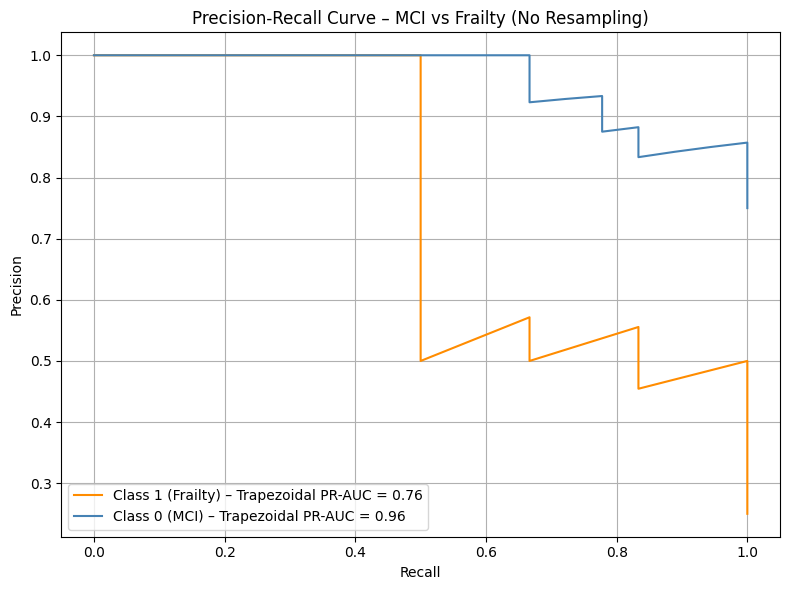

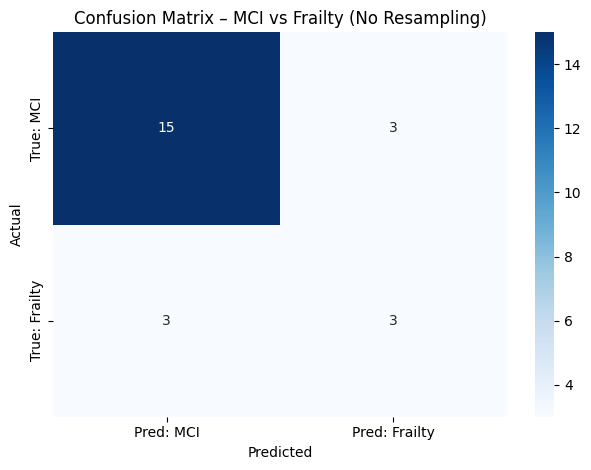

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.747 ± 0.089 | 95% CI [0.542, 0.917]
PRECISION: 0.499 ± 0.218 | 95% CI [0.000, 1.000]
RECALL: 0.498 ± 0.219 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.832 ± 0.086 | 95% CI [0.650, 1.000]
F1: 0.477 ± 0.186 | 95% CI [0.000, 0.800]
ROC_AUC: 0.879 ± 0.074 | 95% CI [0.706, 1.000]
TRAPEZOIDAL_PR_AUC: 0.748 ± 0.170 | 95% CI [0.242, 1.000]


In [64]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Final model fitted on the training set only
model = make_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Predictions test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Predictions train
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Metrics train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

# Metrics test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# ROC and PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty) – Trapezoidal PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI) – Trapezoidal PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## \+Frailty vs MCI \(with Random Undersampling\)

Cross-Validation Results (5-fold):
Accuracy: 0.680 ± 0.068
F1-score: 0.531 ± 0.096
ROC-AUC:  0.798 ± 0.107
Average Precision: 0.702 ± 0.199
Training set metrics – MCI vs Frailty (Undersampling)
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        39
           1       0.50      1.00      0.67        14

    accuracy                           0.74        53
   macro avg       0.75      0.82      0.72        53
weighted avg       0.87      0.74      0.75        53

Accuracy: 0.736
Precision: 0.500
Recall: 1.000
Specificity: 0.641
F1-score: 0.667
ROC-AUC: 0.881
Trapezoidal PR-AUC: 0.702
Test set metrics
              precision    recall  f1-score   support

           0       0.92      0.67      0.77        18
           1       0.45      0.83      0.59         6

    accuracy                           0.71        24
   macro avg       0.69      0.75      0.68        24
weighted avg       0.81      0.71      0.73        24

Accuracy: 0.

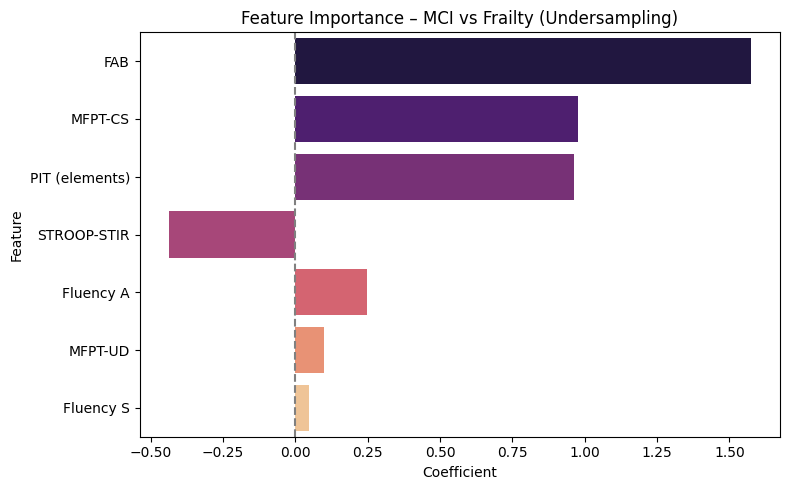

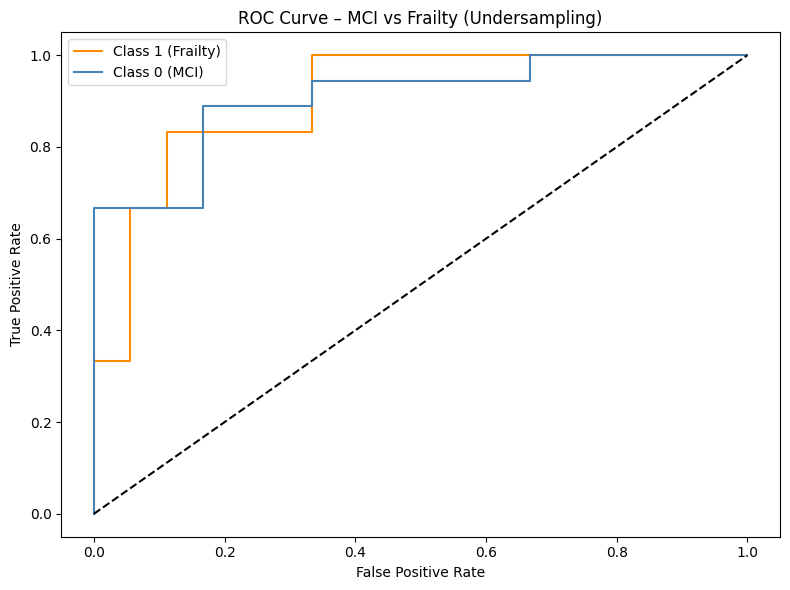

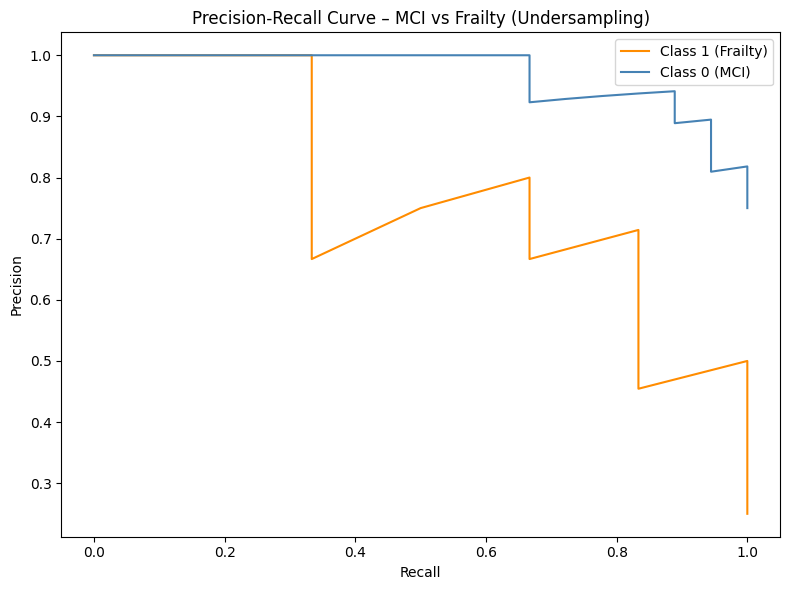

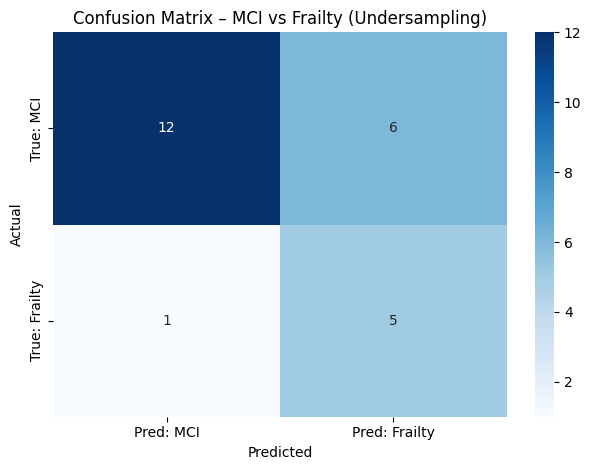

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.711 ± 0.090 | 95% CI [0.542, 0.875]
PRECISION: 0.460 ± 0.152 | 95% CI [0.166, 0.750]
RECALL: 0.828 ± 0.170 | 95% CI [0.426, 1.000]
SPECIFICITY: 0.671 ± 0.108 | 95% CI [0.444, 0.875]
F1: 0.576 ± 0.149 | 95% CI [0.250, 0.833]
ROC_AUC: 0.906 ± 0.068 | 95% CI [0.746, 1.000]
TRAPEZOIDAL_PR_AUC: 0.768 ± 0.179 | 95% CI [0.281, 1.000]


In [65]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    RandomUnderSampler(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Training metrics
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (Undersampling)")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Frailty vs MCI  \(with SMOTE\)

Cross-Validation Results (5-fold):
Accuracy: 0.773 ± 0.095
F1-score: 0.601 ± 0.202
ROC-AUC:  0.839 ± 0.134
Average Precision: 0.701 ± 0.246
Training set metrics – MCI vs Frailty (SMOTE)
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        39
           1       0.65      0.93      0.76        14

    accuracy                           0.85        53
   macro avg       0.81      0.87      0.83        53
weighted avg       0.89      0.85      0.86        53

Accuracy: 0.849
Precision: 0.650
Recall: 0.929
Specificity: 0.821
F1-score: 0.765
ROC-AUC: 0.951
Trapezoidal PR-AUC: 0.863
Test set metrics
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.50      0.50      0.50         6

    accuracy                           0.75        24
   macro avg       0.67      0.67      0.67        24
weighted avg       0.75      0.75      0.75        24

Accuracy: 0.750
Prec

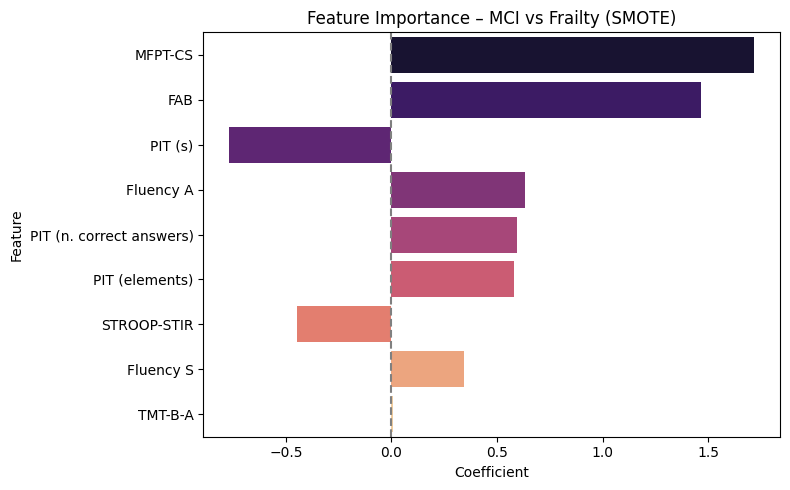

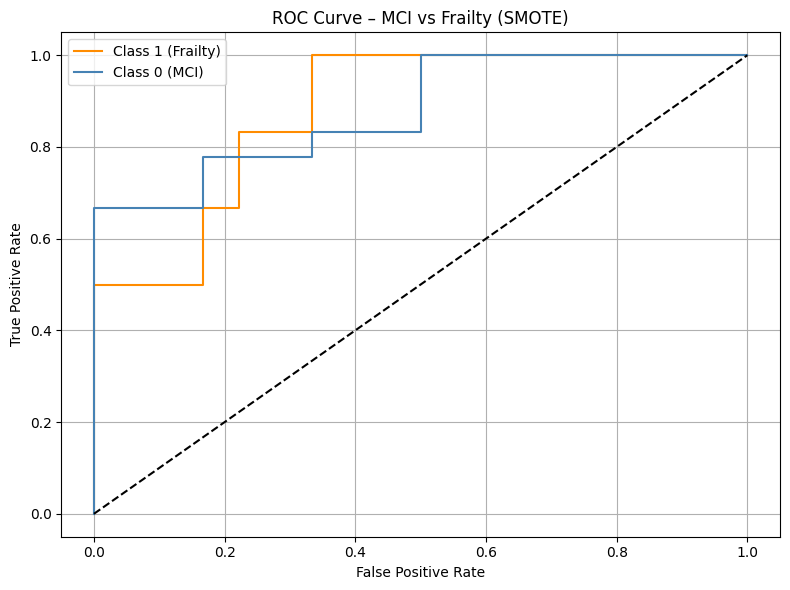

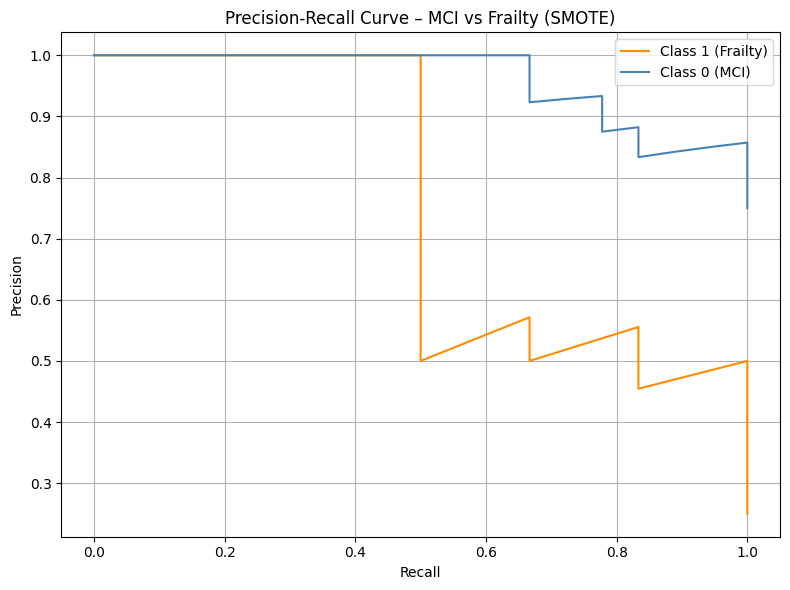

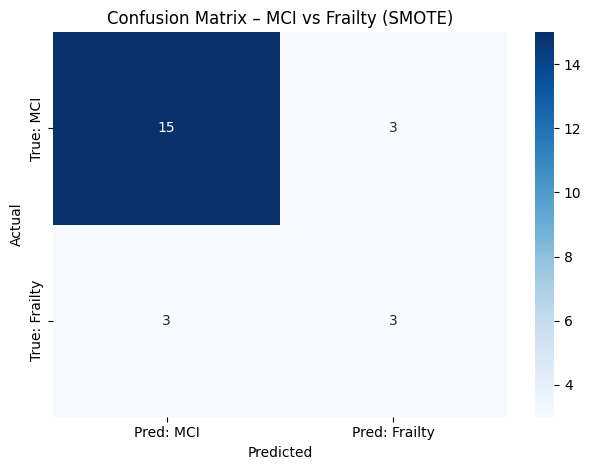

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.747 ± 0.090 | 95% CI [0.583, 0.917]
PRECISION: 0.501 ± 0.219 | 95% CI [0.000, 1.000]
RECALL: 0.498 ± 0.219 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.832 ± 0.088 | 95% CI [0.650, 1.000]
F1: 0.477 ± 0.186 | 95% CI [0.000, 0.800]
ROC_AUC: 0.879 ± 0.075 | 95% CI [0.705, 1.000]
TRAPEZOIDAL_PR_AUC: 0.748 ± 0.169 | 95% CI [0.259, 1.000]


In [66]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

pipeline = make_resampling_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"Average Precision: {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# SMOTE
# Leakage-free: preprocessing and resampling are fitted inside the training pipeline
model = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    SMOTE(random_state=42),
    features=X.columns.tolist()
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (SMOTE)")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Trapezoidal PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['classifier'].coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "trapezoidal_pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["trapezoidal_pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### Performance full model vs no PIT model for Frailty vs MCI

Original held-out test point estimates – MCI vs Frailty (RUS)


,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,Trapezoidal PR-AUC
With PIT,0.708,0.455,0.833,0.667,0.588,0.907,0.775
Without PIT,0.708,0.455,0.833,0.667,0.588,0.889,0.745


Paired stratified bootstrap delta – same test subjects


,Metric,Delta point estimate (Full - No-PIT),95% CI lower,95% CI upper
0,Accuracy,0.000,-0.167,0.167
1,F1,0.000,-0.149,0.140
2,ROC-AUC,0.019,-0.056,0.111
3,Trapezoidal PR-AUC,0.030,-0.211,0.298


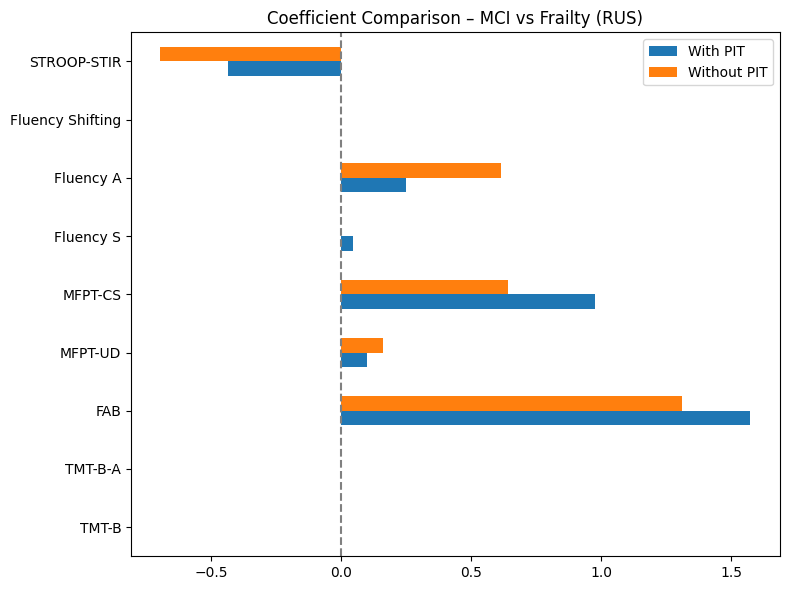

In [67]:
# Full vs No-PIT comparison for MCI vs Frailty using the same split and RUS strategy
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()
full_features = features_full.copy()
nopit_features = [f for f in full_features if f not in pit_features]
X_full = df_mci_frailty[full_features].apply(pd.to_numeric, errors='coerce')
X_nopit = X_full[nopit_features]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np = X_nopit.loc[X_train_f.index]
X_test_np = X_nopit.loc[X_test_f.index]

model_full = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42), full_features
)
model_nopit = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42), nopit_features
)
model_full.fit(X_train_f, y_train)
model_nopit.fit(X_train_np, y_train)
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]
y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

results = pd.DataFrame({
    'With PIT': comparison_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': comparison_metrics(y_test, y_pred_np, y_proba_np)
}).T
print('Original held-out test point estimates – MCI vs Frailty (RUS)')
display(results.round(3))
delta_results_mcf = paired_stratified_delta_ci(
    y_test, y_pred_f, y_proba_f, y_pred_np, y_proba_np
)
print('Paired stratified bootstrap delta – same test subjects')
display(delta_results_mcf.round(3))

coef_f = pd.Series(model_full.named_steps['classifier'].coef_[0], index=full_features)
coef_np = pd.Series(model_nopit.named_steps['classifier'].coef_[0], index=nopit_features)
pd.DataFrame({'With PIT': coef_f[nopit_features], 'Without PIT': coef_np}).plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title('Coefficient Comparison – MCI vs Frailty (RUS)')
plt.tight_layout()
plt.show()

### Permutation importance for model: Frailty vs MCI

In [68]:
df_task = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()
feature_names = features_full.copy()
X = df_task[feature_names].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

model_full = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42), feature_names
)
model_full.fit(X_train, y_train)

# Post-hoc permutation importance on the held-out test; it is not used to refit the model
perm_result = permutation_importance(
    estimator=model_full, X=X_test, y=y_test, n_repeats=30,
    random_state=42, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * 0.05
print('\nPermutation Importance (held-out ROC-AUC, MCI vs Frailty (RUS)):')
print(perm_df_filtered)
fig = px.bar(
    perm_df_filtered, x='Importance', y='Feature',
    title='Permutation Importance – MCI vs Frailty (RUS)',
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std', color='Importance', color_continuous_scale='Viridis'
)
fig.update_layout(
    showlegend=False,
    xaxis_title='Mean decrease in ROC-AUC when feature is permuted',
    yaxis_title='Feature', yaxis=dict(showgrid=True, autorange='reversed'),
    plot_bgcolor='white'
)
fig.show()


Permutation Importance (held-out ROC-AUC, MCI vs Frailty (RUS)):
           Feature  Importance       Std  Reduced_Std
0              FAB    0.282716  0.131484     0.006574
1   PIT (elements)    0.059877  0.046954     0.002348
2        Fluency A    0.030247  0.016724     0.000836
3        Fluency S    0.003086  0.004365     0.000218
10     STROOP-STIR   -0.002469  0.021772     0.001089
11         MFPT-CS   -0.012654  0.020213     0.001011


### \+ FF vs MCI \(with semantic metrics\)

Stratified training cross-validation (5 folds):
Held-out test metrics – MCI vs Frailty
              precision    recall  f1-score   support

           0       1.00      0.72      0.84        18
           1       0.55      1.00      0.71         6

    accuracy                           0.79        24
   macro avg       0.77      0.86      0.77        24
weighted avg       0.89      0.79      0.81        24

{'Accuracy': 0.792, 'Precision': 0.545, 'Recall': 1.0, 'Specificity': 0.722, 'F1': 0.706, 'ROC-AUC': 0.935, 'Trapezoidal PR-AUC': 0.837}
Non-zero Coefficients (LASSO):
                 Feature  Coefficient
2                    FAB     1.564579
8            STROOP-STIR    -0.690856
4                MFPT-CS     0.611879
22           Density_PIT    -0.566408
15    perseverations_tot     0.324002
6              Fluency A     0.317588
13  cluster_switches_tot     0.312409
11        PIT (elements)     0.160721
17         word_freq_tot    -0.133474
14      cluster_size_tot     0.114584


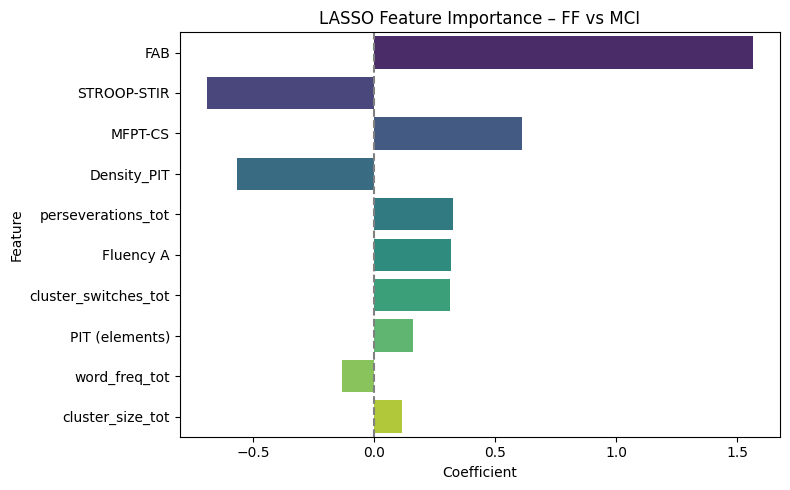

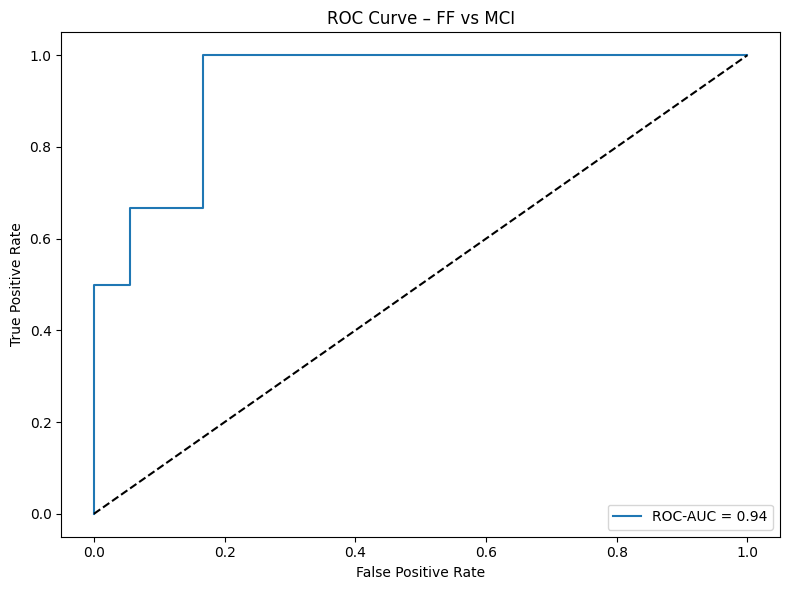

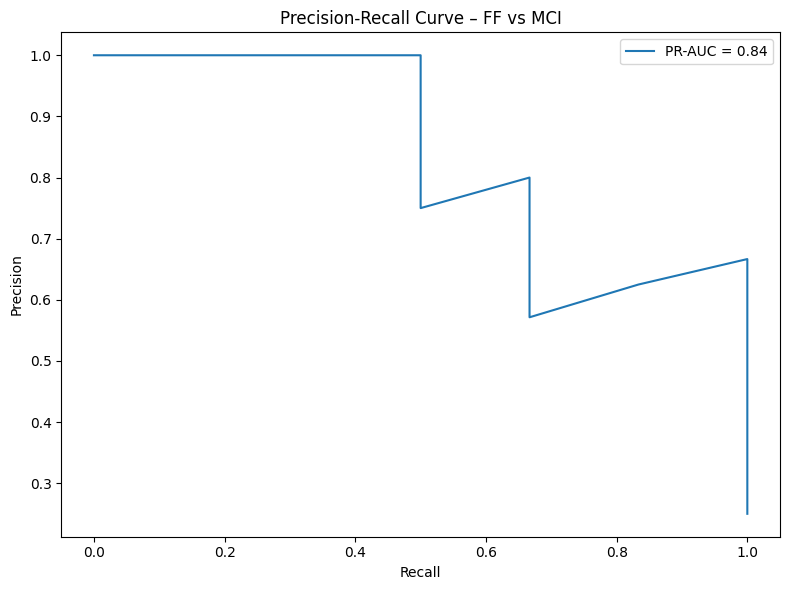

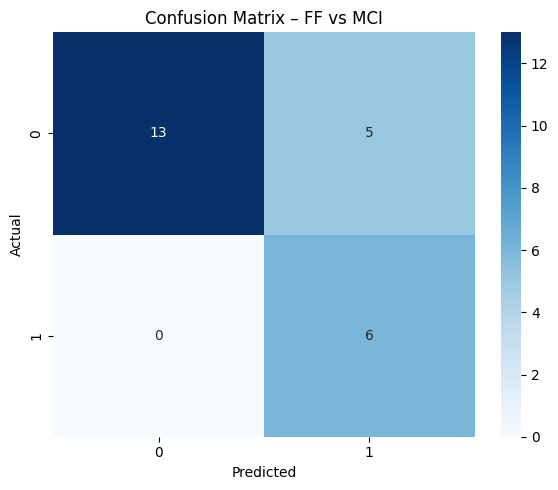

Stratified bootstrap test metrics (mean ± SD) [95% CI]:
Accuracy: 0.788 ± 0.081 | 95% CI [0.625, 0.917]
Precision: 0.558 ± 0.101 | 95% CI [0.400, 0.750]
Recall: 1.000 ± 0.000 | 95% CI [1.000, 1.000]
Specificity: 0.717 ± 0.108 | 95% CI [0.500, 0.889]
F1: 0.711 ± 0.081 | 95% CI [0.571, 0.857]
ROC-AUC: 0.932 ± 0.053 | 95% CI [0.805, 1.000]
Trapezoidal PR-AUC: 0.832 ± 0.126 | 95% CI [0.500, 1.000]


In [69]:
selected_features = features_full + semantic_features
df_task = df[df['group'].isin(['MCI', 'Frailty'])].copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

lasso_pipeline = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42), selected_features
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(
    lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring,
    n_jobs=-1, return_train_score=False
)
print('Stratified training cross-validation (5 folds):')
for metric in scoring:
    values = cv_results[f'test_{metric}']

lasso_pipeline.fit(X_train, y_train)
y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

metrics_semantic = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Trapezoidal PR-AUC': pr_auc
}
print('Held-out test metrics – MCI vs Frailty')
print(classification_report(y_test, y_pred, zero_division=0))
print({k: round(v, 3) for k, v in metrics_semantic.items()})

classifier = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': classifier.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False)
print('Non-zero Coefficients (LASSO):')
print(coef_df[['Feature', 'Coefficient']])
feature_subset_fvm = (
    coef_df
    .head(11)['Feature']
    .tolist()
)

coef_series_fvm = pd.Series(
    coef_df['Coefficient'].values,
    index=coef_df['Feature'].values
)

print(
    'Saved TOP feature_subset_fvm:',
    len(feature_subset_fvm),
    feature_subset_fvm
)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Feature Importance – FF vs MCI')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – FF vs MCI')
plt.legend()
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f'PR-AUC = {pr_auc:.2f}'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – FF vs MCI')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – FF vs MCI')
plt.tight_layout()
plt.show()

# Stratified bootstrap of the held-out test
rng = np.random.RandomState(42)
y_arr = y_test.to_numpy()
class_indices = [np.flatnonzero(y_arr == cls) for cls in np.unique(y_arr)]
boot_metrics = {k: [] for k in metrics_semantic}
for _ in range(1000):
    idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices])
    current = comparison_metrics(y_arr[idx], y_pred[idx], y_proba[idx])
    for key in boot_metrics:
        boot_metrics[key].append(current[key])
print('Stratified bootstrap test metrics (mean ± SD) [95% CI]:')
for metric, values in boot_metrics.items():
    values = np.asarray(values)
    print(f'{metric}: {values.mean():.3f} ± {values.std():.3f} | 95% CI [{np.percentile(values, 2.5):.3f}, {np.percentile(values, 97.5):.3f}]')

### SHAP: MCI vs Frailty

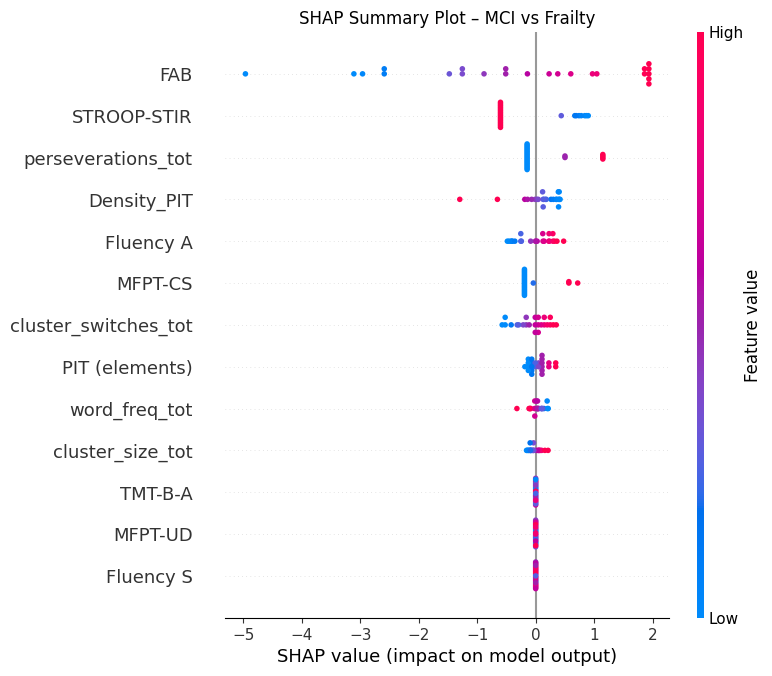

In [70]:
selected_features = features_full + semantic_features
df_task = df[df['group'].isin(['MCI', 'Frailty'])].copy()
X = df_task[selected_features].apply(pd.to_numeric, errors='coerce')
y = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Fit preprocessing and resampling on training data only
shap_pipeline = make_resampling_pipeline(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=1.0, random_state=42),
    RandomUnderSampler(random_state=42), selected_features
)
shap_pipeline.fit(X_train, y_train)
fitted_preprocessor = shap_pipeline.named_steps['preprocessing']
model = shap_pipeline.named_steps['classifier']
X_train_scaled = fitted_preprocessor.transform(X_train)
X_test_scaled = fitted_preprocessor.transform(X_test)

# SHAP uses the model fitted on training and transforms the test without refitting
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, max_display=13, show=False)
plt.title('SHAP Summary Plot – MCI vs Frailty')
plt.show()

y_proba = shap_pipeline.predict_proba(X_test)[:, 1]
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}
binary_model_outputs['MCI vs Frailty'] = {
    'comparison_name': 'MCI vs Frailty',
    'positive_group': 'Frailty',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'preprocessor': fitted_preprocessor,
    'pipeline': shap_pipeline,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}

## Models vs Neuropsychological reference

This section evaluates whether the predicted probabilities generated by each model are aligned with a clinically derived neuropsychological reference.

For each binary comparison, the workflow follows the same structure:

define a contrast-specific neuropsychological reference label;
train the corresponding logistic regression model on the selected feature subset;
assess the association between model-predicted probabilities and the reference label using OLS regression;
visualize the relationship through regression plots.

The implementation reuses the same df and model outputs generated in the ML sections, ensuring full consistency between the predictive analyses and the neuropsychological reference evaluation.


Final ML outputs available:
['MCI vs All', 'HC vs Frailty', 'MCI vs Frailty', 'FF vs HC', 'FF vs MCI']

NEUROPSYCHOLOGICAL REFERENCE

Available tests:
['MMSE', 'TMT-A', 'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting']

Tests not available in dataframe:
['Corsi D.', 'Digit D.', 'Supraspan', 'Rey_copy', 'Rey_Imm', 'Rey_diff', 'Rey_oblio', 'Rac Im', 'Rac Diff', 'Rac Oblio']

Missing cognitive values before KNN: 0
Missing cognitive values after KNN: 0

Distribution of number of deficient tests:
n_deficient
0    72
1    18
2     9
3     6
4     2
5     1
7     1
Name: count, dtype: int64

Participants with at least one cognitive deficit: 37

Missing TFI component values before KNN: 0
Missing TFI component values after KNN: 0

CLASSICAL REFERENCE DISTRIBUTIONS

reference_MCI_ALL
reference_MCI_ALL
0    72
1    37
Name: count, dtype: int64

reference_FF_HC
reference_FF_HC
0.0    39
NaN    37
1.0    33
Name: count, dtype: int64

refere

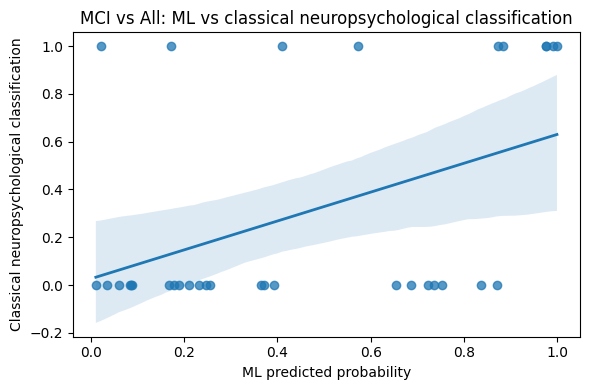


FF vs HC
Held-out test N: 16
Valid classical-reference N: 13

Classical reference distribution:
classical_reference
0.0    7
1.0    6
Name: count, dtype: int64
                             OLS Regression Results                            
Dep. Variable:     classical_reference   R-squared:                       0.045
Model:                             OLS   Adj. R-squared:                 -0.042
Method:                  Least Squares   F-statistic:                    0.4892
Date:                 Thu, 10 Sep 2026   Prob (F-statistic):              0.499
Time:                         11:18:08   Log-Likelihood:                -9.0982
No. Observations:                   13   AIC:                             22.20
Df Residuals:                       11   BIC:                             23.33
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                 coef    std err       

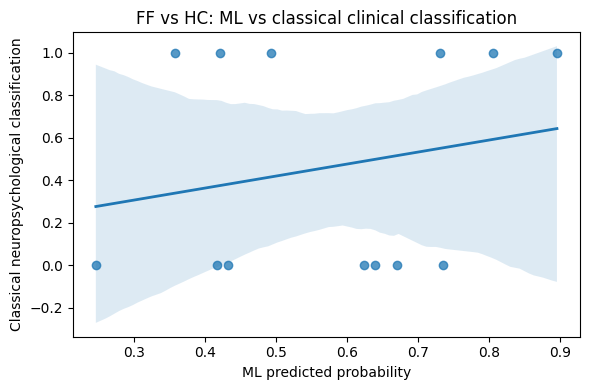


FF vs MCI
Held-out test N: 24
Valid classical-reference N: 19

Classical reference distribution:
classical_reference
0.0    11
1.0     8
Name: count, dtype: int64
                             OLS Regression Results                            
Dep. Variable:     classical_reference   R-squared:                       0.781
Model:                             OLS   Adj. R-squared:                  0.768
Method:                  Least Squares   F-statistic:                     209.6
Date:                 Thu, 10 Sep 2026   Prob (F-statistic):           5.42e-11
Time:                         11:18:09   Log-Likelihood:                0.87666
No. Observations:                   19   AIC:                             2.247
Df Residuals:                       17   BIC:                             4.136
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                 coef    std err    

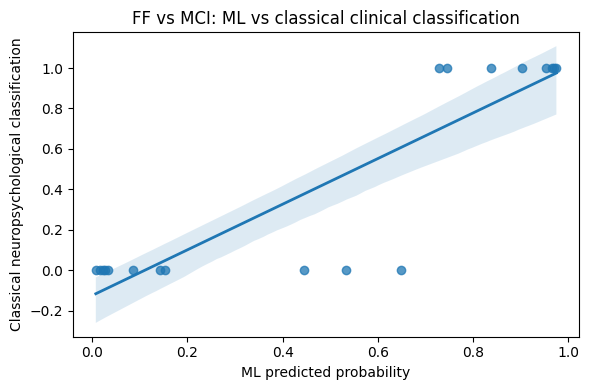


ML vs CLASSICAL CLASSIFICATION — SUMMARY


,Comparison,N,R²,Beta probability,p-value
0,MCI vs All,33,0.199,0.605,0.009
1,FF vs HC,13,0.045,0.565,0.484
2,FF vs MCI,19,0.781,1.128,0.000


In [73]:
# NEUROPSYCHOLOGICAL CLASSIFICATION vs ML CLASSIFICATION
#
# Classical neuropsychological classification:
# - missing values: KNN imputation with k 5
# - cognitive scores standardized within the study sample
# - cognitive deficit: at least 1 score at or below -1.5 SD
# - Frailty profile: TFI at least 5 and no cognitive deficit
#
# GDS, ADL and IADL are not included among cognitive deficits.
#
# Comparison is performed against held-out probabilities from
# the already fitted final ML models.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.impute import KNNImputer


# 1. CHECK FINAL ML OUTPUTS

if "binary_model_outputs" not in globals():
    raise NameError(
        "binary_model_outputs is not available. "
        "Run the three final ML/SHAP sections first."
    )


# Harmonize comparison names used in previous model sections

if (
    "HC vs Frailty" in binary_model_outputs
    and "FF vs HC" not in binary_model_outputs
):
    binary_model_outputs["FF vs HC"] = (
        binary_model_outputs["HC vs Frailty"]
    )


if (
    "MCI vs Frailty" in binary_model_outputs
    and "FF vs MCI" not in binary_model_outputs
):
    binary_model_outputs["FF vs MCI"] = (
        binary_model_outputs["MCI vs Frailty"]
    )


required_models = [
    "MCI vs All",
    "FF vs HC",
    "FF vs MCI"
]


missing_models = [
    name
    for name in required_models
    if name not in binary_model_outputs
]


if missing_models:
    raise NameError(
        f"Missing final model outputs: {missing_models}"
    )


print("Final ML outputs available:")
print(list(binary_model_outputs.keys()))


# 2. CLASSICAL COGNITIVE BATTERY

reference_cognitive_tests = [
    "MMSE",
    "Corsi D.",
    "Digit D.",
    "Supraspan",
    "TMT-A",
    "TMT-B",
    "TMT-B-A",
    "Rey_copy",
    "Rey_Imm",
    "Rey_diff",
    "Rey_oblio",
    "Rac Im",
    "Rac Diff",
    "Rac Oblio",
    "FAB",
    "MFPT-UD",
    "MFPT-CS",
    "Fluency F.",
    "Fluency S",
    "Fluency A",
    "Fluency Shifting"
]


available_tests = [
    c
    for c in reference_cognitive_tests
    if c in df.columns
]


missing_tests = [
    c
    for c in reference_cognitive_tests
    if c not in df.columns
]


print("\nNEUROPSYCHOLOGICAL REFERENCE")

print("\nAvailable tests:")
print(available_tests)

print("\nTests not available in dataframe:")
print(missing_tests)


if len(available_tests) == 0:
    raise ValueError(
        "No cognitive tests available for the "
        "neuropsychological classification."
    )


# 3. NUMERIC CONVERSION AND KNN IMPUTATION

cognitive_raw = (
    df[available_tests]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


# Remove tests that are completely missing

all_nan_tests = cognitive_raw.columns[
    cognitive_raw.isna().all()
].tolist()


if all_nan_tests:
    print(
        "\nCompletely missing tests excluded:",
        all_nan_tests
    )


usable_tests = [
    c
    for c in available_tests
    if c not in all_nan_tests
]


cognitive_raw = cognitive_raw[
    usable_tests
]


print(
    "\nMissing cognitive values before KNN:",
    int(cognitive_raw.isna().sum().sum())
)


cognitive_imputer = KNNImputer(
    n_neighbors=5
)


cognitive_imputed = pd.DataFrame(
    cognitive_imputer.fit_transform(
        cognitive_raw
    ),
    columns=usable_tests,
    index=df.index
)


print(
    "Missing cognitive values after KNN:",
    int(cognitive_imputed.isna().sum().sum())
)


# 4. SAMPLE BASED Z SCORES

z_scores = pd.DataFrame(
    index=df.index
)


# Higher values indicate poorer performance for these tests.
# Their direction is reversed so lower z always means worse performance.

higher_is_worse = [
    "TMT-A",
    "TMT-B",
    "TMT-B-A"
]


for test in usable_tests:

    values = cognitive_imputed[
        test
    ]

    mean_sample = values.mean()

    sd_sample = values.std(
        ddof=0
    )


    if (
        pd.isna(sd_sample)
        or sd_sample == 0
    ):

        print(
            f"WARNING: {test} has zero or undefined SD "
            "and is excluded from deficit counting."
        )

        continue


    z = (
        values - mean_sample
    ) / sd_sample


    if test in higher_is_worse:
        z = -z


    z_scores[
        f"z_{test}"
    ] = z


# 5. NUMBER OF COGNITIVE DEFICITS

DEFICIT_CUTOFF = -1.5


deficit_matrix = (
    z_scores <= DEFICIT_CUTOFF
)


clinical_reference = pd.DataFrame(
    index=df.index
)


clinical_reference[
    "n_deficient"
] = deficit_matrix.sum(
    axis=1
)


clinical_reference[
    "has_cognitive_deficit"
] = (
    clinical_reference[
        "n_deficient"
    ] >= 1
)


clinical_reference[
    "no_cognitive_deficit"
] = (
    clinical_reference[
        "n_deficient"
    ] == 0
)


print(
    "\nDistribution of number of deficient tests:"
)

print(
    clinical_reference[
        "n_deficient"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nParticipants with at least one cognitive deficit:",
    clinical_reference[
        "has_cognitive_deficit"
    ].sum()
)


# 6. TFI

tfi_columns = [
    "TFI- variabili fisiche ",
    "TFI- variabili psicologiche",
    "TFI- sociali"
]


missing_tfi_columns = [
    c
    for c in tfi_columns
    if c not in df.columns
]


if missing_tfi_columns:
    raise KeyError(
        f"Missing TFI columns: {missing_tfi_columns}"
    )


tfi_raw = (
    df[tfi_columns]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


print(
    "\nMissing TFI component values before KNN:",
    int(tfi_raw.isna().sum().sum())
)


tfi_imputer = KNNImputer(
    n_neighbors=5
)


tfi_imputed = pd.DataFrame(
    tfi_imputer.fit_transform(
        tfi_raw
    ),
    columns=tfi_columns,
    index=df.index
)


print(
    "Missing TFI component values after KNN:",
    int(tfi_imputed.isna().sum().sum())
)


clinical_reference[
    "TFI_total"
] = tfi_imputed.sum(
    axis=1
)


# 7. CLASSICAL REFERENCE LABELS


# MCI vs All
#
# Classical MCI requires at least one cognitive deficit.
# Classical non MCI requires no cognitive deficits.

clinical_reference[
    "reference_MCI_ALL"
] = np.where(
    clinical_reference[
        "has_cognitive_deficit"
    ],
    1,
    0
)


# FF vs HC
#
# HC profile requires no cognitive deficit and TFI below 5.
# FF profile requires no cognitive deficit and TFI at least 5.
# Subjects with cognitive impairment are excluded from this comparison.

clinical_reference[
    "reference_FF_HC"
] = np.nan


hc_reference_mask = (
    clinical_reference[
        "no_cognitive_deficit"
    ]
    &
    (
        clinical_reference[
            "TFI_total"
        ] < 5
    )
)


frailty_reference_mask = (
    clinical_reference[
        "no_cognitive_deficit"
    ]
    &
    (
        clinical_reference[
            "TFI_total"
        ] >= 5
    )
)


clinical_reference.loc[
    hc_reference_mask,
    "reference_FF_HC"
] = 0


clinical_reference.loc[
    frailty_reference_mask,
    "reference_FF_HC"
] = 1


# FF vs MCI
#
# Classical MCI requires at least one cognitive deficit.
# Classical FF requires TFI at least 5 and no cognitive deficit.
# Subjects satisfying neither profile are excluded.
# The positive ML class is FF.

clinical_reference[
    "reference_FF_MCI"
] = np.nan


mci_reference_mask = (
    clinical_reference[
        "has_cognitive_deficit"
    ]
)


frailty_reference_mask = (
    clinical_reference[
        "no_cognitive_deficit"
    ]
    &
    (
        clinical_reference[
            "TFI_total"
        ] >= 5
    )
)


clinical_reference.loc[
    mci_reference_mask,
    "reference_FF_MCI"
] = 0


clinical_reference.loc[
    frailty_reference_mask,
    "reference_FF_MCI"
] = 1


# 8. REFERENCE DISTRIBUTIONS

print(
    "\nCLASSICAL REFERENCE DISTRIBUTIONS"
)


for col in [
    "reference_MCI_ALL",
    "reference_FF_HC",
    "reference_FF_MCI"
]:

    print(
        f"\n{col}"
    )

    print(
        clinical_reference[
            col
        ].value_counts(
            dropna=False
        )
    )


# 9. ML VS CLASSICAL CLASSIFICATION
#
# Held out probabilities from the final ML models are used.
# OLS is retained for continuity with the manuscript.
# HC3 robust standard errors are used for the binary outcome.

def compare_ml_vs_classical(
    comparison_name,
    reference_column,
    title
):

    saved = binary_model_outputs[
        comparison_name
    ]


    test_index = pd.Index(
        saved["test_index"]
    )


    pred_prob = pd.Series(
        saved["test_probabilities"],
        index=test_index,
        name="pred_prob"
    )


    comparison_df = pd.DataFrame(
        index=test_index
    )


    comparison_df[
        "pred_prob"
    ] = pred_prob


    comparison_df[
        "classical_reference"
    ] = clinical_reference.loc[
        test_index,
        reference_column
    ]


    comparison_df = (
        comparison_df
        .dropna()
        .copy()
    )


    print(
        f"\n{comparison_name}"
    )


    print(
        "Held-out test N:",
        len(test_index)
    )


    print(
        "Valid classical-reference N:",
        len(comparison_df)
    )


    print(
        "\nClassical reference distribution:"
    )


    print(
        comparison_df[
            "classical_reference"
        ].value_counts()
    )


    if len(comparison_df) < 3:

        print(
            "Too few valid observations for regression."
        )

        return None, comparison_df


    if (
        comparison_df[
            "classical_reference"
        ].nunique()
        < 2
    ):

        print(
            "Only one reference class is present; "
            "regression cannot be estimated."
        )

        return None, comparison_df


    # OLS regression

    X_ols = sm.add_constant(
        comparison_df[
            "pred_prob"
        ],
        has_constant="add"
    )


    ols_model = sm.OLS(
        comparison_df[
            "classical_reference"
        ],
        X_ols
    ).fit(
        cov_type="HC3"
    )


    print(
        ols_model.summary()
    )


    # Regression plot

    plt.figure(
        figsize=(6, 4)
    )


    sns.regplot(
        data=comparison_df,
        x="pred_prob",
        y="classical_reference",
        scatter_kws={
            "alpha": 0.75
        },
        line_kws={
            "linewidth": 2
        }
    )


    plt.xlabel(
        "ML predicted probability"
    )


    plt.ylabel(
        "Classical neuropsychological classification"
    )


    plt.title(
        title
    )


    plt.tight_layout()

    plt.show()


    return (
        ols_model,
        comparison_df
    )


# 10. RUN THE THREE COMPARISONS


ols_mcia, comparison_mcia = (
    compare_ml_vs_classical(

        comparison_name=
            "MCI vs All",

        reference_column=
            "reference_MCI_ALL",

        title=
            "MCI vs All: ML vs classical "
            "neuropsychological classification"
    )
)


ols_hcf, comparison_hcf = (
    compare_ml_vs_classical(

        comparison_name=
            "FF vs HC",

        reference_column=
            "reference_FF_HC",

        title=
            "FF vs HC: ML vs classical "
            "clinical classification"
    )
)


ols_mf, comparison_mf = (
    compare_ml_vs_classical(

        comparison_name=
            "FF vs MCI",

        reference_column=
            "reference_FF_MCI",

        title=
            "FF vs MCI: ML vs classical "
            "clinical classification"
    )
)


# 11. COMPACT SUMMARY

summary_rows = []


for name, model, data_comp in [

    (
        "MCI vs All",
        ols_mcia,
        comparison_mcia
    ),

    (
        "FF vs HC",
        ols_hcf,
        comparison_hcf
    ),

    (
        "FF vs MCI",
        ols_mf,
        comparison_mf
    )
]:

    if model is None:

        summary_rows.append(
            {
                "Comparison":
                    name,

                "N":
                    len(data_comp),

                "R²":
                    np.nan,

                "Beta probability":
                    np.nan,

                "p-value":
                    np.nan
            }
        )

    else:

        summary_rows.append(
            {
                "Comparison":
                    name,

                "N":
                    len(data_comp),

                "R²":
                    model.rsquared,

                "Beta probability":
                    model.params.get(
                        "pred_prob",
                        np.nan
                    ),

                "p-value":
                    model.pvalues.get(
                        "pred_prob",
                        np.nan
                    )
            }
        )


clinical_comparison_summary = pd.DataFrame(
    summary_rows
)


print(
    "\nML vs CLASSICAL CLASSIFICATION — SUMMARY"
)


display(
    clinical_comparison_summary.round(3)
)

## Balanced semantic\-metrics LASSO \(downsampling MCI\)


We re\-ran the semantic binary classifications using the same preprocessing and model configuration as the original analyses, while restricting features to the top non\-zero LASSO coefficients\. To assess the effect of class imbalance, we applied fixed\-count downsampling of the majority class in the training set only \(e\.g\., 16 vs 16 for MCI vs All; 6 vs 6 for Frailty vs MCI\), while keeping the original held\-out test sets unchanged\.

The pipeline consisted of KNNImputer \(k=5\) \+ StandardScaler within a ColumnTransformer, followed by L1\-penalized Logistic Regression \(liblinear, class\_weight=balanced\)\. For each model, we reported Accuracy, Precision, Recall, Specificity, F1\-score, ROC\-AUC, and Average Precision, together with confusion matrices, ROC/PR curves, and 1000\-iteration bootstrap confidence intervals\.

To evaluate robustness, we additionally performed repeated downsampling analyses across 100 random seeds and visualized the resulting metric distributions with boxplots, allowing us to assess whether classification performance remained stable after balancing the classes\.


In [76]:
# CELL 0 — FULL RESTORE SETUP

%matplotlib inline

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve, auc, roc_curve
)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# Model factory (PDF1-style)

def make_lasso_lr(random_state=42, C=1.0, class_weight="balanced"):
    """
    LASSO logistic regression as in your v1 (liblinear + L1).
    Will raise FutureWarnings in sklearn>=1.8 but replicates v1 behavior.
    """
    return LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        class_weight=class_weight,
        random_state=random_state
    )



# Metrics

def compute_metrics(y_true, y_pred, y_proba):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    if cm.shape != (2, 2):
        return {
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "Specificity": np.nan,
            "F1": np.nan,
            "ROC_AUC": np.nan,
            "PR_AUC": np.nan
        }

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    roc_auc = (
        roc_auc_score(y_true, y_proba)
        if len(np.unique(y_true)) == 2
        else np.nan
    )

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true,
        y_proba
    )

    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc
    }


def bootstrap_metrics(y_test, X_test, fitted_pipeline, n_iter=1000, random_state=42, verbose=True):
    """
    Bootstrap metrics on test set by resampling indices with replacement.
    Uses the fitted_pipeline to get predictions/probabilities.
    """
    rng = np.random.RandomState(random_state)

    y_test_arr = np.asarray(y_test)
    n = len(y_test_arr)
    class_indices = [np.flatnonzero(y_test_arr == cls) for cls in np.unique(y_test_arr)]

    # Predict once, then index for deterministic paired resampling
    y_pred_full = fitted_pipeline.predict(X_test)
    y_proba_full = fitted_pipeline.predict_proba(X_test)[:, 1]

    boot = {
    k: []
    for k in [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
}

    for _ in range(n_iter):
        idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices])
        y_b = y_test_arr[idx]
        y_pred_b = np.asarray(y_pred_full)[idx]
        y_proba_b = np.asarray(y_proba_full)[idx]

        if len(np.unique(y_b)) < 2:
            continue

        m = compute_metrics(y_b, y_pred_b, y_proba_b)
        for k in boot:
            boot[k].append(m[k])

    if verbose:
        print("Bootstrapped metrics (mean ± std) [95% CI]:")
        for k, vals in boot.items():
            vals = np.asarray(vals, dtype=float)
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                print(f"{k}: NA")
                continue
            mean = vals.mean()
            std = vals.std()
            ci_low = np.percentile(vals, 2.5)
            ci_high = np.percentile(vals, 97.5)
            print(f"{k}: {mean:.3f} ± {std:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

    return boot



# Plotting (Deepnote-safe, separate figures)

def plot_evaluation_curves(y_true, y_proba, y_pred, title_prefix="Model"):
    """
    ROC + PR + Confusion Matrix as separate figures (avoids overlay issues).
    """
    y_true = np.asarray(y_true)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC: {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} — ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(
    recall,
    precision
)
    plt.figure(figsize=(6, 5))
    plt.plot(
    recall,
    precision,
    label=f"PR-AUC: {pr_auc:.3f}"
)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} — Precision–Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title_prefix} — Confusion Matrix")
    plt.tight_layout()
    plt.show()



# Your exact boxplot function (unchanged)

def plot_robustness_boxplot(
    results_df,
    metrics_to_plot=None,
    title="Repeated Downsampling Robustness"
):
    if metrics_to_plot is None:
        metrics_to_plot = [
    'Accuracy',
    'F1',
    'Recall',
    'ROC_AUC',
    'PR_AUC'
]

    paper_colors = [
        "#5F7FA6",  # Accuracy
        "#C7772C",  # F1
        "#556F2D",  # Recall
        "#466789",  # ROC_AUC
        "#D8B11E"   # Average_Precision
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    bp = ax.boxplot(
        [results_df[m].dropna() for m in metrics_to_plot],
        patch_artist=True,
        labels=metrics_to_plot,
        widths=0.6,
        showmeans=True
    )

    for patch, color in zip(bp['boxes'], paper_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('#333333')
        patch.set_linewidth(1.2)

    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    for mean in bp['means']:
        mean.set_marker('D')
        mean.set_markerfacecolor('white')
        mean.set_markeredgecolor('#333333')
        mean.set_markersize(5)

    for whisker in bp['whiskers']:
        whisker.set_color('#444444')

    for cap in bp['caps']:
        cap.set_color('#444444')

    for flier in bp['fliers']:
        flier.set(
            marker='o',
            markerfacecolor='#333333',
            markeredgecolor='#333333',
            alpha=0.45,
            markersize=4
        )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


def get_feature_subset(key, available_columns):
    mapping = {
        'FF_MCI': feature_subset_fvm,
        'MCI_ALL': feature_subset_mcia,
        'FF_HC': feature_subset_fhc
    }
    subset = [f for f in mapping[key] if f in available_columns]
    if not subset:
        raise ValueError(f'No saved training-selected features are available for {key}.')
    return subset

def print_metrics(title, metrics):
    print(title)
    print({k: round(v, 3) if pd.notna(v) else np.nan for k, v in metrics.items()})

# Repeated downsampling robustness (fixed-count training only)
def repeated_downsampling_robustness(
    *,
    X_train_sub,
    y_train,
    X_test_sub,
    y_test,
    feature_subset,
    counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness"
):
    """
    For each seed:
      - downsample TRAIN to fixed counts (counts={0:k,1:k})
      - fit LASSO LR pipeline (same preprocessing)
      - evaluate on unchanged TEST
    Returns:
      results_df: per-seed metrics
      summary_df: mean/std/min/max per metric
    """
    rows = []

    for i in range(n_repeats):
        seed = random_state_start + i

        pipe = ImbPipeline(steps=[
            ("preprocessing", make_preprocessor(feature_subset)),
            ("sampling", RandomUnderSampler(sampling_strategy=counts, random_state=seed)),
            ("classifier", make_lasso_lr(random_state=seed, C=1.0))
        ])
        pipe.fit(X_train_sub, y_train)

        y_pred = pipe.predict(X_test_sub)
        y_proba = pipe.predict_proba(X_test_sub)[:, 1]

        m = compute_metrics(y_test, y_pred, y_proba)
        m["seed"] = seed
        rows.append(m)

    results_df = pd.DataFrame(rows)

    summary_df = results_df.drop(columns=["seed"]).agg(["mean", "std", "min", "max"]).T
    summary_df.columns = ["Mean", "SD", "Min", "Max"]

    print(title)
    print(summary_df.round(3))

    return results_df, summary_df

### Section 1: FF vs MCI \(full multimodal\) \- fixed\-count downsampling

Feature subset used (FF vs MCI): ['FAB', 'STROOP-STIR', 'MFPT-CS', 'Density_PIT', 'perseverations_tot', 'Fluency A', 'cluster_switches_tot', 'PIT (elements)', 'word_freq_tot', 'cluster_size_tot']

Training distribution BEFORE balancing:
group
0    39
1    14
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        18
           1       0.56      0.83      0.67         6

    accuracy                           0.79        24
   macro avg       0.74      0.81      0.76        24
weighted avg       0.84      0.79      0.80        24


Unbalanced — test set metrics:
{'Accuracy': 0.792, 'Precision': 0.556, 'Recall': 0.833, 'Specificity': 0.778, 'F1': 0.667, 'ROC_AUC': 0.926, 'PR_AUC': 0.792}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.784 ± 0.086 | 95% CI [0.625, 0.917]
Precision: 0.563 ± 0.130 | 95% CI [0.333, 0.8

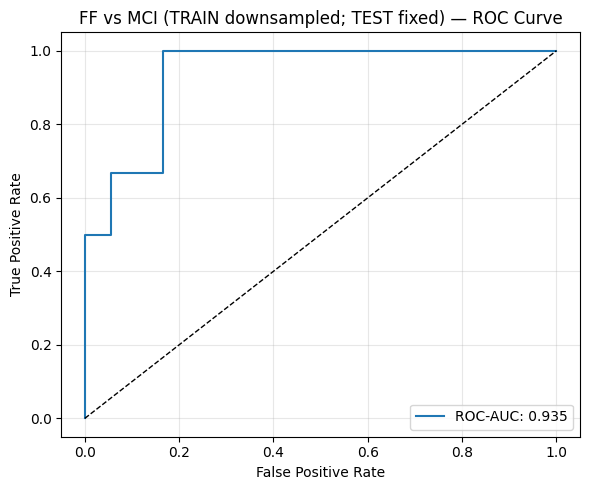

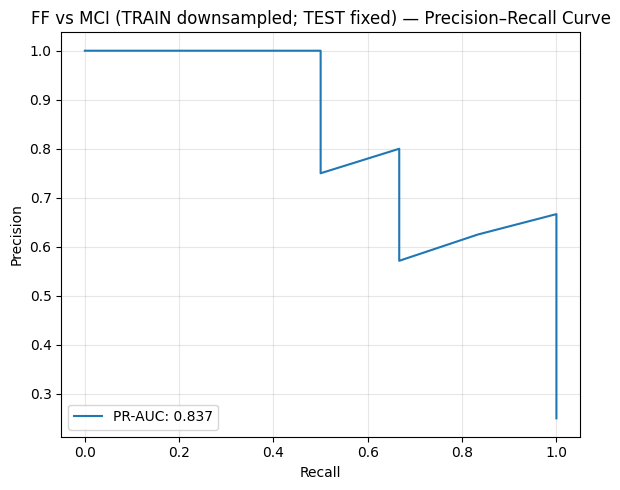

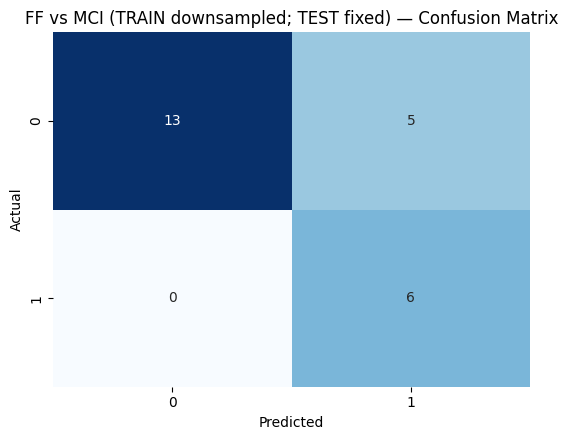

Repeated Downsampling Robustness — FF vs MCI
              Mean     SD    Min    Max
Accuracy     0.786  0.047  0.625  0.875
Precision    0.547  0.062  0.333  0.714
Recall       0.903  0.142  0.333  1.000
Specificity  0.747  0.063  0.556  0.889
F1           0.676  0.074  0.364  0.800
ROC_AUC      0.898  0.032  0.778  0.954
PR_AUC       0.688  0.107  0.465  0.889


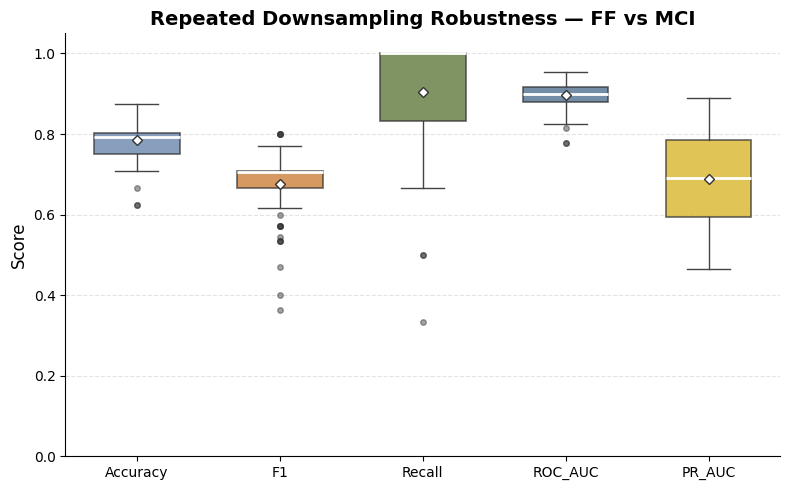

In [77]:
# FF vs MCI — semantic robustness
# 1 = Frailty (FF), 0 = MCI
# Balanced: downsample majority to minority count in TRAIN

df_task = df[df['group'].isin(['MCI', 'Frailty'])].copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("FF_MCI", X_train.columns)
print("Feature subset used (FF vs MCI):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution BEFORE balancing:")
print(y_train.value_counts())

# ---- UNBALANCED ----
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (UNBALANCED, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (UNBALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# ---- BALANCED (k = minority count in TRAIN) ----
k = int(y_train.value_counts().min())   # e.g., 14
counts = {0: k, 1: k}

print("\nTraining distribution AFTER balancing (TRAIN downsampling only):")
print(pd.Series(counts, name='count'))

pipe_bal = ImbPipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('sampling', RandomUnderSampler(sampling_strategy=counts, random_state=42)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_sub, y_train)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (BALANCED, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (BALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Post-hoc robustness evaluation only; these test results do not select resampling
# Plots after metrics
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="FF vs MCI (TRAIN downsampled; TEST fixed)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — FF vs MCI"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — FF vs MCI")

### Section 2: MCI vs All \(full multimodal\) \- fixed\-count downsampling


Feature subset used (MCI vs All): ['Fluency S', 'Fluency A', 'FAB', 'MFPT-UD', 'perseverations_tot', 'PIT (elements)', 'STROOP-STIR', 'Clustering_PIT', 'switch_rate_tot', 'word_freq_tot', 'TMT-B-A']

Training distribution BEFORE balancing:
group
1    40
0    36
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.86      0.71      0.77        17

    accuracy                           0.79        33
   macro avg       0.80      0.79      0.79        33
weighted avg       0.80      0.79      0.79        33


Unbalanced — test set metrics:
{'Accuracy': 0.788, 'Precision': 0.857, 'Recall': 0.706, 'Specificity': 0.875, 'F1': 0.774, 'ROC_AUC': 0.805, 'PR_AUC': 0.86}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.790 ± 0.070 | 95% CI [0.636, 0.909]
Precision: 0.865 ± 0.083 | 95% CI [0.692, 1

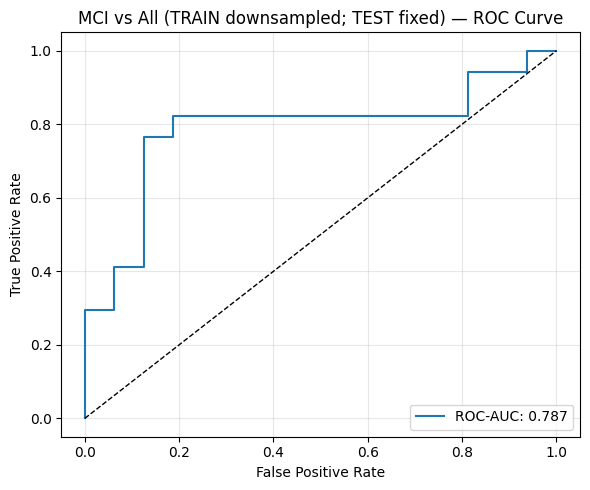

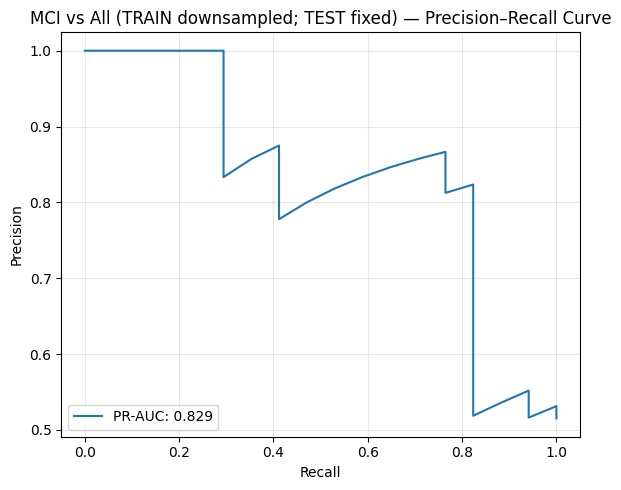

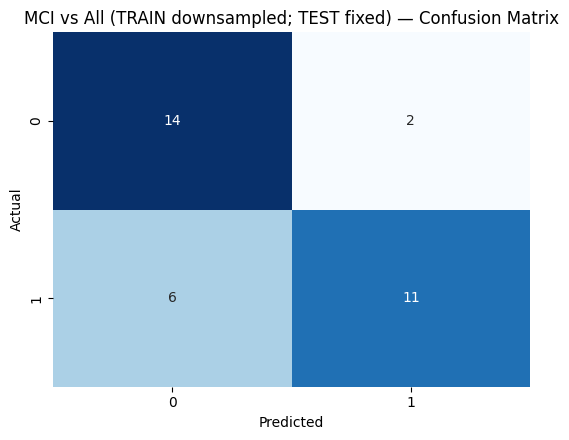

Repeated Downsampling Robustness — MCI vs All
              Mean     SD    Min    Max
Accuracy     0.772  0.024  0.727  0.818
Precision    0.852  0.011  0.833  0.909
Recall       0.675  0.047  0.588  0.765
Specificity  0.876  0.006  0.875  0.938
F1           0.753  0.033  0.690  0.812
ROC_AUC      0.802  0.013  0.768  0.835
PR_AUC       0.854  0.013  0.812  0.879


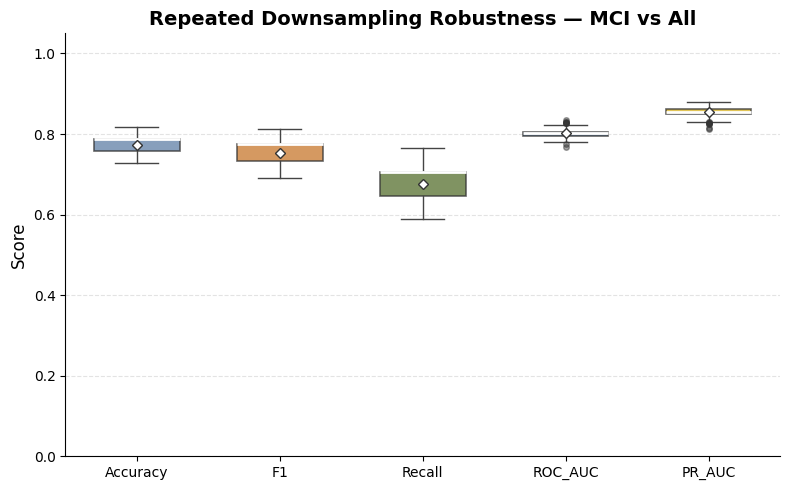

In [78]:
# MCI vs All — semantic robustness
# 1 = MCI, 0 = Others
# Balanced: downsample majority to minority count in TRAIN

df_task = df.copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("MCI_ALL", X_train.columns)
print("Feature subset used (MCI vs All):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution BEFORE balancing:")
print(y_train.value_counts())

# ---- UNBALANCED ----
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (UNBALANCED, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (UNBALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# ---- BALANCED (k = minority count in TRAIN) ----
k = int(y_train.value_counts().min())
counts = {0: k, 1: k}

print("\nTraining distribution AFTER balancing (TRAIN downsampling only):")
print(pd.Series(counts, name='count'))

pipe_bal = ImbPipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('sampling', RandomUnderSampler(sampling_strategy=counts, random_state=42)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_sub, y_train)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (BALANCED, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (BALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Post-hoc robustness evaluation only; these test results do not select resampling
# Plots after metrics
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="MCI vs All (TRAIN downsampled; TEST fixed)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — MCI vs All"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — MCI vs All")

## Section 3: FF vs HC \(full multimodal\) \- fixed\-count downsampling \(k=min\_count\)


Feature subset used (FF vs HC): ['MFPT-CS', 'MFPT-UD', 'Fluency Shifting', 'PIT (elements)', 'PIT (s)', 'aoa_tot', 'intrusions_tot', 'Clustering_PIT', 'STROOP-STIR', 'word_freq_tot', 'TMT-B']

Training distribution BEFORE balancing:
group
0    22
1    14
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.38      0.50      0.43         6

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.49        16
weighted avg       0.53      0.50      0.51        16


Unbalanced — test set metrics:
{'Accuracy': 0.5, 'Precision': 0.375, 'Recall': 0.5, 'Specificity': 0.5, 'F1': 0.429, 'ROC_AUC': 0.617, 'PR_AUC': 0.557}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.501 ± 0.124 | 95% CI [0.250, 0.750]
Precision: 0.374 ± 0.129 | 95% CI [0.125, 0.626]
Recall

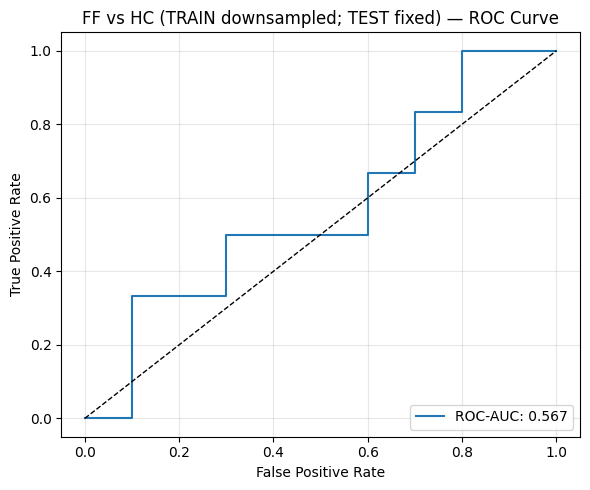

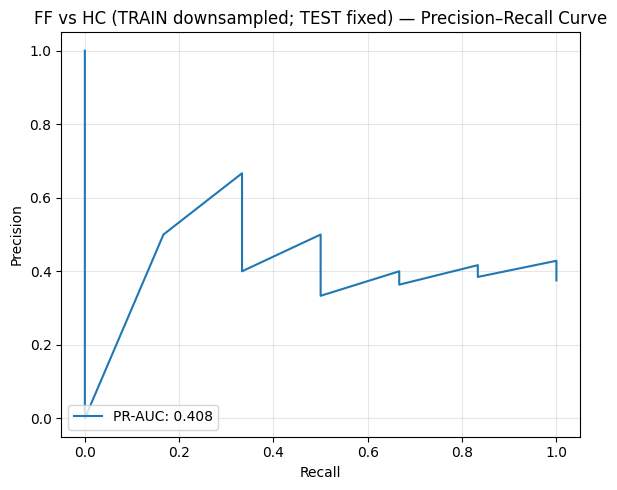

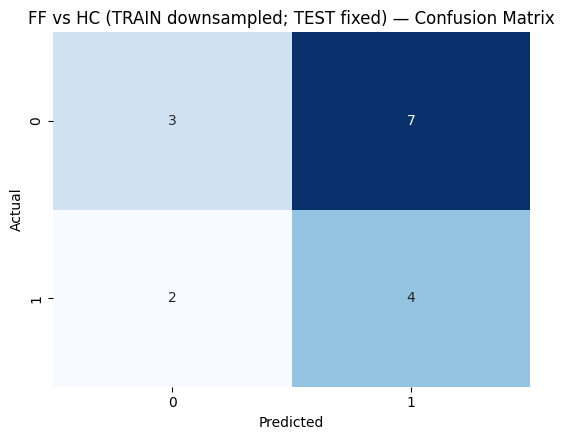

Repeated Downsampling Robustness — FF vs HC
              Mean     SD    Min    Max
Accuracy     0.489  0.089  0.312  0.688
Precision    0.391  0.069  0.273  0.571
Recall       0.632  0.119  0.500  0.833
Specificity  0.403  0.116  0.200  0.700
F1           0.481  0.081  0.353  0.667
ROC_AUC      0.606  0.055  0.500  0.717
PR_AUC       0.523  0.082  0.360  0.694


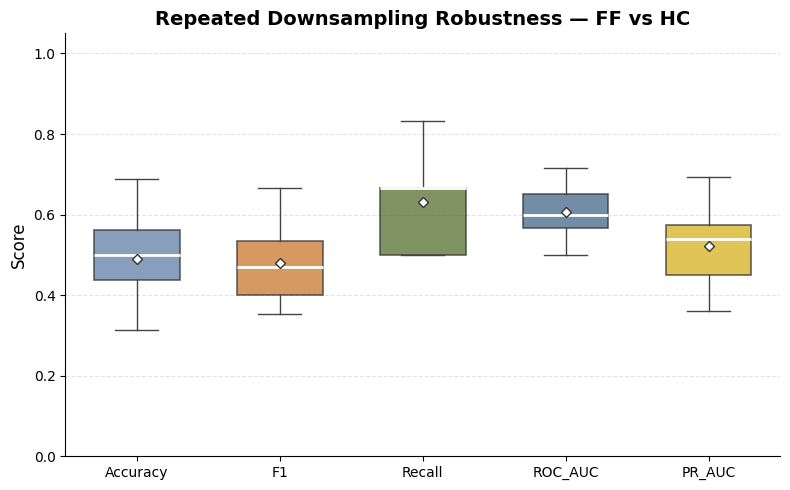

In [79]:
# FF vs HC — semantic robustness
# 1 = Frailty (FF), 0 = HC
# Balanced: downsample majority to minority count in TRAIN

df_task = df[df['group'].isin(['HC', 'Frailty'])].copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("FF_HC", X_train.columns)
print("Feature subset used (FF vs HC):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution BEFORE balancing:")
print(y_train.value_counts())

# ---- UNBALANCED ----
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (UNBALANCED, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (UNBALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# ---- BALANCED (k = minority count in TRAIN) ----
k = int(y_train.value_counts().min())
counts = {0: k, 1: k}

print("\nTraining distribution AFTER balancing (TRAIN downsampling only):")
print(pd.Series(counts, name='count'))

pipe_bal = ImbPipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('sampling', RandomUnderSampler(sampling_strategy=counts, random_state=42)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_sub, y_train)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (BALANCED, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (BALANCED, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Post-hoc robustness evaluation only; these test results do not select resampling
# Plots after metrics
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="FF vs HC (TRAIN downsampled; TEST fixed)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — FF vs HC"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — FF vs HC")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cf280e5d-731e-4415-8250-b9e26b4596bc' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>